# Data preperation for generation attribution

## Step 1: long term observed data (monthly precip)

In [6]:
import os
import warnings

import numpy as np
import xarray as xr


# Prevent xarray from using flox in any reduction operation.
# This avoids the flox/sparse/numba/NumPy compatibility problem.
xr.set_options(use_flox=False)

warnings.filterwarnings(
    "ignore",
    message="Ambiguous reference date string",
)


# =========================================================
# 1. Configuration
# =========================================================
INPUT_NC = (
    "/home/users/weijia_6/Yangtze_code/gen_data/CN05.1/"
    "CN05.1_Pre_1961_2021_month_025x025.nc"
)

OUTPUT_NC = (
    "/home/users/weijia_6/Yangtze_code/gen_data/CN05.1/"
    "CN05_monthly_precip_grid_1970_2010.nc"
)

PRE_VAR = "pre"

START_YEAR = 1970
END_YEAR = 2010

START_DATE = f"{START_YEAR}-01-01"
END_DATE = f"{END_YEAR}-12-31"

EXPECTED_MONTHS = (END_YEAR - START_YEAR + 1) * 12


# =========================================================
# 2. General helper functions
# =========================================================
def assert_file_exists(path):
    """Check that an input file exists."""
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Input file not found: {path}")


def standardise_coordinate_names(ds):
    """
    Rename common latitude and longitude coordinate names to
    'lat' and 'lon'.
    """
    rename = {}

    if "latitude" in ds.coords or "latitude" in ds.dims:
        rename["latitude"] = "lat"

    if "longitude" in ds.coords or "longitude" in ds.dims:
        rename["longitude"] = "lon"

    if rename:
        ds = ds.rename(rename)

    required = {"time", "lat", "lon"}
    missing = required.difference(ds.coords)

    if missing:
        raise ValueError(
            f"Missing required coordinates: {sorted(missing)}. "
            f"Available coordinates: {list(ds.coords)}"
        )

    return ds


def convert_longitude_to_minus180_180(ds):
    """
    Convert longitude from 0-360 to -180-180 if needed.
    """
    lon_min = float(ds.lon.min())
    lon_max = float(ds.lon.max())

    if lon_min >= 0 and lon_max > 180:
        new_lon = ((ds.lon + 180) % 360) - 180
        ds = ds.assign_coords(lon=new_lon).sortby("lon")

    return ds


def ensure_latitude_ascending(ds):
    """
    Ensure latitude coordinates run from south to north.
    """
    if ds.lat.size > 1 and float(ds.lat[0]) > float(ds.lat[-1]):
        ds = ds.sortby("lat")

    return ds


# =========================================================
# 3. Detect precipitation units
# =========================================================
def detect_precipitation_units(da):
    """
    Detect precipitation units from the 'units' or 'long_name'
    attributes.

    The CN05 monthly file stores mm/day in its long_name:
        CN05.1 daily, precipitation,mm/day

    Its history shows the monthly file was generated using CDO
    monmean, so values represent monthly mean daily rates.
    """
    units = str(
        da.attrs.get("units", "")
    ).strip().lower()

    long_name = str(
        da.attrs.get("long_name", "")
    ).strip().lower()

    combined = f"{units} {long_name}"

    rate_indicators = [
        "mm/day",
        "mm day-1",
        "mm day^-1",
        "mm d-1",
        "mm d^-1",
        "mm per day",
    ]

    for indicator in rate_indicators:
        if indicator in combined:
            return "mm/day"

    monthly_total_indicators = [
        "mm/month",
        "mm month-1",
        "mm month^-1",
        "monthly accumulated",
    ]

    for indicator in monthly_total_indicators:
        if indicator in combined:
            return "mm/month"

    raise ValueError(
        "Could not determine precipitation units.\n"
        f"units attribute: {da.attrs.get('units', 'not provided')}\n"
        f"long_name attribute: "
        f"{da.attrs.get('long_name', 'not provided')}"
    )


# =========================================================
# 4. Time checks
# =========================================================
def create_expected_month_ids():
    """Create expected YYYYMM identifiers for 1970-2010."""
    return np.array(
        [
            year * 100 + month
            for year in range(START_YEAR, END_YEAR + 1)
            for month in range(1, 13)
        ],
        dtype=np.int32,
    )


def check_monthly_continuity(time):
    """
    Check that the selected data contain exactly one record for
    every month from January 1970 through December 2010.
    """
    years = time.dt.year.values.astype(np.int32)
    months = time.dt.month.values.astype(np.int32)

    actual_month_ids = years * 100 + months
    expected_month_ids = create_expected_month_ids()

    if len(actual_month_ids) != EXPECTED_MONTHS:
        raise ValueError(
            f"Expected {EXPECTED_MONTHS} monthly records, "
            f"but found {len(actual_month_ids)}."
        )

    unique_ids, counts = np.unique(
        actual_month_ids,
        return_counts=True,
    )

    duplicate_ids = unique_ids[counts > 1]

    if duplicate_ids.size > 0:
        raise ValueError(
            f"Duplicated year-month records found: {duplicate_ids}"
        )

    missing_ids = np.setdiff1d(
        expected_month_ids,
        actual_month_ids,
    )

    unexpected_ids = np.setdiff1d(
        actual_month_ids,
        expected_month_ids,
    )

    if missing_ids.size > 0 or unexpected_ids.size > 0:
        raise ValueError(
            "The monthly sequence is incomplete.\n"
            f"Missing month IDs: {missing_ids}\n"
            f"Unexpected month IDs: {unexpected_ids}"
        )

    if not np.array_equal(
        actual_month_ids,
        expected_month_ids,
    ):
        raise ValueError(
            "All expected months are present, but the records "
            "are not in chronological order."
        )

    print(
        "[TIME CHECK] "
        f"{actual_month_ids[0]} to {actual_month_ids[-1]}, "
        f"{len(actual_month_ids)} continuous months."
    )


# =========================================================
# 5. Input inspection
# =========================================================
def inspect_input(da):
    """Print basic metadata and source-data statistics."""
    print("\n========== INPUT VARIABLE ==========")
    print(da)

    print("\nAttributes:")
    print(da.attrs)

    print("\nEncoding:")
    print(da.encoding)

    print("\nInput statistics:")
    print(
        "Minimum:",
        float(da.min(skipna=True).compute()),
    )
    print(
        "Mean:",
        float(da.mean(skipna=True).compute()),
    )
    print(
        "Median:",
        float(da.median(skipna=True).compute()),
    )
    print(
        "Maximum:",
        float(da.max(skipna=True).compute()),
    )
    print(
        "Missing count:",
        int(da.isnull().sum().compute()),
    )
    print(
        "Valid fraction:",
        float(da.notnull().mean().compute()),
    )


# =========================================================
# 6. Precipitation processing
# =========================================================
def clean_negative_precipitation(da):
    """
    Clip physically invalid negative precipitation values to zero
    while preserving existing NaN values.
    """
    missing_before = int(
        da.isnull().sum().compute()
    )

    negative_count = int(
        (da < 0).sum(skipna=True).compute()
    )

    print("\nNegative precipitation count:", negative_count)

    if negative_count > 0:
        negative_values = da.where(da < 0)

        print(
            "Negative-value range:",
            float(
                negative_values.min(skipna=True).compute()
            ),
            "to",
            float(
                negative_values.max(skipna=True).compute()
            ),
        )

        print(
            "[WARNING] Clipping negative precipitation "
            "values to zero."
        )

        # Existing NaN values are preserved.
        da = da.clip(min=0.0)

    missing_after = int(
        da.isnull().sum().compute()
    )

    if missing_before != missing_after:
        raise RuntimeError(
            "Cleaning changed the number of missing values.\n"
            f"Before: {missing_before}\n"
            f"After: {missing_after}"
        )

    return da


def convert_to_monthly_total(da, source_units):
    """
    Convert monthly mean precipitation rate from mm/day to
    monthly accumulated precipitation in mm/month.
    """
    if source_units == "mm/day":
        days_in_month = da.time.dt.days_in_month.astype(
            np.float32
        )

        monthly = da * days_in_month

        conversion_description = (
            "Monthly mean daily precipitation multiplied by "
            "the Gregorian number of days in each month."
        )

    elif source_units == "mm/month":
        monthly = da.copy()

        conversion_description = (
            "Input already represented monthly accumulated "
            "precipitation; no temporal conversion applied."
        )

    else:
        raise ValueError(
            f"Unsupported precipitation units: {source_units}"
        )

    monthly = monthly.astype(np.float32)
    monthly.name = "precip"

    monthly.attrs = {
        "long_name": (
            "CN05.1 monthly accumulated precipitation"
        ),
        "standard_name": (
            "lwe_thickness_of_precipitation_amount"
        ),
        "units": "mm month-1",
        "source_variable": PRE_VAR,
        "source_units": source_units,
        "source_temporal_statistic": (
            "Monthly mean of daily precipitation"
            if source_units == "mm/day"
            else "Monthly accumulated precipitation"
        ),
        "conversion": conversion_description,
    }

    return monthly


def add_calendar_coordinates(da):
    """
    Add calendar-independent year, month, and month_id
    coordinates.

    These can later be used to match Gregorian CN05 data with
    HadGEM's 360-day calendar.
    """
    years = da.time.dt.year.values.astype(np.int32)
    months = da.time.dt.month.values.astype(np.int8)

    month_ids = (
        years.astype(np.int32) * 100
        + months.astype(np.int32)
    )

    da = da.assign_coords(
        year=("time", years),
        month=("time", months),
        month_id=("time", month_ids),
    )

    da.year.attrs = {
        "long_name": "calendar year",
    }

    da.month.attrs = {
        "long_name": "calendar month",
        "valid_min": np.int8(1),
        "valid_max": np.int8(12),
    }

    da.month_id.attrs = {
        "long_name": "year-month identifier",
        "description": "year * 100 + month",
    }

    return da


# =========================================================
# 7. Output checks
# =========================================================
def validate_output(da):
    """Perform checks on the processed dataset."""
    if da.sizes["time"] != EXPECTED_MONTHS:
        raise ValueError(
            f"Expected {EXPECTED_MONTHS} records, "
            f"but output has {da.sizes['time']}."
        )

    if int(da.month_id.values[0]) != 197001:
        raise ValueError(
            "The first output month is not January 1970."
        )

    if int(da.month_id.values[-1]) != 201012:
        raise ValueError(
            "The final output month is not December 2010."
        )

    remaining_negative_count = int(
        (da < 0).sum(skipna=True).compute()
    )

    if remaining_negative_count > 0:
        raise ValueError(
            f"{remaining_negative_count} negative values remain."
        )

    # Check whether any complete monthly field is missing.
    all_missing_by_time = da.isnull().all(
        dim=("lat", "lon")
    )

    all_missing_indices = np.flatnonzero(
        all_missing_by_time.values
    )

    if all_missing_indices.size > 0:
        bad_months = da.month_id.isel(
            time=all_missing_indices
        ).values

        raise ValueError(
            "Entire spatial fields are missing for month IDs: "
            f"{bad_months}"
        )

    valid_any = da.notnull().any(dim="time")
    valid_all = da.notnull().all(dim="time")
    intermittent = valid_any & ~valid_all

    spatial_cell_count = (
        da.sizes["lat"] * da.sizes["lon"]
    )

    print("\n========== OUTPUT CHECKS ==========")
    print("Dimensions:", dict(da.sizes))
    print("Expected time records:", EXPECTED_MONTHS)
    print("First time:", da.time.values[0])
    print("Last time:", da.time.values[-1])
    print(
        "First month_id:",
        int(da.month_id.values[0]),
    )
    print(
        "Last month_id:",
        int(da.month_id.values[-1]),
    )

    print(
        "Minimum:",
        float(da.min(skipna=True).compute()),
        "mm/month",
    )
    print(
        "Mean over valid values:",
        float(da.mean(skipna=True).compute()),
        "mm/month",
    )
    print(
        "Maximum:",
        float(da.max(skipna=True).compute()),
        "mm/month",
    )

    print(
        "Missing count:",
        int(da.isnull().sum().compute()),
    )
    print(
        "Valid fraction:",
        float(da.notnull().mean().compute()),
    )

    print(
        "Total spatial grid cells:",
        spatial_cell_count,
    )
    print(
        "Cells valid at least once:",
        int(valid_any.sum().compute()),
    )
    print(
        "Cells valid in every month:",
        int(valid_all.sum().compute()),
    )
    print(
        "Cells with intermittent missing values:",
        int(intermittent.sum().compute()),
    )

    return {
        "valid_any": valid_any,
        "valid_all": valid_all,
        "intermittent": intermittent,
    }


# =========================================================
# 8. Check intermittent missing cells
# =========================================================
def inspect_intermittent_cells(da, masks):
    """
    Print a short summary of cells that are valid in some months
    but missing in others.
    """
    intermittent = masks["intermittent"]
    intermittent_count = int(
        intermittent.sum().compute()
    )

    if intermittent_count == 0:
        print(
            "\nNo intermittently missing spatial cells were found."
        )
        return

    missing_count_per_cell = da.isnull().sum(
        dim="time"
    )

    intermittent_missing_counts = (
        missing_count_per_cell
        .where(intermittent)
        .values
    )

    values = intermittent_missing_counts[
        np.isfinite(intermittent_missing_counts)
    ]

    print("\n========== INTERMITTENT CELLS ==========")
    print(
        "Number of intermittent cells:",
        intermittent_count,
    )
    print(
        "Minimum missing months per intermittent cell:",
        int(values.min()),
    )
    print(
        "Mean missing months per intermittent cell:",
        float(values.mean()),
    )
    print(
        "Maximum missing months per intermittent cell:",
        int(values.max()),
    )

    # Print only the first ten locations to avoid excessive output.
    lat_indices, lon_indices = np.where(
        intermittent.values
    )

    print("\nFirst intermittent cell locations:")

    number_to_print = min(
        10,
        intermittent_count,
    )

    for index in range(number_to_print):
        lat_index = lat_indices[index]
        lon_index = lon_indices[index]

        lat_value = float(
            da.lat.values[lat_index]
        )
        lon_value = float(
            da.lon.values[lon_index]
        )

        cell = da.isel(
            lat=lat_index,
            lon=lon_index,
        )

        missing_month_ids = da.month_id.where(
            cell.isnull(),
            drop=True,
        ).values

        print(
            f"lat={lat_value:.2f}, "
            f"lon={lon_value:.2f}, "
            f"missing months={len(missing_month_ids)}"
        )


# =========================================================
# 9. Save the processed dataset
# =========================================================
def save_output(da):
    """Create and save the output NetCDF dataset."""
    output = da.to_dataset(name="precip")

    output.attrs = {
        "title": (
            "CN05.1 gridded monthly accumulated precipitation, "
            "1970-2010"
        ),
        "source_file": os.path.basename(INPUT_NC),
        "source_dataset": "CN05.1",
        "spatial_domain": (
            "Full CN05.1 China land-data domain within its "
            "rectangular longitude-latitude grid"
        ),
        "spatial_resolution": "0.25 degree",
        "temporal_coverage": "1970-01 to 2010-12",
        "calendar": "proleptic_gregorian",
        "processing": (
            "Selected January 1970 through December 2010 from "
            "the CN05.1 monthly-mean precipitation file. The "
            "source monthly file was generated from daily "
            "precipitation using CDO monmean. Monthly mean daily "
            "precipitation in mm day-1 was multiplied by the "
            "actual Gregorian number of days in each month to "
            "obtain monthly accumulated precipitation in "
            "mm month-1. Missing values outside the valid CN05.1 "
            "domain were retained."
        ),
    }

    output_directory = os.path.dirname(
        OUTPUT_NC
    )

    os.makedirs(
        output_directory,
        exist_ok=True,
    )

    # Remove inherited source time encoding.
    output.time.encoding = {}

    encoding = {
        "precip": {
            "dtype": "float32",
            "zlib": True,
            "complevel": 4,
            "_FillValue": np.float32(-9999.0),
        },
        "time": {
            "dtype": "int64",
            "units": (
                "hours since 1970-01-01 00:00:00"
            ),
            "calendar": "proleptic_gregorian",
        },
        "year": {
            "dtype": "int32",
        },
        "month": {
            "dtype": "int8",
        },
        "month_id": {
            "dtype": "int32",
        },
    }

    print("\nSaving processed dataset...")

    output.to_netcdf(
        OUTPUT_NC,
        encoding=encoding,
    )

    print("Saved:")
    print(OUTPUT_NC)


# =========================================================
# 10. Verify saved file
# =========================================================
def verify_saved_file():
    """
    Reopen the output file and verify its main properties.
    """
    print("\n========== SAVED-FILE VERIFICATION ==========")

    with xr.open_dataset(
        OUTPUT_NC,
        decode_cf=True,
        mask_and_scale=True,
    ) as check:

        print(check)

        if check.sizes["time"] != EXPECTED_MONTHS:
            raise RuntimeError(
                "Saved file has an unexpected number of "
                "time records."
            )

        if int(check.month_id.values[0]) != 197001:
            raise RuntimeError(
                "Saved file has an incorrect first month_id."
            )

        if int(check.month_id.values[-1]) != 201012:
            raise RuntimeError(
                "Saved file has an incorrect final month_id."
            )

        if check["precip"].attrs.get("units") != "mm month-1":
            raise RuntimeError(
                "Saved precipitation units are incorrect or missing."
            )

        print("\nSaved-file checks:")
        print(
            "Dimensions:",
            dict(check.sizes),
        )
        print(
            "Precipitation units:",
            check.precip.attrs.get("units"),
        )
        print(
            "Time range:",
            check.time.values[0],
            "to",
            check.time.values[-1],
        )
        print(
            "month_id range:",
            int(check.month_id.values[0]),
            "to",
            int(check.month_id.values[-1]),
        )
        print(
            "Valid fraction:",
            float(
                check.precip.notnull().mean().compute()
            ),
        )

    print("\nSaved-file verification passed.")


# =========================================================
# 11. Main workflow
# =========================================================
def main():
    assert_file_exists(INPUT_NC)

    print("Opening CN05.1 monthly precipitation file...")

    with xr.open_dataset(
        INPUT_NC,
        decode_cf=True,
        mask_and_scale=True,
    ) as ds:

        ds = standardise_coordinate_names(ds)
        ds = convert_longitude_to_minus180_180(ds)
        ds = ensure_latitude_ascending(ds)

        if PRE_VAR not in ds.data_vars:
            raise KeyError(
                f"Variable '{PRE_VAR}' was not found.\n"
                f"Available variables: {list(ds.data_vars)}"
            )

        source = ds[PRE_VAR]

        inspect_input(source)

        source_units = detect_precipitation_units(
            source
        )

        print(
            "\nDetected source precipitation units:",
            source_units,
        )

        print(
            f"\nSelecting {START_DATE} to {END_DATE}..."
        )

        pre = source.sel(
            time=slice(START_DATE, END_DATE)
        )

        pre = pre.sortby("time")
        pre = pre.transpose(
            "time",
            "lat",
            "lon",
        )

        # Load only the selected 1970-2010 subset.
        pre = pre.load()

    check_monthly_continuity(
        pre.time
    )

    print("\nCleaning precipitation...")
    pre = clean_negative_precipitation(
        pre
    )

    print(
        "\nConverting monthly mean mm/day "
        "to accumulated mm/month..."
    )

    pre_monthly = convert_to_monthly_total(
        pre,
        source_units=source_units,
    )

    print(
        "\nAdding year, month, and month_id coordinates..."
    )

    pre_monthly = add_calendar_coordinates(
        pre_monthly
    )

    masks = validate_output(
        pre_monthly
    )

    inspect_intermittent_cells(
        pre_monthly,
        masks,
    )

    save_output(
        pre_monthly
    )

    verify_saved_file()

    print("\nStep 1 completed successfully.")


if __name__ == "__main__":
    main()

Opening CN05.1 monthly precipitation file...

========== INPUT VARIABLE ==========
<xarray.DataArray 'pre' (time: 732, lat: 163, lon: 283)> Size: 135MB
[33766428 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 6kB 1961-01-16 ... 2021-12-16
  * lon      (lon) float64 2kB 69.75 70.0 70.25 70.5 ... 139.5 139.8 140.0 140.2
  * lat      (lat) float64 1kB 14.75 15.0 15.25 15.5 ... 54.5 54.75 55.0 55.25
Attributes:
    long_name:  CN05.1 daily, precipitation,mm/day   

Attributes:
{'long_name': 'CN05.1 daily, precipitation,mm/day   \r'}

Encoding:
{'dtype': dtype('float32'), 'source': '/home/users/weijia_6/Yangtze_code/gen_data/CN05.1/CN05.1_Pre_1961_2021_month_025x025.nc', 'original_shape': (732, 163, 283), 'missing_value': np.float32(-9999.0), '_FillValue': np.float32(-9999.0)}

Input statistics:
Minimum: 0.0
Mean: 1.6614481210708618
Median: 0.6691603064537048
Maximum: 48.87068557739258
Missing count: 22604949
Valid fraction: 0.3305495920385775

Detected source pr

In [7]:
# Import packages
import xarray as xr
import numpy as np
import pandas as pd

In [8]:
x = xr.open_dataset(OUTPUT_NC)
x.time

<xarray.DataArray 'time' (time: 492)> Size: 4kB
array(['1970-01-16T00:00:00.000000000', '1970-02-14T12:00:00.000000000',
       '1970-03-16T00:00:00.000000000', ..., '2010-10-16T00:00:00.000000000',
       '2010-11-15T12:00:00.000000000', '2010-12-16T00:00:00.000000000'],
      shape=(492,), dtype='datetime64[ns]')
Coordinates:
  * time      (time) datetime64[ns] 4kB 1970-01-16 ... 2010-12-16
    year      (time) int32 2kB ...
    month     (time) int8 492B ...
    month_id  (time) int32 2kB ...
Attributes:
    standard_name:  time
    bounds:         time_bnds
    axis:           T

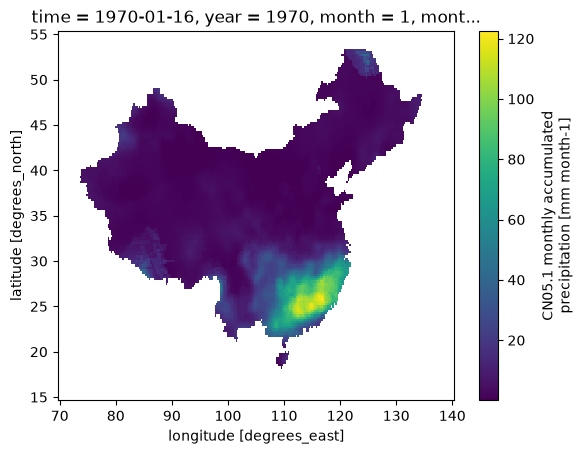

In [9]:
x.precip[0].plot()

## Step 2: long term HadGEM model data (monthly precip)

In [11]:
# ============================================================
# Step 2:
# Build 15-ensemble HadGEM monthly accumulated precipitation
# for January 1970 through December 2010
# ============================================================

import os
import warnings

import numpy as np
import xarray as xr


# Avoid flox -> sparse -> numba incompatibility in this environment.
xr.set_options(use_flox=False)

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
)


# ============================================================
# 1. User settings
# ============================================================

BASE_PATH = (
    "/gws/ssde/j25a/cssp_china/wp1/"
    "HadGEM3-A-N216-CHINAcut/historical/pr/day"
)

SEGMENTS = [
    "19600101-19691230",
    "19700101-19791230",
    "19800101-19891230",
    "19900101-19991230",
    "20000101-20091230",
    "20100101-20131230",
]

PR_VAR = "pr"

START_YEAR = 1970
END_YEAR = 2010

ENSEMBLE_NUMBERS = range(1, 16)

EXPECTED_MONTHS = (
    END_YEAR - START_YEAR + 1
) * 12

EXPECTED_DAYS = (
    END_YEAR - START_YEAR + 1
) * 360

SECONDS_PER_DAY = np.float32(86400.0)
DAYS_PER_MODEL_MONTH = 30

OUT_PRE_NC = (
    "/home/users/weijia_6/Yangtze_code/gen_data/HadGEM/"
    "HadGEM_monthly_precip_1970_2010_15ens.nc"
)


# ============================================================
# 2. File and coordinate helpers
# ============================================================

def assert_exists(path):
    """Raise an error if a required file does not exist."""
    if not os.path.isfile(path):
        raise FileNotFoundError(
            f"File not found: {path}"
        )


def build_filename(ensemble_number, segment):
    """Construct one HadGEM historical precipitation filename."""
    filename = (
        f"pr_day_HadGEM3-A-N216_historical_"
        f"r1i1p{ensemble_number}_{segment}-CHINA.nc"
    )

    return os.path.join(
        BASE_PATH,
        filename,
    )


def standardise_coordinate_names(ds):
    """
    Rename common coordinate names to time, lat, and lon.
    """
    rename = {}

    if "latitude" in ds.coords or "latitude" in ds.dims:
        rename["latitude"] = "lat"

    if "longitude" in ds.coords or "longitude" in ds.dims:
        rename["longitude"] = "lon"

    if rename:
        ds = ds.rename(rename)

    required = {"time", "lat", "lon"}
    missing = required.difference(ds.coords)

    if missing:
        raise ValueError(
            f"Missing required coordinates: {sorted(missing)}. "
            f"Available coordinates: {list(ds.coords)}"
        )

    return ds


def convert_longitude_to_minus180_180(ds):
    """
    Convert longitude coordinates from 0-360 to -180-180
    if necessary.
    """
    lon_min = float(ds.lon.min())
    lon_max = float(ds.lon.max())

    if lon_min >= 0 and lon_max > 180:
        new_lon = (
            (ds.lon + 180) % 360
        ) - 180

        ds = (
            ds.assign_coords(lon=new_lon)
            .sortby("lon")
        )

    return ds


def ensure_latitude_ascending(ds):
    """Ensure latitude is ordered south to north."""
    if (
        ds.lat.size > 1
        and float(ds.lat.values[0])
        > float(ds.lat.values[-1])
    ):
        ds = ds.sortby("lat")

    return ds


# ============================================================
# 3. Unit and calendar checks
# ============================================================

def normalise_unit_text(value):
    """Normalise a unit string for comparison."""
    return (
        str(value)
        .strip()
        .lower()
        .replace(" ", "")
        .replace("**", "^")
    )


def verify_precipitation_units(pr, filename):
    """
    Confirm that precipitation is a mass flux equivalent to
    kg m-2 s-1.

    For liquid water:
        1 kg m-2 = 1 mm
    """
    units = pr.attrs.get("units", "")
    normalised = normalise_unit_text(units)

    accepted = {
        "kgm-2s-1",
        "kgm^-2s^-1",
        "kg/m2/s",
        "kgm-2sec-1",
    }

    if normalised not in accepted:
        raise ValueError(
            f"Unexpected precipitation units in:\n{filename}\n"
            f"Found: '{units}'\n"
            "Expected a form equivalent to kg m-2 s-1."
        )

    return units


def get_calendar_name(time):
    """
    Identify the decoded calendar of the time coordinate.
    """
    calendar = getattr(
        time.dt,
        "calendar",
        None,
    )

    if calendar is not None:
        try:
            calendar = calendar.item()
        except AttributeError:
            pass

    if calendar is None:
        calendar = time.encoding.get(
            "calendar",
            time.attrs.get(
                "calendar",
                "unknown",
            ),
        )

    return str(calendar)


def verify_360_day_calendar(time, filename):
    """Require a 360-day model calendar."""
    calendar = get_calendar_name(time)

    accepted = {
        "360_day",
        "360",
    }

    if calendar.lower() not in accepted:
        raise ValueError(
            f"Unexpected calendar in:\n{filename}\n"
            f"Detected calendar: {calendar}\n"
            "Expected: 360_day"
        )

    return calendar


# ============================================================
# 4. Time helpers
# ============================================================

def select_year_range(da, start_year, end_year):
    """
    Select records by model year without using where(drop=True).

    This works safely with HadGEM's CFTimeIndex and preserves
    the latitude and longitude dimensions even when no times match.
    """
    years = da.time.dt.year.values

    time_indices = np.flatnonzero(
        (years >= start_year)
        & (years <= end_year)
    )

    return da.isel(time=time_indices)


def create_month_id(time):
    """Create YYYYMM identifiers from any decoded calendar."""
    year = time.dt.year.values.astype(
        np.int32
    )

    month = time.dt.month.values.astype(
        np.int32
    )

    return year * 100 + month


def expected_month_ids():
    """Expected January 1970 through December 2010 IDs."""
    return np.array(
        [
            year * 100 + month
            for year in range(
                START_YEAR,
                END_YEAR + 1,
            )
            for month in range(1, 13)
        ],
        dtype=np.int32,
    )


def check_unique_daily_times(pr, label):
    """Check for duplicate daily timestamps."""
    time_values = pr.time.values

    unique_count = len(
        np.unique(time_values)
    )

    if unique_count != len(time_values):
        raise ValueError(
            f"Duplicate daily timestamps found in {label}. "
            f"Records: {len(time_values)}, "
            f"unique timestamps: {unique_count}"
        )


def check_unique_month_ids(monthly, label):
    """Check for duplicate year-month records."""
    month_ids = create_month_id(
        monthly.time
    )

    values, counts = np.unique(
        month_ids,
        return_counts=True,
    )

    duplicates = values[counts > 1]

    if duplicates.size > 0:
        raise ValueError(
            f"Duplicate monthly records in {label}: "
            f"{duplicates}"
        )


# ============================================================
# 5. Grid checks
# ============================================================

def grids_match(first, second, tolerance=1e-8):
    """Compare two latitude-longitude grids."""
    if first.lat.shape != second.lat.shape:
        return False

    if first.lon.shape != second.lon.shape:
        return False

    same_lat = np.allclose(
        first.lat.values,
        second.lat.values,
        atol=tolerance,
        rtol=0,
    )

    same_lon = np.allclose(
        first.lon.values,
        second.lon.values,
        atol=tolerance,
        rtol=0,
    )

    return same_lat and same_lon


# ============================================================
# 6. Open and inspect one source file
# ============================================================

def inspect_first_file():
    """
    Inspect the first relevant file before processing all files.
    """
    filename = build_filename(
        ensemble_number=1,
        segment="19700101-19791230",
    )

    assert_exists(filename)

    print(
        "Inspecting first HadGEM source file..."
    )
    print(filename)

    with xr.open_dataset(
        filename,
        decode_cf=True,
        mask_and_scale=True,
    ) as ds:

        ds = standardise_coordinate_names(ds)
        ds = convert_longitude_to_minus180_180(ds)
        ds = ensure_latitude_ascending(ds)

        if PR_VAR not in ds.data_vars:
            raise KeyError(
                f"Variable '{PR_VAR}' not found in:\n"
                f"{filename}\n"
                f"Available variables: {list(ds.data_vars)}"
            )

        pr = ds[PR_VAR]

        print("\n========== SOURCE INSPECTION ==========")
        print(pr)

        print("\nVariable attributes:")
        print(pr.attrs)

        print("\nTime attributes:")
        print(pr.time.attrs)

        print("\nTime encoding:")
        print(pr.time.encoding)

        units = verify_precipitation_units(
            pr,
            filename,
        )

        calendar = verify_360_day_calendar(
            pr.time,
            filename,
        )

        print("\nDetected units:", units)
        print("Detected calendar:", calendar)
        print(
            "First decoded date:",
            pr.time.values[0],
        )
        print(
            "Last decoded date:",
            pr.time.values[-1],
        )

        print(
            "Grid:",
            pr.sizes["lat"],
            "latitude cells x",
            pr.sizes["lon"],
            "longitude cells",
        )

        print(
            "Latitude range:",
            float(pr.lat.min()),
            "to",
            float(pr.lat.max()),
        )

        print(
            "Longitude range:",
            float(pr.lon.min()),
            "to",
            float(pr.lon.max()),
        )

        print(
            "Daily precipitation flux range:",
            float(pr.min(skipna=True)),
            "to",
            float(pr.max(skipna=True)),
            units,
        )


# ============================================================
# 7. Convert one daily segment to monthly totals
# ============================================================

def process_one_segment(
    ensemble_number,
    segment,
    reference_grid=None,
):
    """
    Open one daily segment, select the required years, verify it,
    and convert it to monthly accumulated precipitation.

    Only the monthly result is loaded into memory.
    """
    filename = build_filename(
        ensemble_number,
        segment,
    )

    assert_exists(filename)

    with xr.open_dataset(
        filename,
        decode_cf=True,
        mask_and_scale=True,
    ) as ds:

        ds = standardise_coordinate_names(ds)
        ds = convert_longitude_to_minus180_180(ds)
        ds = ensure_latitude_ascending(ds)

        if PR_VAR not in ds.data_vars:
            raise KeyError(
                f"Variable '{PR_VAR}' not found in:\n"
                f"{filename}\n"
                f"Available variables: {list(ds.data_vars)}"
            )

        pr = ds[PR_VAR]

        verify_precipitation_units(
            pr,
            filename,
        )

        verify_360_day_calendar(
            pr.time,
            filename,
        )

        pr = pr.transpose(
            "time",
            "lat",
            "lon",
        )

        if reference_grid is not None:
            if not grids_match(
                pr,
                reference_grid,
            ):
                raise ValueError(
                    "Grid mismatch detected in:\n"
                    f"{filename}"
                )

        # Select only years required for calibration.
        pr = select_year_range(
            pr,
            START_YEAR,
            END_YEAR,
        )

        # Some segments, such as 1960-1969, contain no selected data.
        if pr.sizes["time"] == 0:
            return None

        pr = pr.sortby("time")

        check_unique_daily_times(
            pr,
            label=filename,
        )

        # Count valid daily records per calendar month.
        with xr.set_options(use_flox=False):
            daily_record_count = (
                pr.notnull()
                .resample(time="MS")
                .sum(
                    dim="time",
                    skipna=True,
                )
            )

        # Count timestamps independently of spatial missingness.
        ones = xr.DataArray(
            np.ones(
                pr.sizes["time"],
                dtype=np.int16,
            ),
            dims=("time",),
            coords={"time": pr.time},
        )

        with xr.set_options(use_flox=False):
            timestamp_count = (
                ones.resample(time="MS")
                .sum(dim="time")
            )

        bad_timestamp_months = timestamp_count.where(
            timestamp_count
            != DAYS_PER_MODEL_MONTH,
            drop=True,
        )

        if bad_timestamp_months.sizes["time"] > 0:
            bad_ids = create_month_id(
                bad_timestamp_months.time
            )

            bad_counts = (
                bad_timestamp_months.values
            )

            raise ValueError(
                "HadGEM months do not all contain exactly "
                f"{DAYS_PER_MODEL_MONTH} timestamps in:\n"
                f"{filename}\n"
                f"Bad month IDs: {bad_ids}\n"
                f"Counts: {bad_counts}"
            )

        # Convert daily mean precipitation flux:
        # kg m-2 s-1 -> mm day-1.
        pr_mm_day = (
            pr * SECONDS_PER_DAY
        ).astype(np.float32)

        # Sum 30 model days into each model month.
        with xr.set_options(use_flox=False):
            pr_monthly = (
                pr_mm_day
                .resample(time="MS")
                .sum(
                    dim="time",
                    skipna=True,
                    min_count=DAYS_PER_MODEL_MONTH,
                )
                .astype(np.float32)
            )

        pr_monthly.name = "precip"

        pr_monthly.attrs = {
            "long_name": (
                "HadGEM3-A-N216 monthly accumulated precipitation"
            ),
            "standard_name": (
                "lwe_thickness_of_precipitation_amount"
            ),
            "units": "mm month-1",
            "source_variable": PR_VAR,
            "source_units": (
                str(
                    pr.attrs.get(
                        "units",
                        "kg m-2 s-1",
                    )
                )
            ),
            "calendar": "360_day",
            "conversion": (
                "Daily mean precipitation flux multiplied by "
                "86400 seconds per day and summed over each "
                "30-day HadGEM month."
            ),
        }

        # Load monthly rather than daily data into memory.
        pr_monthly = pr_monthly.load()

    check_unique_month_ids(
        pr_monthly,
        label=filename,
    )

    first_id = int(
        create_month_id(
            pr_monthly.time
        )[0]
    )

    last_id = int(
        create_month_id(
            pr_monthly.time
        )[-1]
    )

    print(
        f"  {segment}: "
        f"{first_id}-{last_id}, "
        f"{pr_monthly.sizes['time']} months"
    )

    return pr_monthly


# ============================================================
# 8. Process one ensemble
# ============================================================

def process_one_ensemble(
    ensemble_number,
    reference_grid=None,
):
    """
    Convert all relevant segments for one ensemble to one
    continuous monthly series.
    """
    print(
        "\n============================================"
    )
    print(
        f"Processing ensemble p{ensemble_number}"
    )
    print(
        "============================================"
    )

    monthly_segments = []

    local_reference = reference_grid

    for segment in SEGMENTS:
        monthly = process_one_segment(
            ensemble_number=ensemble_number,
            segment=segment,
            reference_grid=local_reference,
        )

        if monthly is None:
            print(
                f"  {segment}: outside requested period, skipped"
            )
            continue

        if local_reference is None:
            local_reference = monthly.isel(
                time=0,
                drop=True,
            )

        monthly_segments.append(
            monthly
        )

    if not monthly_segments:
        raise RuntimeError(
            f"No monthly data produced for ensemble "
            f"p{ensemble_number}."
        )

    ensemble_monthly = xr.concat(
        monthly_segments,
        dim="time",
        coords="minimal",
        compat="override",
        join="exact",
        combine_attrs="override",
    )

    ensemble_monthly = (
        ensemble_monthly
        .sortby("time")
    )

    check_unique_month_ids(
        ensemble_monthly,
        label=f"ensemble p{ensemble_number}",
    )

    # Ensure exact requested period.
    ensemble_monthly = select_year_range(
        ensemble_monthly,
        START_YEAR,
        END_YEAR,
    )

    actual_month_ids = create_month_id(
        ensemble_monthly.time
    )

    required_month_ids = expected_month_ids()

    if not np.array_equal(
        actual_month_ids,
        required_month_ids,
    ):
        missing = np.setdiff1d(
            required_month_ids,
            actual_month_ids,
        )

        unexpected = np.setdiff1d(
            actual_month_ids,
            required_month_ids,
        )

        raise ValueError(
            f"Monthly sequence failed for ensemble "
            f"p{ensemble_number}.\n"
            f"Expected {EXPECTED_MONTHS} months.\n"
            f"Found {ensemble_monthly.sizes['time']} months.\n"
            f"Missing month IDs: {missing}\n"
            f"Unexpected month IDs: {unexpected}"
        )

    # Check that no complete spatial field is missing.
    all_missing_month = (
        ensemble_monthly
        .isnull()
        .all(dim=("lat", "lon"))
    )

    bad_time_indices = np.flatnonzero(
        all_missing_month.values
    )

    if bad_time_indices.size > 0:
        bad_ids = actual_month_ids[
            bad_time_indices
        ]

        raise ValueError(
            f"Entire precipitation fields are missing for "
            f"ensemble p{ensemble_number}: {bad_ids}"
        )

    ensemble_monthly = (
        ensemble_monthly
        .expand_dims(
            number=[ensemble_number]
        )
    )

    print(
        f"Ensemble p{ensemble_number} passed:"
    )
    print(
        "  months:",
        ensemble_monthly.sizes["time"],
    )
    print(
        "  month_id:",
        actual_month_ids[0],
        "to",
        actual_month_ids[-1],
    )
    print(
        "  valid fraction:",
        float(
            ensemble_monthly
            .notnull()
            .mean()
            .compute()
        ),
    )
    print(
        "  mean precipitation:",
        float(
            ensemble_monthly
            .mean(skipna=True)
            .compute()
        ),
        "mm/month",
    )

    return (
        ensemble_monthly,
        local_reference,
    )


# ============================================================
# 9. Add model-calendar coordinates
# ============================================================

def add_calendar_coordinates(da):
    """
    Add year, month, and month_id coordinates to the common
    monthly time dimension.
    """
    years = da.time.dt.year.values.astype(
        np.int32
    )

    months = da.time.dt.month.values.astype(
        np.int8
    )

    month_ids = (
        years.astype(np.int32) * 100
        + months.astype(np.int32)
    )

    da = da.assign_coords(
        year=("time", years),
        month=("time", months),
        month_id=("time", month_ids),
    )

    da.year.attrs = {
        "long_name": "model calendar year"
    }

    da.month.attrs = {
        "long_name": "model calendar month",
        "valid_min": np.int8(1),
        "valid_max": np.int8(12),
    }

    da.month_id.attrs = {
        "long_name": "model year-month identifier",
        "description": "year * 100 + month",
    }

    da.number.attrs = {
        "long_name": (
            "HadGEM3-A-N216 physics ensemble identifier"
        ),
        "description": (
            "p index in historical member label r1i1pN"
        ),
    }

    return da


# ============================================================
# 10. Final validation
# ============================================================

def validate_final_dataset(total_pre):
    """Validate the combined 15-ensemble monthly dataset."""
    expected_sizes = {
        "number": 15,
        "time": EXPECTED_MONTHS,
    }

    for dimension, expected_size in expected_sizes.items():
        actual_size = total_pre.sizes.get(
            dimension
        )

        if actual_size != expected_size:
            raise ValueError(
                f"Expected {dimension}={expected_size}, "
                f"but found {actual_size}."
            )

    expected_numbers = np.arange(
        1,
        16,
        dtype=np.int32,
    )

    if not np.array_equal(
        total_pre.number.values,
        expected_numbers,
    ):
        raise ValueError(
            "Unexpected ensemble coordinate values: "
            f"{total_pre.number.values}"
        )

    actual_ids = total_pre.month_id.values
    required_ids = expected_month_ids()

    if not np.array_equal(
        actual_ids,
        required_ids,
    ):
        raise ValueError(
            "Final month_id coordinate is incomplete "
            "or incorrectly ordered."
        )

    negative_count = int(
        (total_pre < 0)
        .sum(skipna=True)
        .compute()
    )

    if negative_count > 0:
        raise ValueError(
            f"Final dataset contains {negative_count} "
            "negative precipitation values."
        )

    all_missing_member_month = (
        total_pre
        .isnull()
        .all(dim=("lat", "lon"))
    )

    bad = np.argwhere(
        all_missing_member_month.values
    )

    if bad.size > 0:
        raise ValueError(
            "One or more ensemble-month fields are entirely "
            f"missing. Indices:\n{bad}"
        )

    print(
        "\n========== FINAL DATASET CHECKS =========="
    )
    print(
        "Dimensions:",
        dict(total_pre.sizes),
    )
    print(
        "Ensembles:",
        total_pre.number.values,
    )
    print(
        "Time type:",
        type(total_pre.indexes["time"]).__name__,
    )
    print(
        "Calendar:",
        get_calendar_name(total_pre.time),
    )
    print(
        "First time:",
        total_pre.time.values[0],
    )
    print(
        "Last time:",
        total_pre.time.values[-1],
    )
    print(
        "First month_id:",
        int(total_pre.month_id.values[0]),
    )
    print(
        "Last month_id:",
        int(total_pre.month_id.values[-1]),
    )
    print(
        "Minimum:",
        float(
            total_pre.min(
                skipna=True
            ).compute()
        ),
        "mm/month",
    )
    print(
        "Mean:",
        float(
            total_pre.mean(
                skipna=True
            ).compute()
        ),
        "mm/month",
    )
    print(
        "Maximum:",
        float(
            total_pre.max(
                skipna=True
            ).compute()
        ),
        "mm/month",
    )
    print(
        "Missing count:",
        int(
            total_pre
            .isnull()
            .sum()
            .compute()
        ),
    )
    print(
        "Valid fraction:",
        float(
            total_pre
            .notnull()
            .mean()
            .compute()
        ),
    )


# ============================================================
# 11. Save output
# ============================================================

def save_output(total_pre):
    """Save the final dataset with compression."""
    output = total_pre.to_dataset(
        name="precip"
    )

    output.attrs = {
        "title": (
            "HadGEM3-A-N216 historical monthly accumulated "
            "precipitation, 15 ensembles, 1970-2010"
        ),
        "model": "HadGEM3-A-N216",
        "experiment": "historical",
        "member_labels": "r1i1p1 through r1i1p15",
        "temporal_coverage": "1970-01 to 2010-12",
        "calendar": "360_day",
        "source_frequency": "daily",
        "source_units": "kg m-2 s-1",
        "output_units": "mm month-1",
        "processing": (
            "Daily mean precipitation flux was multiplied by "
            "86400 seconds per day and summed across each "
            "30-day model month. Segment continuity, monthly "
            "record counts, grids, and ensemble coverage were "
            "validated."
        ),
    }

    os.makedirs(
        os.path.dirname(OUT_PRE_NC),
        exist_ok=True,
    )

    # Preserve the 360-day CF time coordinate.
    # Let xarray choose a compatible numeric representation.
    output.time.encoding = {}

    encoding = {
        "precip": {
            "dtype": "float32",
            "zlib": True,
            "complevel": 4,
            "_FillValue": np.float32(-9999.0),
            "chunksizes": (
                1,
                12,
                min(100, output.sizes["lat"]),
                min(100, output.sizes["lon"]),
            ),
        },
        "number": {
            "dtype": "int16",
        },
        "year": {
            "dtype": "int32",
        },
        "month": {
            "dtype": "int8",
        },
        "month_id": {
            "dtype": "int32",
        },
    }

    print("\nSaving final HadGEM dataset...")

    output.to_netcdf(
        OUT_PRE_NC,
        encoding=encoding,
    )

    print("Saved:")
    print(OUT_PRE_NC)


# ============================================================
# 12. Verify saved file
# ============================================================

def verify_saved_file():
    """Reopen and check the saved NetCDF file."""
    print(
        "\n========== SAVED-FILE VERIFICATION =========="
    )

    with xr.open_dataset(
        OUT_PRE_NC,
        decode_cf=True,
        mask_and_scale=True,
    ) as ds:

        print(ds)

        if ds.sizes.get("number") != 15:
            raise RuntimeError(
                "Saved file does not contain 15 ensembles."
            )

        if ds.sizes.get("time") != EXPECTED_MONTHS:
            raise RuntimeError(
                "Saved file does not contain 492 months."
            )

        if int(ds.month_id.values[0]) != 197001:
            raise RuntimeError(
                "Incorrect first month_id in saved file."
            )

        if int(ds.month_id.values[-1]) != 201012:
            raise RuntimeError(
                "Incorrect final month_id in saved file."
            )

        if (
            ds.precip.attrs.get("units")
            != "mm month-1"
        ):
            raise RuntimeError(
                "Unexpected precipitation units in saved file."
            )

        print("\nSaved-file checks:")
        print(
            "Dimensions:",
            dict(ds.sizes),
        )
        print(
            "Calendar:",
            get_calendar_name(ds.time),
        )
        print(
            "Time index:",
            type(ds.indexes["time"]).__name__,
        )
        print(
            "Time range:",
            ds.time.values[0],
            "to",
            ds.time.values[-1],
        )
        print(
            "month_id range:",
            int(ds.month_id.values[0]),
            "to",
            int(ds.month_id.values[-1]),
        )
        print(
            "Units:",
            ds.precip.attrs.get("units"),
        )

    print(
        "\nSaved-file verification passed."
    )


# ============================================================
# 13. Main workflow
# ============================================================

def main():
    inspect_first_file()

    ensemble_arrays = []
    reference_grid = None

    for ensemble_number in ENSEMBLE_NUMBERS:
        ensemble_monthly, reference_grid = (
            process_one_ensemble(
                ensemble_number=ensemble_number,
                reference_grid=reference_grid,
            )
        )

        ensemble_arrays.append(
            ensemble_monthly
        )

    print(
        "\nCombining the 15 monthly ensemble datasets..."
    )

    total_pre = xr.concat(
        ensemble_arrays,
        dim="number",
        coords="minimal",
        compat="override",
        join="exact",
        combine_attrs="override",
    )

    total_pre = total_pre.sortby(
        "number"
    )

    total_pre = total_pre.transpose(
        "number",
        "time",
        "lat",
        "lon",
    )

    total_pre = add_calendar_coordinates(
        total_pre
    )

    validate_final_dataset(
        total_pre
    )

    save_output(
        total_pre
    )

    verify_saved_file()

    print(
        "\nStep 2 completed successfully."
    )


if __name__ == "__main__":
    main()

Inspecting first HadGEM source file...
/gws/ssde/j25a/cssp_china/wp1/HadGEM3-A-N216-CHINAcut/historical/pr/day/pr_day_HadGEM3-A-N216_historical_r1i1p1_19700101-19791230-CHINA.nc

========== SOURCE INSPECTION ==========
<xarray.DataArray 'pr' (time: 3600, lat: 90, lon: 96)> Size: 124MB
[31104000 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 720B 10.28 10.83 11.39 11.94 ... 58.61 59.17 59.72
  * lon      (lon) float64 768B 60.42 61.25 62.08 62.92 ... 137.9 138.7 139.6
  * time     (time) object 29kB 1970-01-01 12:00:00 ... 1979-12-30 12:00:00
Attributes:
    standard_name:     precipitation_flux
    long_name:         Precipitation
    comment:           at surface; includes both liquid and solid phases from...
    units:             kg m-2 s-1
    original_name:     mo: m01s05i216
    history:           2015-06-02T15:53:57 out-of-bounds adjustments: (-1e-07...
    cell_methods:      time: mean
    cell_measures:     area: areacella
    associated_files:  baseURL: ht

In [14]:
y = xr.open_dataset(OUT_PRE_NC)
y

<xarray.Dataset> Size: 255MB
Dimensions:   (number: 15, lat: 90, lon: 96, time: 492)
Coordinates:
  * number    (number) int16 30B 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
  * lat       (lat) float64 720B 10.28 10.83 11.39 11.94 ... 58.61 59.17 59.72
  * lon       (lon) float64 768B 60.42 61.25 62.08 62.92 ... 137.9 138.7 139.6
  * time      (time) object 4kB 1970-01-01 00:00:00 ... 2010-12-01 00:00:00
    year      (time) int32 2kB ...
    month     (time) int8 492B ...
    month_id  (time) int32 2kB ...
Data variables:
    precip    (number, time, lat, lon) float32 255MB ...
Attributes:
    title:              HadGEM3-A-N216 historical monthly accumulated precipi...
    model:              HadGEM3-A-N216
    experiment:         historical
    member_labels:      r1i1p1 through r1i1p15
    temporal_coverage:  1970-01 to 2010-12
    calendar:           360_day
    source_frequency:   daily
    source_units:       kg m-2 s-1
    output_units:       mm month-1
    processing:         Daily mean precipitation flux was multiplied by 86400...

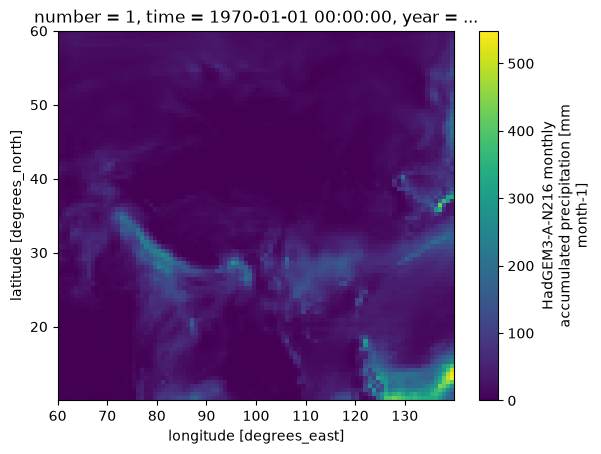

In [13]:
y['precip'].isel(number=0, time=0).plot()

## Step 3 bias correction

Opening regridded CN05 observations...
Opening historical HadGEM precipitation...
Valid HadGEM-grid cells: 2055
Loading and flattening observed samples...
Loading and flattening raw HadGEM samples...

CN05 observations
  Sample count: 1,011,060
  Minimum: 0.0
  Mean: 50.440059661865234
  Median: 20.255233764648438
  95th percentile: 197.0976104736328
  99th percentile: 318.68267822265625
  Maximum: 1514.9912109375

Raw historical HadGEM
  Sample count: 15,165,900
  Minimum: 0.0
  Mean: 67.37007904052734
  Median: 28.313762664794922
  95th percentile: 262.07818603515625
  99th percentile: 443.27471923828125
  Maximum: 2927.6650390625


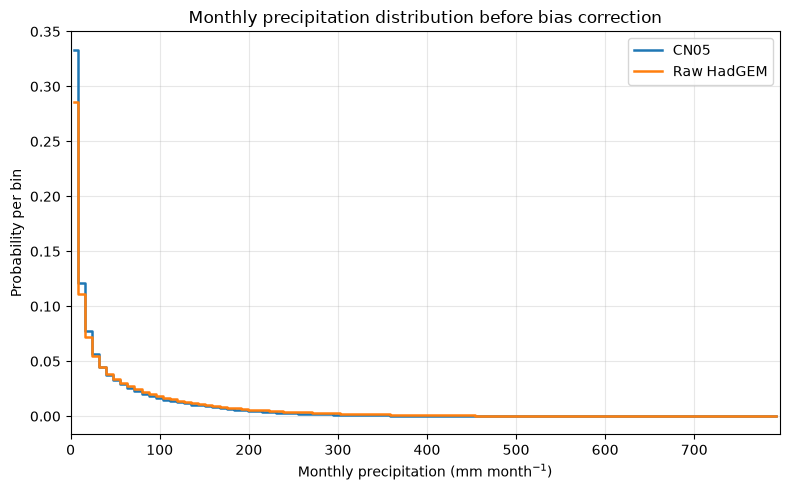

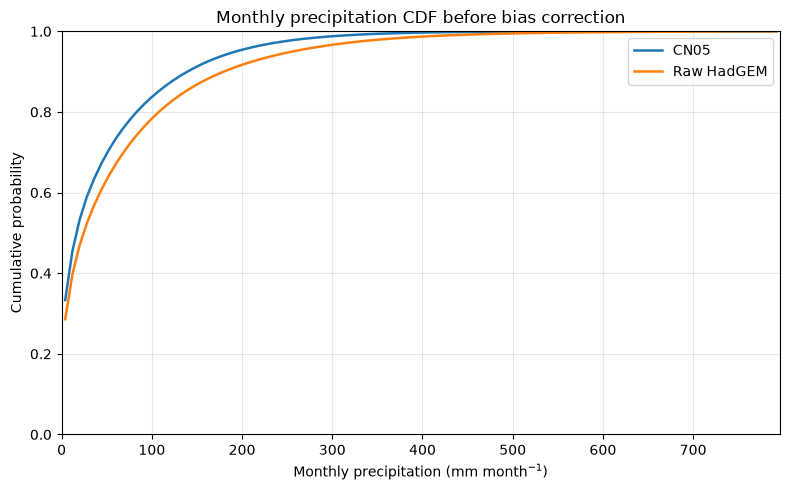

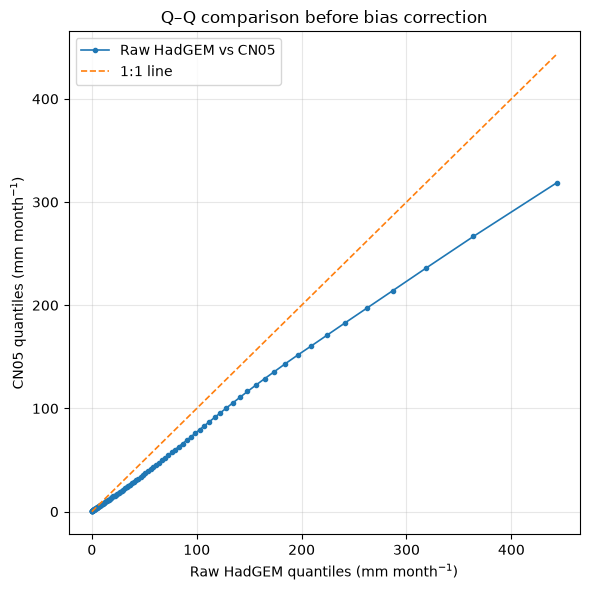


Saved plots:
/home/users/weijia_6/Yangtze_code/gen_result/precip_distribution_before_bias_correction/CN05_vs_HadGEM_before_EQM_PDF.png
/home/users/weijia_6/Yangtze_code/gen_result/precip_distribution_before_bias_correction/CN05_vs_HadGEM_before_EQM_CDF.png
/home/users/weijia_6/Yangtze_code/gen_result/precip_distribution_before_bias_correction/CN05_vs_HadGEM_before_EQM_QQ.png

Before-bias-correction comparison completed.


In [19]:
# Compare distribtuion before bias correction


# ============================================================
# Compare CN05 and raw historical HadGEM distributions
# BEFORE bias correction
#
# Both datasets must be on the HadGEM grid.
# ============================================================

import os
import warnings

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt


xr.set_options(use_flox=False)
warnings.filterwarnings("ignore", category=RuntimeWarning)


# ============================================================
# 1. User settings
# ============================================================

OBS_FILE = (
    "/home/users/weijia_6/Yangtze_code/gen_data/HadGEM/"
    "CN05_monthly_precip_1970_2010_on_HadGEM_grid.nc"
)

MODEL_FILE = (
    "/home/users/weijia_6/Yangtze_code/gen_data/HadGEM/"
    "HadGEM_monthly_precip_1970_2010_15ens.nc"
)

OBS_VAR = "precip"
MODEL_VAR = "precip"

OUTPUT_DIRECTORY = (
    "/home/users/weijia_6/Yangtze_code/gen_result/"
    "precip_distribution_before_bias_correction"
)

os.makedirs(
    OUTPUT_DIRECTORY,
    exist_ok=True,
)

# Histogram settings.
N_BINS = 100

# Q-Q plot probabilities.
QUANTILE_PROBABILITIES = np.linspace(
    0.01,
    0.99,
    99,
)

# Set a common upper display limit using a pooled quantile.
# This prevents a few extreme values from compressing the plot.
DISPLAY_PERCENTILE = 99.9

# Set to None to use every valid sample.
# Set, for example, to 5_000_000 to randomly sample large arrays.
MAX_SAMPLES_PER_DATASET = None

RANDOM_SEED = 42


# ============================================================
# 2. Helpers
# ============================================================

def assert_file_exists(path):
    if not os.path.isfile(path):
        raise FileNotFoundError(
            f"File not found: {path}"
        )


def standardise_coordinates(ds):
    rename = {}

    if "latitude" in ds.coords or "latitude" in ds.dims:
        rename["latitude"] = "lat"

    if "longitude" in ds.coords or "longitude" in ds.dims:
        rename["longitude"] = "lon"

    if rename:
        ds = ds.rename(rename)

    return ds


def grids_match(first, second, tolerance=1e-8):
    if first.lat.shape != second.lat.shape:
        return False

    if first.lon.shape != second.lon.shape:
        return False

    return (
        np.allclose(
            first.lat.values,
            second.lat.values,
            atol=tolerance,
            rtol=0,
        )
        and
        np.allclose(
            first.lon.values,
            second.lon.values,
            atol=tolerance,
            rtol=0,
        )
    )


def get_valid_values(da):
    """
    Load and flatten all finite values.
    """
    values = da.values.reshape(-1)
    values = values[np.isfinite(values)]

    return values.astype(
        np.float32,
        copy=False,
    )


def optionally_subsample(
    values,
    maximum_samples,
    random_generator,
):
    if maximum_samples is None:
        return values

    if values.size <= maximum_samples:
        return values

    indices = random_generator.choice(
        values.size,
        size=maximum_samples,
        replace=False,
    )

    return values[indices]


def create_common_bins(
    observed_values,
    model_values,
    number_of_bins,
    upper_percentile,
):
    lower = 0.0

    observed_upper = np.percentile(
        observed_values,
        upper_percentile,
    )

    model_upper = np.percentile(
        model_values,
        upper_percentile,
    )

    upper = max(
        observed_upper,
        model_upper,
    )

    if not np.isfinite(upper) or upper <= lower:
        raise ValueError(
            "Could not determine a valid histogram range."
        )

    return np.linspace(
        lower,
        upper,
        number_of_bins + 1,
    )


def histogram_probability(values, bins):
    """
    Return probability mass in each histogram bin.

    The sum of the returned array is one for values within the
    plotted range.
    """
    in_range = values[
        (values >= bins[0])
        & (values <= bins[-1])
    ]

    counts, _ = np.histogram(
        in_range,
        bins=bins,
    )

    total = counts.sum()

    if total == 0:
        raise ValueError(
            "Histogram contains no samples."
        )

    probability = (
        counts.astype(np.float64)
        / total
    )

    return probability


def print_summary(label, values):
    print(f"\n{label}")
    print("  Sample count:", f"{values.size:,}")
    print("  Minimum:", float(np.min(values)))
    print("  Mean:", float(np.mean(values)))
    print("  Median:", float(np.median(values)))
    print("  95th percentile:", float(np.percentile(values, 95)))
    print("  99th percentile:", float(np.percentile(values, 99)))
    print("  Maximum:", float(np.max(values)))


# ============================================================
# 3. Load and align datasets
# ============================================================

assert_file_exists(OBS_FILE)
assert_file_exists(MODEL_FILE)

print("Opening regridded CN05 observations...")

obs_ds = xr.open_dataset(
    OBS_FILE,
    decode_cf=True,
    mask_and_scale=True,
)

obs_ds = standardise_coordinates(
    obs_ds
)

print("Opening historical HadGEM precipitation...")

model_ds = xr.open_dataset(
    MODEL_FILE,
    decode_cf=True,
    mask_and_scale=True,
)

model_ds = standardise_coordinates(
    model_ds
)

if OBS_VAR not in obs_ds:
    raise KeyError(
        f"'{OBS_VAR}' not found in observed dataset."
    )

if MODEL_VAR not in model_ds:
    raise KeyError(
        f"'{MODEL_VAR}' not found in model dataset."
    )

obs = obs_ds[OBS_VAR].transpose(
    "time",
    "lat",
    "lon",
)

model = model_ds[MODEL_VAR].transpose(
    "number",
    "time",
    "lat",
    "lon",
)

if not grids_match(obs, model):
    raise ValueError(
        "CN05 and HadGEM are not on the same spatial grid."
    )

if obs.sizes["time"] != model.sizes["time"]:
    raise ValueError(
        "Observed and model time dimensions differ."
    )

if "month_id" in obs_ds and "month_id" in model_ds:
    if not np.array_equal(
        obs_ds.month_id.values,
        model_ds.month_id.values,
    ):
        raise ValueError(
            "Observed and model month_id coordinates differ."
        )


# ============================================================
# 4. Apply common valid spatial mask
# ============================================================

if "valid_calibration_mask" in obs_ds:
    valid_mask = (
        obs_ds["valid_calibration_mask"] == 1
    )
else:
    valid_mask = obs.notnull().all(
        dim="time"
    )

print(
    "Valid HadGEM-grid cells:",
    int(valid_mask.sum().item()),
)

obs_masked = obs.where(
    valid_mask
)

model_masked = model.where(
    valid_mask
)


# ============================================================
# 5. Flatten samples
# ============================================================

print("Loading and flattening observed samples...")
obs_values = get_valid_values(
    obs_masked
)

print("Loading and flattening raw HadGEM samples...")
model_values = get_valid_values(
    model_masked
)

random_generator = np.random.default_rng(
    RANDOM_SEED
)

obs_values = optionally_subsample(
    obs_values,
    MAX_SAMPLES_PER_DATASET,
    random_generator,
)

model_values = optionally_subsample(
    model_values,
    MAX_SAMPLES_PER_DATASET,
    random_generator,
)

print_summary(
    "CN05 observations",
    obs_values,
)

print_summary(
    "Raw historical HadGEM",
    model_values,
)


# ============================================================
# 6. Common histogram bins
# ============================================================

bins = create_common_bins(
    observed_values=obs_values,
    model_values=model_values,
    number_of_bins=N_BINS,
    upper_percentile=DISPLAY_PERCENTILE,
)

bin_centres = (
    bins[:-1] + bins[1:]
) / 2.0

obs_pdf = histogram_probability(
    obs_values,
    bins,
)

model_pdf = histogram_probability(
    model_values,
    bins,
)

obs_cdf = np.cumsum(
    obs_pdf
)

model_cdf = np.cumsum(
    model_pdf
)


# ============================================================
# 7. Quantiles for Q-Q plot
# ============================================================

obs_quantiles = np.quantile(
    obs_values,
    QUANTILE_PROBABILITIES,
)

model_quantiles = np.quantile(
    model_values,
    QUANTILE_PROBABILITIES,
)


# ============================================================
# 8. PDF plot
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    bin_centres,
    obs_pdf,
    drawstyle="steps-mid",
    label="CN05",
    linewidth=1.8,
)

plt.plot(
    bin_centres,
    model_pdf,
    drawstyle="steps-mid",
    label="Raw HadGEM",
    linewidth=1.8,
)

plt.xlabel(
    "Monthly precipitation (mm month$^{-1}$)"
)

plt.ylabel(
    "Probability per bin"
)

plt.title(
    "Monthly precipitation distribution before bias correction"
)

plt.xlim(
    bins[0],
    bins[-1],
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

pdf_path = os.path.join(
    OUTPUT_DIRECTORY,
    "CN05_vs_HadGEM_before_EQM_PDF.png",
)

plt.savefig(
    pdf_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()


# ============================================================
# 9. CDF plot
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    bin_centres,
    obs_cdf,
    label="CN05",
    linewidth=1.8,
)

plt.plot(
    bin_centres,
    model_cdf,
    label="Raw HadGEM",
    linewidth=1.8,
)

plt.xlabel(
    "Monthly precipitation (mm month$^{-1}$)"
)

plt.ylabel(
    "Cumulative probability"
)

plt.title(
    "Monthly precipitation CDF before bias correction"
)

plt.xlim(
    bins[0],
    bins[-1],
)

plt.ylim(
    0,
    1,
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

cdf_path = os.path.join(
    OUTPUT_DIRECTORY,
    "CN05_vs_HadGEM_before_EQM_CDF.png",
)

plt.savefig(
    cdf_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()


# ============================================================
# 10. Q-Q plot
# ============================================================

qq_minimum = min(
    float(obs_quantiles.min()),
    float(model_quantiles.min()),
)

qq_maximum = max(
    float(obs_quantiles.max()),
    float(model_quantiles.max()),
)

plt.figure(
    figsize=(6, 6)
)

plt.plot(
    model_quantiles,
    obs_quantiles,
    marker="o",
    markersize=3,
    linewidth=1.2,
    label="Raw HadGEM vs CN05",
)

plt.plot(
    [qq_minimum, qq_maximum],
    [qq_minimum, qq_maximum],
    linestyle="--",
    linewidth=1.2,
    label="1:1 line",
)

plt.xlabel(
    "Raw HadGEM quantiles (mm month$^{-1}$)"
)

plt.ylabel(
    "CN05 quantiles (mm month$^{-1}$)"
)

plt.title(
    "Q–Q comparison before bias correction"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

qq_path = os.path.join(
    OUTPUT_DIRECTORY,
    "CN05_vs_HadGEM_before_EQM_QQ.png",
)

plt.savefig(
    qq_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()


# ============================================================
# 11. Finish
# ============================================================

obs_ds.close()
model_ds.close()

print("\nSaved plots:")
print(pdf_path)
print(cdf_path)
print(qq_path)

print("\nBefore-bias-correction comparison completed.")

In [18]:
# ============================================================
# Step 3:
# Create monthly empirical quantile-mapping tables between:
#
#   Observations: CN05.1, 1970-2010
#   Model:        HadGEM3-A-N216 historical, 15 ensembles,
#                 1970-2010
#
# The mapping is calculated separately for:
#   - each calendar month
#   - each HadGEM grid cell
#
# Output:
#   - CN05 regridded onto the HadGEM grid
#   - saved empirical quantile-mapping lookup tables
# ============================================================

import os
import warnings

import numpy as np
import xarray as xr


# Avoid the flox -> sparse -> numba incompatibility.
xr.set_options(use_flox=False)

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
)


# ============================================================
# 1. User settings
# ============================================================

OBS_NC = (
    "/home/users/weijia_6/Yangtze_code/gen_data/CN05.1/"
    "CN05_monthly_precip_grid_1970_2010.nc"
)

MODEL_NC = (
    "/home/users/weijia_6/Yangtze_code/gen_data/HadGEM/"
    "HadGEM_monthly_precip_1970_2010_15ens.nc"
)

OBS_REGRIDDED_NC = (
    "/home/users/weijia_6/Yangtze_code/gen_data/HadGEM/"
    "CN05_monthly_precip_1970_2010_on_HadGEM_grid.nc"
)

MAPPING_NC = (
    "/home/users/weijia_6/Yangtze_code/gen_data/HadGEM/"
    "HadGEM_CN05_EQM_mapping_1970_2010.nc"
)

OBS_VAR = "precip"
MODEL_VAR = "precip"

START_YEAR = 1970
END_YEAR = 2010

EXPECTED_MONTHS = (
    END_YEAR - START_YEAR + 1
) * 12

EXPECTED_OBS_SAMPLES_PER_MONTH = (
    END_YEAR - START_YEAR + 1
)  # 41

EXPECTED_MODEL_SAMPLES_PER_MONTH = (
    15 * EXPECTED_OBS_SAMPLES_PER_MONTH
)  # 615


# Number of empirical quantile knots.
#
# CN05 contains 41 values for each calendar month, so using
# 41 quantile levels is a transparent choice.
N_QUANTILES = 41

QUANTILE_LEVELS = np.linspace(
    0.0,
    1.0,
    N_QUANTILES,
    dtype=np.float32,
)

# Minimum sample requirements for creating a mapping.
MIN_OBS_SAMPLES = 30
MIN_MODEL_SAMPLES = 300

# Used only as a diagnostic for very dry monthly values.
DRY_THRESHOLD_MM = np.float32(0.1)


# ============================================================
# 2. General helpers
# ============================================================

def assert_file_exists(path):
    """Check that a required input file exists."""
    if not os.path.isfile(path):
        raise FileNotFoundError(
            f"File not found: {path}"
        )


def standardise_coordinate_names(ds):
    """
    Rename common latitude and longitude names to lat and lon.
    """
    rename = {}

    if "latitude" in ds.coords or "latitude" in ds.dims:
        rename["latitude"] = "lat"

    if "longitude" in ds.coords or "longitude" in ds.dims:
        rename["longitude"] = "lon"

    if rename:
        ds = ds.rename(rename)

    required = {"time", "lat", "lon"}
    missing = required.difference(ds.coords)

    if missing:
        raise ValueError(
            f"Missing required coordinates: {sorted(missing)}. "
            f"Available coordinates: {list(ds.coords)}"
        )

    return ds


def ensure_latitude_ascending(ds):
    """Ensure latitude runs from south to north."""
    if (
        ds.lat.size > 1
        and float(ds.lat.values[0])
        > float(ds.lat.values[-1])
    ):
        ds = ds.sortby("lat")

    return ds


def convert_longitude_to_minus180_180(ds):
    """
    Convert 0-360 longitudes to -180-180 if necessary.
    """
    lon_min = float(ds.lon.min())
    lon_max = float(ds.lon.max())

    if lon_min >= 0 and lon_max > 180:
        new_lon = (
            (ds.lon + 180) % 360
        ) - 180

        ds = (
            ds.assign_coords(lon=new_lon)
            .sortby("lon")
        )

    return ds


def create_month_id(time):
    """Create YYYYMM identifiers for any decoded calendar."""
    years = time.dt.year.values.astype(
        np.int32
    )

    months = time.dt.month.values.astype(
        np.int32
    )

    return years * 100 + months


def expected_month_ids():
    """Create January 1970 through December 2010 IDs."""
    return np.array(
        [
            year * 100 + month
            for year in range(
                START_YEAR,
                END_YEAR + 1,
            )
            for month in range(1, 13)
        ],
        dtype=np.int32,
    )


def verify_time_period(da, label):
    """
    Check that a dataset contains the complete 1970-2010
    monthly sequence.
    """
    if da.sizes.get("time") != EXPECTED_MONTHS:
        raise ValueError(
            f"{label} should contain {EXPECTED_MONTHS} months, "
            f"but contains {da.sizes.get('time')}."
        )

    actual_ids = create_month_id(
        da.time
    )

    required_ids = expected_month_ids()

    if not np.array_equal(
        actual_ids,
        required_ids,
    ):
        missing = np.setdiff1d(
            required_ids,
            actual_ids,
        )

        unexpected = np.setdiff1d(
            actual_ids,
            required_ids,
        )

        raise ValueError(
            f"{label} has an incomplete or incorrectly ordered "
            "monthly sequence.\n"
            f"Missing IDs: {missing}\n"
            f"Unexpected IDs: {unexpected}"
        )

    print(
        f"[TIME CHECK] {label}: "
        f"{actual_ids[0]} to {actual_ids[-1]}, "
        f"{len(actual_ids)} months."
    )


def verify_precipitation_units(da, label):
    """
    Require processed monthly precipitation units.
    """
    units = str(
        da.attrs.get("units", "")
    ).strip().lower()

    accepted = {
        "mm month-1",
        "mm/month",
        "mm",
    }

    if units not in accepted:
        raise ValueError(
            f"Unexpected precipitation units for {label}: "
            f"'{units}'. Expected monthly accumulated "
            "precipitation."
        )

    print(
        f"[UNIT CHECK] {label}: {units}"
    )


def grids_are_identical(first, second, tolerance=1e-8):
    """Check whether two datasets use the same lat-lon grid."""
    if first.lat.shape != second.lat.shape:
        return False

    if first.lon.shape != second.lon.shape:
        return False

    same_lat = np.allclose(
        first.lat.values,
        second.lat.values,
        atol=tolerance,
        rtol=0,
    )

    same_lon = np.allclose(
        first.lon.values,
        second.lon.values,
        atol=tolerance,
        rtol=0,
    )

    return same_lat and same_lon


# ============================================================
# 3. Open and validate source datasets
# ============================================================

def load_source_datasets():
    """
    Open CN05 and HadGEM and perform basic validation.
    """
    assert_file_exists(OBS_NC)
    assert_file_exists(MODEL_NC)

    print("Opening CN05 observations...")

    obs_ds = xr.open_dataset(
        OBS_NC,
        decode_cf=True,
        mask_and_scale=True,
    )

    obs_ds = standardise_coordinate_names(
        obs_ds
    )

    obs_ds = convert_longitude_to_minus180_180(
        obs_ds
    )

    obs_ds = ensure_latitude_ascending(
        obs_ds
    )

    if OBS_VAR not in obs_ds.data_vars:
        raise KeyError(
            f"Variable '{OBS_VAR}' not found in CN05 file. "
            f"Available variables: {list(obs_ds.data_vars)}"
        )

    obs = obs_ds[OBS_VAR].transpose(
        "time",
        "lat",
        "lon",
    )

    print("Opening HadGEM historical precipitation...")

    model_ds = xr.open_dataset(
        MODEL_NC,
        decode_cf=True,
        mask_and_scale=True,
    )

    model_ds = standardise_coordinate_names(
        model_ds
    )

    model_ds = convert_longitude_to_minus180_180(
        model_ds
    )

    model_ds = ensure_latitude_ascending(
        model_ds
    )

    if MODEL_VAR not in model_ds.data_vars:
        raise KeyError(
            f"Variable '{MODEL_VAR}' not found in HadGEM file. "
            f"Available variables: {list(model_ds.data_vars)}"
        )

    model = model_ds[MODEL_VAR].transpose(
        "number",
        "time",
        "lat",
        "lon",
    )

    if model.sizes.get("number") != 15:
        raise ValueError(
            "The historical HadGEM dataset should contain "
            f"15 ensembles, but contains "
            f"{model.sizes.get('number')}."
        )

    verify_time_period(
        obs,
        "CN05",
    )

    verify_time_period(
        model,
        "HadGEM",
    )

    verify_precipitation_units(
        obs,
        "CN05",
    )

    verify_precipitation_units(
        model,
        "HadGEM",
    )

    print("\n========== SOURCE DATASETS ==========")
    print("CN05 dimensions:", dict(obs.sizes))
    print("HadGEM dimensions:", dict(model.sizes))

    print(
        "CN05 grid:",
        obs.sizes["lat"],
        "x",
        obs.sizes["lon"],
    )

    print(
        "HadGEM grid:",
        model.sizes["lat"],
        "x",
        model.sizes["lon"],
    )

    print(
        "CN05 latitude range:",
        float(obs.lat.min()),
        "to",
        float(obs.lat.max()),
    )

    print(
        "CN05 longitude range:",
        float(obs.lon.min()),
        "to",
        float(obs.lon.max()),
    )

    print(
        "HadGEM latitude range:",
        float(model.lat.min()),
        "to",
        float(model.lat.max()),
    )

    print(
        "HadGEM longitude range:",
        float(model.lon.min()),
        "to",
        float(model.lon.max()),
    )

    return obs_ds, model_ds, obs, model


# ============================================================
# 4. Regrid CN05 onto HadGEM grid
# ============================================================

def regrid_cn05_to_hadgem(obs, model):
    """
    Regrid CN05 monthly precipitation onto the HadGEM grid.

    Method:
      1. Retain only CN05 cells with observations in every month.
      2. Perform linear interpolation onto HadGEM lat-lon points.
      3. Use nearest-neighbour values only as a coastal fallback.
      4. Mask all HadGEM cells whose nearest CN05 source cell is
         not a consistently valid observation cell.

    This keeps the final mapping on the native HadGEM grid.
    """

    print(
        "\nCreating complete CN05 calibration mask..."
    )

    obs_complete_mask = obs.notnull().all(
        dim="time"
    )

    complete_cell_count = int(
        obs_complete_mask.sum().compute()
    )

    print(
        "CN05 cells valid in every month:",
        complete_cell_count,
    )

    obs_complete = obs.where(
        obs_complete_mask
    )

    print(
        "Interpolating CN05 onto the HadGEM grid..."
    )

    # Bilinear interpolation is used for the main field.
    obs_linear = obs_complete.interp(
        lat=model.lat,
        lon=model.lon,
        method="linear",
    )

    # Nearest-neighbour field is used only where linear
    # interpolation gives a coastal NaN.
    obs_nearest = obs_complete.interp(
        lat=model.lat,
        lon=model.lon,
        method="nearest",
    )

    # Regrid the complete-data mask with nearest neighbour.
    model_grid_valid_mask = (
        obs_complete_mask.astype(np.float32)
        .interp(
            lat=model.lat,
            lon=model.lon,
            method="nearest",
        )
        >= 0.5
    )

    # Prefer linear interpolation. Use nearest only for valid
    # coastal target cells where linear interpolation failed.
    obs_on_model = xr.where(
        obs_linear.notnull(),
        obs_linear,
        obs_nearest,
    )

    obs_on_model = obs_on_model.where(
        model_grid_valid_mask
    )

    obs_on_model = obs_on_model.transpose(
        "time",
        "lat",
        "lon",
    )

    obs_on_model = obs_on_model.astype(
        np.float32
    )

    obs_on_model.name = "precip"

    obs_on_model.attrs = {
        "long_name": (
            "CN05.1 monthly accumulated precipitation "
            "interpolated onto the HadGEM3-A-N216 grid"
        ),
        "units": "mm month-1",
        "source_grid": "CN05.1 0.25 degree",
        "target_grid": "HadGEM3-A-N216 CHINAcut",
        "primary_interpolation": "linear",
        "coastal_fallback": "nearest neighbour",
        "mask_method": (
            "Nearest-neighbour interpolation of the CN05 mask "
            "requiring valid data in all 492 calibration months"
        ),
    }

    if not grids_are_identical(
        obs_on_model,
        model,
    ):
        raise RuntimeError(
            "Regridded CN05 and HadGEM grids do not match."
        )

    valid_any = obs_on_model.notnull().any(
        dim="time"
    )

    valid_all = obs_on_model.notnull().all(
        dim="time"
    )

    intermittent = valid_any & ~valid_all

    print("\n========== REGRIDDED CN05 CHECK ==========")
    print(
        "Dimensions:",
        dict(obs_on_model.sizes),
    )

    print(
        "HadGEM-grid cells valid at least once:",
        int(valid_any.sum().compute()),
    )

    print(
        "HadGEM-grid cells valid in every month:",
        int(valid_all.sum().compute()),
    )

    print(
        "Intermittently valid target cells:",
        int(intermittent.sum().compute()),
    )

    print(
        "Mean precipitation:",
        float(
            obs_on_model.mean(
                skipna=True
            ).compute()
        ),
        "mm/month",
    )

    return obs_on_model, valid_all


# ============================================================
# 5. Save regridded CN05
# ============================================================

def save_regridded_cn05(
    obs_on_model,
    model_grid_valid_mask,
):
    """Save CN05 precipitation on the HadGEM grid."""
    years = obs_on_model.time.dt.year.values.astype(
        np.int32
    )

    months = obs_on_model.time.dt.month.values.astype(
        np.int8
    )

    month_ids = (
        years.astype(np.int32) * 100
        + months.astype(np.int32)
    )

    obs_output = obs_on_model.assign_coords(
        year=("time", years),
        month=("time", months),
        month_id=("time", month_ids),
    )

    output = xr.Dataset(
        {
            "precip": obs_output,
            "valid_calibration_mask": (
                model_grid_valid_mask.astype(np.int8)
            ),
        }
    )

    output.valid_calibration_mask.attrs = {
        "long_name": (
            "HadGEM grid cells with complete regridded CN05 "
            "precipitation for 1970-2010"
        ),
        "values": "1 valid, 0 invalid",
    }

    output.attrs = {
        "title": (
            "CN05.1 monthly precipitation on the "
            "HadGEM3-A-N216 grid, 1970-2010"
        ),
        "source_dataset": "CN05.1",
        "target_grid": "HadGEM3-A-N216 CHINAcut",
        "temporal_coverage": "1970-01 to 2010-12",
        "units": "mm month-1",
        "purpose": (
            "Observed reference dataset for empirical "
            "quantile mapping"
        ),
    }

    os.makedirs(
        os.path.dirname(OBS_REGRIDDED_NC),
        exist_ok=True,
    )

    output.time.encoding = {}

    encoding = {
        "precip": {
            "dtype": "float32",
            "zlib": True,
            "complevel": 4,
            "_FillValue": np.float32(-9999.0),
            "chunksizes": (
                12,
                min(45, output.sizes["lat"]),
                min(48, output.sizes["lon"]),
            ),
        },
        "valid_calibration_mask": {
            "dtype": "int8",
            "zlib": True,
            "complevel": 4,
            "_FillValue": None,
        },
        "time": {
            "dtype": "int64",
            "units": (
                "hours since 1970-01-01 00:00:00"
            ),
            "calendar": "proleptic_gregorian",
        },
        "year": {
            "dtype": "int32",
        },
        "month": {
            "dtype": "int8",
        },
        "month_id": {
            "dtype": "int32",
        },
    }

    print(
        "\nSaving CN05 regridded onto HadGEM grid..."
    )

    output.to_netcdf(
        OBS_REGRIDDED_NC,
        encoding=encoding,
    )

    print("Saved:")
    print(OBS_REGRIDDED_NC)


# ============================================================
# 6. Quantile calculation helpers
# ============================================================

def month_time_indices(time, month_number):
    """Return indices for one calendar month."""
    return np.flatnonzero(
        time.dt.month.values == month_number
    )


def calculate_monthly_mapping(
    obs_on_model,
    model,
    model_grid_valid_mask,
):
    """
    Calculate empirical quantiles separately for each month
    and HadGEM grid cell.

    Observational sample:
        41 years per month

    Model sample:
        15 ensembles x 41 years = 615 values per month
    """

    nlat = model.sizes["lat"]
    nlon = model.sizes["lon"]
    nq = len(QUANTILE_LEVELS)

    shape_quantile = (
        12,
        nq,
        nlat,
        nlon,
    )

    shape_month_grid = (
        12,
        nlat,
        nlon,
    )

    obs_quantiles = np.full(
        shape_quantile,
        np.nan,
        dtype=np.float32,
    )

    model_quantiles = np.full(
        shape_quantile,
        np.nan,
        dtype=np.float32,
    )

    obs_sample_count = np.zeros(
        shape_month_grid,
        dtype=np.int16,
    )

    model_sample_count = np.zeros(
        shape_month_grid,
        dtype=np.int16,
    )

    obs_dry_fraction = np.full(
        shape_month_grid,
        np.nan,
        dtype=np.float32,
    )

    model_dry_fraction = np.full(
        shape_month_grid,
        np.nan,
        dtype=np.float32,
    )

    monthly_valid_mapping = np.zeros(
        shape_month_grid,
        dtype=np.int8,
    )

    spatial_mask = (
        model_grid_valid_mask.values.astype(bool)
    )

    print(
        "\nCalculating monthly empirical quantile mappings..."
    )

    for month_number in range(1, 13):
        print(
            f"\nMonth {month_number:02d}"
        )

        obs_indices = month_time_indices(
            obs_on_model.time,
            month_number,
        )

        model_indices = month_time_indices(
            model.time,
            month_number,
        )

        if len(obs_indices) != EXPECTED_OBS_SAMPLES_PER_MONTH:
            raise ValueError(
                f"Expected "
                f"{EXPECTED_OBS_SAMPLES_PER_MONTH} CN05 "
                f"samples for month {month_number}, but found "
                f"{len(obs_indices)}."
            )

        if len(model_indices) != EXPECTED_OBS_SAMPLES_PER_MONTH:
            raise ValueError(
                f"Expected "
                f"{EXPECTED_OBS_SAMPLES_PER_MONTH} HadGEM "
                f"time records for month {month_number}, but "
                f"found {len(model_indices)}."
            )

        obs_month = (
            obs_on_model
            .isel(time=obs_indices)
            .transpose(
                "time",
                "lat",
                "lon",
            )
            .load()
        )

        model_month = (
            model
            .isel(time=model_indices)
            .transpose(
                "number",
                "time",
                "lat",
                "lon",
            )
            .load()
        )

        obs_values = obs_month.values.astype(
            np.float32
        )

        # Pool all 15 HadGEM historical ensembles.
        model_values = (
            model_month.values
            .reshape(
                -1,
                nlat,
                nlon,
            )
            .astype(np.float32)
        )

        if (
            model_values.shape[0]
            != EXPECTED_MODEL_SAMPLES_PER_MONTH
        ):
            raise ValueError(
                f"Expected "
                f"{EXPECTED_MODEL_SAMPLES_PER_MONTH} pooled "
                f"HadGEM samples for month {month_number}, "
                f"but found {model_values.shape[0]}."
            )

        obs_count = np.sum(
            np.isfinite(obs_values),
            axis=0,
        ).astype(np.int16)

        model_count = np.sum(
            np.isfinite(model_values),
            axis=0,
        ).astype(np.int16)

        valid_mapping = (
            spatial_mask
            & (obs_count >= MIN_OBS_SAMPLES)
            & (model_count >= MIN_MODEL_SAMPLES)
        )

        # Compute empirical quantiles along the sample dimension.
        with warnings.catch_warnings():
            warnings.simplefilter(
                "ignore",
                category=RuntimeWarning,
            )

            obs_q = np.nanquantile(
                obs_values,
                QUANTILE_LEVELS,
                axis=0,
            ).astype(np.float32)

            model_q = np.nanquantile(
                model_values,
                QUANTILE_LEVELS,
                axis=0,
            ).astype(np.float32)

        # Set invalid grid cells to NaN for all quantiles.
        obs_q[:, ~valid_mapping] = np.nan
        model_q[:, ~valid_mapping] = np.nan

        obs_dry_count = np.sum(
            np.isfinite(obs_values)
            & (obs_values <= DRY_THRESHOLD_MM),
            axis=0,
        )

        model_dry_count = np.sum(
            np.isfinite(model_values)
            & (model_values <= DRY_THRESHOLD_MM),
            axis=0,
        )

        obs_dry = np.full(
            (nlat, nlon),
            np.nan,
            dtype=np.float32,
        )

        model_dry = np.full(
            (nlat, nlon),
            np.nan,
            dtype=np.float32,
        )

        np.divide(
            obs_dry_count,
            obs_count,
            out=obs_dry,
            where=obs_count > 0,
        )

        np.divide(
            model_dry_count,
            model_count,
            out=model_dry,
            where=model_count > 0,
        )

        obs_dry[~valid_mapping] = np.nan
        model_dry[~valid_mapping] = np.nan

        month_index = month_number - 1

        obs_quantiles[
            month_index,
            :,
            :,
            :,
        ] = obs_q

        model_quantiles[
            month_index,
            :,
            :,
            :,
        ] = model_q

        obs_sample_count[
            month_index,
            :,
            :,
        ] = obs_count

        model_sample_count[
            month_index,
            :,
            :,
        ] = model_count

        obs_dry_fraction[
            month_index,
            :,
            :,
        ] = obs_dry

        model_dry_fraction[
            month_index,
            :,
            :,
        ] = model_dry

        monthly_valid_mapping[
            month_index,
            :,
            :,
        ] = valid_mapping.astype(
            np.int8
        )

        print(
            "  Valid mapping cells:",
            int(valid_mapping.sum()),
        )

        print(
            "  CN05 sample-count range:",
            int(obs_count[valid_mapping].min()),
            "to",
            int(obs_count[valid_mapping].max()),
        )

        print(
            "  HadGEM sample-count range:",
            int(model_count[valid_mapping].min()),
            "to",
            int(model_count[valid_mapping].max()),
        )

        del obs_month
        del model_month
        del obs_values
        del model_values
        del obs_q
        del model_q

    return {
        "obs_quantiles": obs_quantiles,
        "model_quantiles": model_quantiles,
        "obs_sample_count": obs_sample_count,
        "model_sample_count": model_sample_count,
        "obs_dry_fraction": obs_dry_fraction,
        "model_dry_fraction": model_dry_fraction,
        "monthly_valid_mapping": monthly_valid_mapping,
    }


# ============================================================
# 7. Construct mapping dataset
# ============================================================

def create_mapping_dataset(
    model,
    mapping_arrays,
):
    """Construct the saved NetCDF mapping dataset."""
    mapping = xr.Dataset(
        data_vars={
            "model_quantile": (
                (
                    "month",
                    "quantile",
                    "lat",
                    "lon",
                ),
                mapping_arrays[
                    "model_quantiles"
                ],
            ),
            "observed_quantile": (
                (
                    "month",
                    "quantile",
                    "lat",
                    "lon",
                ),
                mapping_arrays[
                    "obs_quantiles"
                ],
            ),
            "obs_sample_count": (
                (
                    "month",
                    "lat",
                    "lon",
                ),
                mapping_arrays[
                    "obs_sample_count"
                ],
            ),
            "model_sample_count": (
                (
                    "month",
                    "lat",
                    "lon",
                ),
                mapping_arrays[
                    "model_sample_count"
                ],
            ),
            "observed_dry_fraction": (
                (
                    "month",
                    "lat",
                    "lon",
                ),
                mapping_arrays[
                    "obs_dry_fraction"
                ],
            ),
            "model_dry_fraction": (
                (
                    "month",
                    "lat",
                    "lon",
                ),
                mapping_arrays[
                    "model_dry_fraction"
                ],
            ),
            "valid_mapping": (
                (
                    "month",
                    "lat",
                    "lon",
                ),
                mapping_arrays[
                    "monthly_valid_mapping"
                ],
            ),
        },
        coords={
            "month": np.arange(
                1,
                13,
                dtype=np.int8,
            ),
            "quantile": QUANTILE_LEVELS,
            "lat": model.lat.values,
            "lon": model.lon.values,
        },
    )

    mapping.model_quantile.attrs = {
        "long_name": (
            "Historical HadGEM precipitation quantile"
        ),
        "units": "mm month-1",
        "sample_definition": (
            "15 historical ensemble members pooled across "
            "1970-2010 separately for each calendar month"
        ),
    }

    mapping.observed_quantile.attrs = {
        "long_name": (
            "CN05 precipitation quantile on the HadGEM grid"
        ),
        "units": "mm month-1",
        "sample_definition": (
            "CN05 observations from 1970-2010 separately "
            "for each calendar month"
        ),
    }

    mapping["quantile"].attrs = {
        "long_name": "non-exceedance probability",
        "valid_min": np.float32(0.0),
        "valid_max": np.float32(1.0),
    }

    mapping.obs_sample_count.attrs = {
        "long_name": (
            "Number of valid CN05 samples used to estimate "
            "the monthly mapping"
        ),
    }

    mapping.model_sample_count.attrs = {
        "long_name": (
            "Number of valid pooled HadGEM historical samples "
            "used to estimate the monthly mapping"
        ),
    }

    mapping.observed_dry_fraction.attrs = {
        "long_name": (
            "Fraction of observed monthly precipitation values "
            f"less than or equal to {DRY_THRESHOLD_MM} mm"
        ),
        "units": "1",
    }

    mapping.model_dry_fraction.attrs = {
        "long_name": (
            "Fraction of historical HadGEM monthly precipitation "
            f"values less than or equal to "
            f"{DRY_THRESHOLD_MM} mm"
        ),
        "units": "1",
    }

    mapping.valid_mapping.attrs = {
        "long_name": (
            "Grid cells where the empirical quantile mapping "
            "is valid"
        ),
        "values": "1 valid, 0 invalid",
    }

    mapping.attrs = {
        "title": (
            "Empirical quantile-mapping tables for "
            "HadGEM3-A-N216 precipitation against CN05.1"
        ),
        "method": "monthly empirical quantile mapping",
        "calibration_period": "1970-01 to 2010-12",
        "model": "HadGEM3-A-N216 historical",
        "model_ensemble_sample": (
            "15 members pooled, r1i1p1 through r1i1p15"
        ),
        "observations": "CN05.1",
        "mapping_grid": "HadGEM3-A-N216 CHINAcut grid",
        "mapping_dimensions": (
            "calendar month, quantile probability, latitude, "
            "longitude"
        ),
        "number_of_quantiles": N_QUANTILES,
        "minimum_observation_samples": MIN_OBS_SAMPLES,
        "minimum_model_samples": MIN_MODEL_SAMPLES,
        "dry_threshold_mm_month": float(
            DRY_THRESHOLD_MM
        ),
        "application_definition": (
            "For a model value x, determine its empirical "
            "probability by interpolation against model_quantile; "
            "then interpolate observed_quantile at the same "
            "probability. Apply separately by calendar month "
            "and grid cell."
        ),
        "extrapolation_note": (
            "Values below or above the saved historical quantile "
            "range require an explicitly chosen tail treatment "
            "during application. A later application script "
            "should use either constant-endpoint or linear-tail "
            "extrapolation consistently for factual and "
            "counterfactual ensembles."
        ),
    }

    return mapping


# ============================================================
# 8. Validate mapping
# ============================================================

def validate_mapping(mapping):
    """Perform structural and numerical checks."""
    expected_sizes = {
        "month": 12,
        "quantile": N_QUANTILES,
        "lat": 90,
        "lon": 96,
    }

    print(
        "\n========== MAPPING CHECKS =========="
    )

    print(
        "Dimensions:",
        dict(mapping.sizes),
    )

    for dimension, expected in expected_sizes.items():
        actual = mapping.sizes.get(
            dimension
        )

        if actual != expected:
            raise ValueError(
                f"Expected {dimension}={expected}, "
                f"but found {actual}."
            )

    if not np.array_equal(
        mapping.month.values,
        np.arange(1, 13),
    ):
        raise ValueError(
            "Month coordinate is incorrect."
        )

    valid_count_by_month = (
        mapping.valid_mapping
        .sum(dim=("lat", "lon"))
        .values
    )

    print(
        "Valid mapping cells by month:",
        valid_count_by_month,
    )

    if np.any(valid_count_by_month == 0):
        raise ValueError(
            "At least one calendar month has no valid "
            "mapping cells."
        )

    # Quantiles must be non-decreasing.
    model_difference = (
        mapping.model_quantile.diff(
            dim="quantile"
        )
    )

    obs_difference = (
        mapping.observed_quantile.diff(
            dim="quantile"
        )
    )

    model_bad = (
        model_difference < -1e-5
    ).sum().item()

    obs_bad = (
        obs_difference < -1e-5
    ).sum().item()

    print(
        "Decreasing model quantile intervals:",
        int(model_bad),
    )

    print(
        "Decreasing observed quantile intervals:",
        int(obs_bad),
    )

    if model_bad > 0 or obs_bad > 0:
        raise ValueError(
            "One or more saved quantile sequences are "
            "not non-decreasing."
        )

    print(
        "Mean model precipitation at median quantile:",
        float(
            mapping.model_quantile
            .sel(
                quantile=0.5,
                method="nearest",
            )
            .mean(
                skipna=True
            )
        ),
        "mm/month",
    )

    print(
        "Mean observed precipitation at median quantile:",
        float(
            mapping.observed_quantile
            .sel(
                quantile=0.5,
                method="nearest",
            )
            .mean(
                skipna=True
            )
        ),
        "mm/month",
    )


# ============================================================
# 9. Save and verify mapping
# ============================================================

def save_mapping(mapping):
    """Save empirical quantile-mapping lookup tables."""
    os.makedirs(
        os.path.dirname(MAPPING_NC),
        exist_ok=True,
    )

    quantile_chunks = (
        1,
        N_QUANTILES,
        min(45, mapping.sizes["lat"]),
        min(48, mapping.sizes["lon"]),
    )

    month_grid_chunks = (
        1,
        min(45, mapping.sizes["lat"]),
        min(48, mapping.sizes["lon"]),
    )

    encoding = {
        "model_quantile": {
            "dtype": "float32",
            "zlib": True,
            "complevel": 4,
            "_FillValue": np.float32(-9999.0),
            "chunksizes": quantile_chunks,
        },
        "observed_quantile": {
            "dtype": "float32",
            "zlib": True,
            "complevel": 4,
            "_FillValue": np.float32(-9999.0),
            "chunksizes": quantile_chunks,
        },
        "obs_sample_count": {
            "dtype": "int16",
            "zlib": True,
            "complevel": 4,
            "_FillValue": np.int16(-9999),
            "chunksizes": month_grid_chunks,
        },
        "model_sample_count": {
            "dtype": "int16",
            "zlib": True,
            "complevel": 4,
            "_FillValue": np.int16(-9999),
            "chunksizes": month_grid_chunks,
        },
        "observed_dry_fraction": {
            "dtype": "float32",
            "zlib": True,
            "complevel": 4,
            "_FillValue": np.float32(-9999.0),
            "chunksizes": month_grid_chunks,
        },
        "model_dry_fraction": {
            "dtype": "float32",
            "zlib": True,
            "complevel": 4,
            "_FillValue": np.float32(-9999.0),
            "chunksizes": month_grid_chunks,
        },
        "valid_mapping": {
            "dtype": "int8",
            "zlib": True,
            "complevel": 4,
            "_FillValue": None,
            "chunksizes": month_grid_chunks,
        },
        "month": {
            "dtype": "int8",
        },
        "quantile": {
            "dtype": "float32",
        },
    }

    print(
        "\nSaving empirical quantile mapping..."
    )

    mapping.to_netcdf(
        MAPPING_NC,
        encoding=encoding,
    )

    print("Saved:")
    print(MAPPING_NC)


def verify_saved_mapping():
    """Reopen the saved mapping file."""
    print(
        "\n========== SAVED-MAPPING VERIFICATION =========="
    )

    with xr.open_dataset(
        MAPPING_NC,
        decode_cf=True,
        mask_and_scale=True,
    ) as check:

        print(check)

        if check.sizes.get("month") != 12:
            raise RuntimeError(
                "Saved mapping does not contain 12 months."
            )

        if (
            check.sizes.get("quantile")
            != N_QUANTILES
        ):
            raise RuntimeError(
                "Saved mapping contains an unexpected "
                "number of quantiles."
            )

        if (
            check.sizes.get("lat") != 90
            or check.sizes.get("lon") != 96
        ):
            raise RuntimeError(
                "Saved mapping is not on the expected "
                "HadGEM grid."
            )

        print(
            "Valid mapping cells by month:",
            check.valid_mapping
            .sum(("lat", "lon"))
            .values,
        )

        print(
            "Model quantile range:",
            float(
                check.model_quantile.min(
                    skipna=True
                )
            ),
            "to",
            float(
                check.model_quantile.max(
                    skipna=True
                )
            ),
            "mm/month",
        )

        print(
            "Observed quantile range:",
            float(
                check.observed_quantile.min(
                    skipna=True
                )
            ),
            "to",
            float(
                check.observed_quantile.max(
                    skipna=True
                )
            ),
            "mm/month",
        )

    print(
        "\nSaved-mapping verification passed."
    )


# ============================================================
# 10. Main workflow
# ============================================================

def main():
    (
        obs_ds,
        model_ds,
        obs,
        model,
    ) = load_source_datasets()

    try:
        (
            obs_on_model,
            model_grid_valid_mask,
        ) = regrid_cn05_to_hadgem(
            obs,
            model,
        )

        save_regridded_cn05(
            obs_on_model,
            model_grid_valid_mask,
        )

        mapping_arrays = calculate_monthly_mapping(
            obs_on_model,
            model,
            model_grid_valid_mask,
        )

        mapping = create_mapping_dataset(
            model,
            mapping_arrays,
        )

        validate_mapping(
            mapping
        )

        save_mapping(
            mapping
        )

        verify_saved_mapping()

        print(
            "\nStep 3 completed successfully."
        )

    finally:
        obs_ds.close()
        model_ds.close()


if __name__ == "__main__":
    main()

Opening CN05 observations...
Opening HadGEM historical precipitation...
[TIME CHECK] CN05: 197001 to 201012, 492 months.
[TIME CHECK] HadGEM: 197001 to 201012, 492 months.
[UNIT CHECK] CN05: mm month-1
[UNIT CHECK] HadGEM: mm month-1

========== SOURCE DATASETS ==========
CN05 dimensions: {'time': 492, 'lat': 163, 'lon': 283}
HadGEM dimensions: {'number': 15, 'time': 492, 'lat': 90, 'lon': 96}
CN05 grid: 163 x 283
HadGEM grid: 90 x 96
CN05 latitude range: 14.75 to 55.25
CN05 longitude range: 69.75 to 140.25
HadGEM latitude range: 10.27778172492981 to 59.72222852706909
HadGEM longitude range: 60.416665226221085 to 139.58333000540733

Creating complete CN05 calibration mask...
CN05 cells valid in every month: 15247
Interpolating CN05 onto the HadGEM grid...

========== REGRIDDED CN05 CHECK ==========
Dimensions: {'time': 492, 'lat': 90, 'lon': 96}
HadGEM-grid cells valid at least once: 2055
HadGEM-grid cells valid in every month: 2055
Intermittently valid target cells: 0
Mean precipitati

Opening CN05 on HadGEM grid...
Opening raw historical HadGEM...
Opening saved EQM mapping...
Applying EQM for month 01...
Applying EQM for month 02...
Applying EQM for month 03...
Applying EQM for month 04...
Applying EQM for month 05...
Applying EQM for month 06...
Applying EQM for month 07...
Applying EQM for month 08...
Applying EQM for month 09...
Applying EQM for month 10...
Applying EQM for month 11...
Applying EQM for month 12...

Corrected dimensions: {'number': 15, 'time': 492, 'lat': 90, 'lon': 96}
Corrected valid fraction: 0.2378472222222222
Corrected precipitation range: 0.0 to 1514.9912109375 mm/month

Saving bias-corrected historical HadGEM dataset...
Saved: /home/users/weijia_6/Yangtze_code/gen_data/HadGEM/HadGEM_monthly_precip_1970_2010_15ens_EQM_corrected.nc
Loading and flattening CN05 values...
Loading and flattening corrected HadGEM values...

CN05 observations
  Sample count: 1,011,060
  Minimum: 0.0
  Mean: 50.440059661865234
  Median: 20.255233764648438
  95th per

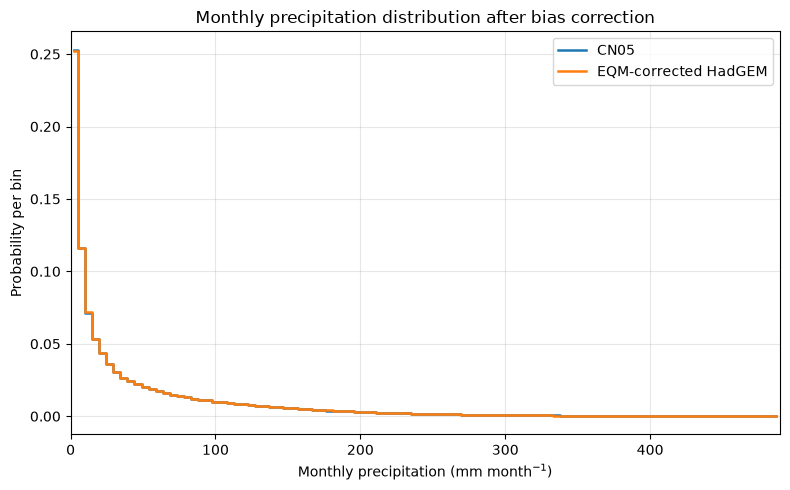

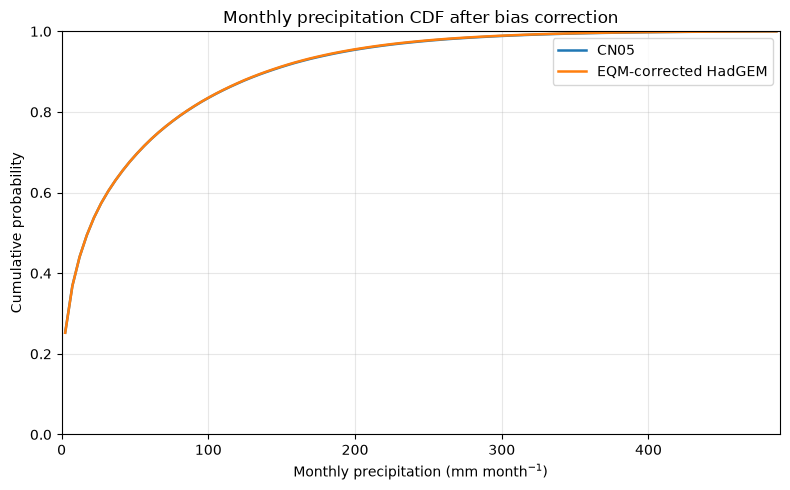

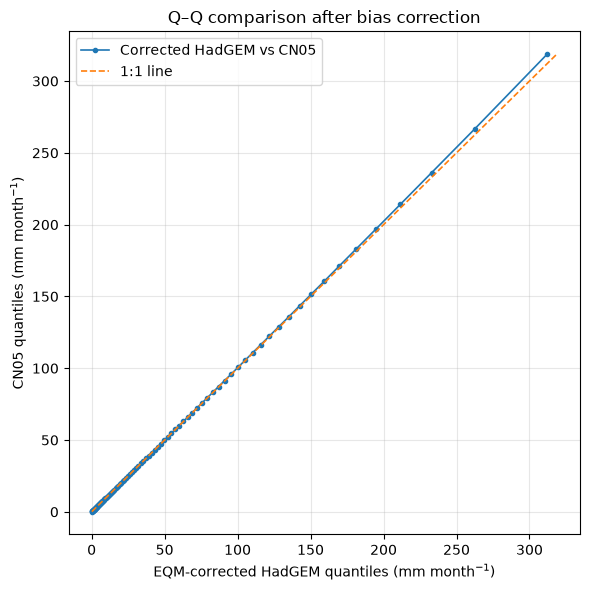


Saved plots:
/home/users/weijia_6/Yangtze_code/gen_result/precip_distribution_after_bias_correction/CN05_vs_HadGEM_after_EQM_PDF.png
/home/users/weijia_6/Yangtze_code/gen_result/precip_distribution_after_bias_correction/CN05_vs_HadGEM_after_EQM_CDF.png
/home/users/weijia_6/Yangtze_code/gen_result/precip_distribution_after_bias_correction/CN05_vs_HadGEM_after_EQM_QQ.png

After-bias-correction comparison completed.


In [20]:
# Distribution comparison after bias correction

# ============================================================
# Compare CN05 and EQM-corrected historical HadGEM distributions
# AFTER bias correction
#
# This script:
#   1. Opens historical HadGEM precipitation.
#   2. Opens the saved monthly empirical quantile mapping.
#   3. Applies EQM month by month and grid cell by grid cell.
#   4. Saves an optional corrected historical NetCDF dataset.
#   5. Produces PDF, CDF, and Q-Q comparison plots.
# ============================================================

import os
import warnings

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt


xr.set_options(use_flox=False)
warnings.filterwarnings("ignore", category=RuntimeWarning)


# ============================================================
# 1. User settings
# ============================================================

OBS_FILE = (
    "/home/users/weijia_6/Yangtze_code/gen_data/HadGEM/"
    "CN05_monthly_precip_1970_2010_on_HadGEM_grid.nc"
)

MODEL_FILE = (
    "/home/users/weijia_6/Yangtze_code/gen_data/HadGEM/"
    "HadGEM_monthly_precip_1970_2010_15ens.nc"
)

MAPPING_FILE = (
    "/home/users/weijia_6/Yangtze_code/gen_data/HadGEM/"
    "HadGEM_CN05_EQM_mapping_1970_2010.nc"
)

CORRECTED_MODEL_FILE = (
    "/home/users/weijia_6/Yangtze_code/gen_data/HadGEM/"
    "HadGEM_monthly_precip_1970_2010_15ens_EQM_corrected.nc"
)

OUTPUT_DIRECTORY = (
    "/home/users/weijia_6/Yangtze_code/gen_result/"
    "precip_distribution_after_bias_correction"
)

os.makedirs(
    OUTPUT_DIRECTORY,
    exist_ok=True,
)

OBS_VAR = "precip"
MODEL_VAR = "precip"

SAVE_CORRECTED_MODEL = True

N_BINS = 100

QUANTILE_PROBABILITIES = np.linspace(
    0.01,
    0.99,
    99,
)

DISPLAY_PERCENTILE = 99.9

MAX_SAMPLES_PER_DATASET = None

RANDOM_SEED = 42


# ============================================================
# 2. Basic helpers
# ============================================================

def assert_file_exists(path):
    if not os.path.isfile(path):
        raise FileNotFoundError(
            f"File not found: {path}"
        )


def standardise_coordinates(ds):
    rename = {}

    if "latitude" in ds.coords or "latitude" in ds.dims:
        rename["latitude"] = "lat"

    if "longitude" in ds.coords or "longitude" in ds.dims:
        rename["longitude"] = "lon"

    if rename:
        ds = ds.rename(rename)

    return ds


def grids_match(first, second, tolerance=1e-8):
    if first.lat.shape != second.lat.shape:
        return False

    if first.lon.shape != second.lon.shape:
        return False

    return (
        np.allclose(
            first.lat.values,
            second.lat.values,
            atol=tolerance,
            rtol=0,
        )
        and
        np.allclose(
            first.lon.values,
            second.lon.values,
            atol=tolerance,
            rtol=0,
        )
    )


def get_valid_values(da):
    values = da.values.reshape(-1)
    values = values[np.isfinite(values)]

    return values.astype(
        np.float32,
        copy=False,
    )


def optionally_subsample(
    values,
    maximum_samples,
    random_generator,
):
    if maximum_samples is None:
        return values

    if values.size <= maximum_samples:
        return values

    indices = random_generator.choice(
        values.size,
        size=maximum_samples,
        replace=False,
    )

    return values[indices]


def create_common_bins(
    observed_values,
    corrected_values,
    number_of_bins,
    upper_percentile,
):
    lower = 0.0

    upper = max(
        np.percentile(
            observed_values,
            upper_percentile,
        ),
        np.percentile(
            corrected_values,
            upper_percentile,
        ),
    )

    if not np.isfinite(upper) or upper <= lower:
        raise ValueError(
            "Could not determine a valid histogram range."
        )

    return np.linspace(
        lower,
        upper,
        number_of_bins + 1,
    )


def histogram_probability(values, bins):
    in_range = values[
        (values >= bins[0])
        & (values <= bins[-1])
    ]

    counts, _ = np.histogram(
        in_range,
        bins=bins,
    )

    if counts.sum() == 0:
        raise ValueError(
            "Histogram contains no samples."
        )

    return (
        counts.astype(np.float64)
        / counts.sum()
    )


def print_summary(label, values):
    print(f"\n{label}")
    print("  Sample count:", f"{values.size:,}")
    print("  Minimum:", float(np.min(values)))
    print("  Mean:", float(np.mean(values)))
    print("  Median:", float(np.median(values)))
    print("  95th percentile:", float(np.percentile(values, 95)))
    print("  99th percentile:", float(np.percentile(values, 99)))
    print("  Maximum:", float(np.max(values)))


# ============================================================
# 3. One-dimensional EQM function
# ============================================================

def remove_duplicate_knots(
    model_quantiles,
    observed_quantiles,
    probabilities,
):
    """
    Remove repeated model quantile values.

    np.interp requires increasing x coordinates. Precipitation
    quantiles can repeat, especially in dry months.
    """
    valid = (
        np.isfinite(model_quantiles)
        & np.isfinite(observed_quantiles)
        & np.isfinite(probabilities)
    )

    model_q = model_quantiles[valid]
    observed_q = observed_quantiles[valid]
    probability_q = probabilities[valid]

    if model_q.size < 2:
        return None, None, None

    # Keep the final occurrence of each repeated model quantile.
    # This associates a repeated dry value with its highest
    # empirical non-exceedance probability.
    reversed_model = model_q[::-1]

    _, reversed_unique_indices = np.unique(
        reversed_model,
        return_index=True,
    )

    keep_indices = (
        model_q.size - 1 - reversed_unique_indices
    )

    keep_indices = np.sort(
        keep_indices
    )

    model_unique = model_q[
        keep_indices
    ]

    probability_unique = probability_q[
        keep_indices
    ]

    # observed_q is evaluated later using the complete
    # probability-to-observation relationship.
    return (
        model_unique,
        probability_unique,
        observed_q,
    )


def eqm_correct_1d(
    raw_values,
    model_quantiles,
    observed_quantiles,
    probabilities,
    valid_mapping,
):
    """
    Apply empirical quantile mapping to one monthly time series
    at one grid cell.

    raw_values has a core dimension such as 'sample'.

    Tail method:
        Constant endpoint extrapolation.
    """
    raw = np.asarray(
        raw_values,
        dtype=np.float64,
    )

    output = np.full(
        raw.shape,
        np.nan,
        dtype=np.float32,
    )

    if not bool(valid_mapping):
        return output

    model_q = np.asarray(
        model_quantiles,
        dtype=np.float64,
    )

    observed_q = np.asarray(
        observed_quantiles,
        dtype=np.float64,
    )

    probability_q = np.asarray(
        probabilities,
        dtype=np.float64,
    )

    valid_knots = (
        np.isfinite(model_q)
        & np.isfinite(observed_q)
        & np.isfinite(probability_q)
    )

    model_q = model_q[valid_knots]
    observed_q = observed_q[valid_knots]
    probability_q = probability_q[valid_knots]

    if model_q.size < 2:
        return output

    (
        model_unique,
        probability_unique,
        _,
    ) = remove_duplicate_knots(
        model_q,
        observed_q,
        probability_q,
    )

    if model_unique is None:
        return output

    if model_unique.size < 2:
        return output

    valid_raw = np.isfinite(raw)

    if not np.any(valid_raw):
        return output

    raw_valid = raw[
        valid_raw
    ]

    # Step 1:
    # Raw model precipitation -> empirical probability.
    probabilities_for_raw = np.interp(
        raw_valid,
        model_unique,
        probability_unique,
        left=probability_unique[0],
        right=probability_unique[-1],
    )

    # Step 2:
    # Empirical probability -> observed precipitation.
    corrected_valid = np.interp(
        probabilities_for_raw,
        probability_q,
        observed_q,
        left=observed_q[0],
        right=observed_q[-1],
    )

    corrected_valid = np.maximum(
        corrected_valid,
        0.0,
    )

    output[
        valid_raw
    ] = corrected_valid.astype(
        np.float32
    )

    return output


# ============================================================
# 4. Apply mapping month by month
# ============================================================

def apply_mapping_to_historical_model(
    model,
    mapping,
):
    """
    Apply the saved monthly EQM mapping to all historical
    ensemble members.

    Processing is performed one calendar month at a time.
    """
    corrected_months = []

    quantile_probabilities = (
        mapping["quantile"]
        .values
        .astype(np.float64)
    )

    for month_number in range(1, 13):
        print(
            f"Applying EQM for month {month_number:02d}..."
        )

        time_indices = np.flatnonzero(
            model.time.dt.month.values
            == month_number
        )

        raw_month = model.isel(
            time=time_indices
        )

        # Stack ensemble and time into a single sample dimension.
        raw_stacked = (
            raw_month
            .stack(
                sample=("number", "time")
            )
            .transpose(
                "sample",
                "lat",
                "lon",
            )
        )

        month_mapping = mapping.sel(
            month=month_number
        )

        corrected_stacked = xr.apply_ufunc(
            eqm_correct_1d,
            raw_stacked,
            month_mapping["model_quantile"],
            month_mapping["observed_quantile"],
            mapping["quantile"],
            month_mapping["valid_mapping"],
            input_core_dims=[
                ["sample"],
                ["quantile"],
                ["quantile"],
                ["quantile"],
                [],
            ],
            output_core_dims=[
                ["sample"],
            ],
            vectorize=True,
            dask="forbidden",
            output_dtypes=[
                np.float32,
            ],
        )

        corrected_stacked = corrected_stacked.transpose(
            "sample",
            "lat",
            "lon",
        )

        corrected_month = (
            corrected_stacked
            .unstack("sample")
            .transpose(
                "number",
                "time",
                "lat",
                "lon",
            )
        )

        corrected_month = corrected_month.assign_coords(
            time=raw_month.time,
            number=raw_month.number,
        )

        corrected_months.append(
            corrected_month.load()
        )

    corrected = xr.concat(
        corrected_months,
        dim="time",
        coords="minimal",
        compat="override",
        join="exact",
    )

    corrected = corrected.sortby(
        "time"
    )

    corrected = corrected.transpose(
        "number",
        "time",
        "lat",
        "lon",
    )

    corrected.name = "precip"

    corrected.attrs = {
        "long_name": (
            "Empirical-quantile-mapped HadGEM3-A-N216 "
            "monthly accumulated precipitation"
        ),
        "units": "mm month-1",
        "bias_correction_method": (
            "Monthly empirical quantile mapping"
        ),
        "calibration_period": "1970-2010",
        "mapping_file": os.path.basename(
            MAPPING_FILE
        ),
        "tail_method": (
            "Constant endpoint extrapolation"
        ),
    }

    return corrected


# ============================================================
# 5. Save corrected model
# ============================================================

def save_corrected_model(
    corrected,
    source_model_ds,
):
    output = corrected.to_dataset(
        name="precip"
    )

    for coordinate in [
        "year",
        "month",
        "month_id",
    ]:
        if coordinate in source_model_ds.coords:
            output = output.assign_coords(
                {
                    coordinate:
                    source_model_ds[coordinate]
                }
            )

    output.attrs = {
        "title": (
            "Bias-corrected historical HadGEM3-A-N216 "
            "monthly precipitation, 15 ensembles, 1970-2010"
        ),
        "method": (
            "Monthly empirical quantile mapping against CN05.1"
        ),
        "mapping_file": os.path.basename(
            MAPPING_FILE
        ),
        "calendar": "360_day",
        "units": "mm month-1",
        "tail_method": (
            "Values below and above historical model mapping "
            "knots use the corresponding observed endpoint"
        ),
    }

    os.makedirs(
        os.path.dirname(
            CORRECTED_MODEL_FILE
        ),
        exist_ok=True,
    )

    output.time.encoding = {}

    encoding = {
        "precip": {
            "dtype": "float32",
            "zlib": True,
            "complevel": 4,
            "_FillValue": np.float32(-9999.0),
            "chunksizes": (
                1,
                12,
                min(45, output.sizes["lat"]),
                min(48, output.sizes["lon"]),
            ),
        },
        "number": {
            "dtype": "int16",
        },
    }

    if "year" in output.coords:
        encoding["year"] = {
            "dtype": "int32",
        }

    if "month" in output.coords:
        encoding["month"] = {
            "dtype": "int8",
        }

    if "month_id" in output.coords:
        encoding["month_id"] = {
            "dtype": "int32",
        }

    print(
        "\nSaving bias-corrected historical HadGEM dataset..."
    )

    output.to_netcdf(
        CORRECTED_MODEL_FILE,
        encoding=encoding,
    )

    print(
        "Saved:",
        CORRECTED_MODEL_FILE,
    )


# ============================================================
# 6. Open source files
# ============================================================

for required_file in [
    OBS_FILE,
    MODEL_FILE,
    MAPPING_FILE,
]:
    assert_file_exists(
        required_file
    )

print("Opening CN05 on HadGEM grid...")

obs_ds = xr.open_dataset(
    OBS_FILE,
    decode_cf=True,
    mask_and_scale=True,
)

obs_ds = standardise_coordinates(
    obs_ds
)

print("Opening raw historical HadGEM...")

model_ds = xr.open_dataset(
    MODEL_FILE,
    decode_cf=True,
    mask_and_scale=True,
)

model_ds = standardise_coordinates(
    model_ds
)

print("Opening saved EQM mapping...")

mapping_ds = xr.open_dataset(
    MAPPING_FILE,
    decode_cf=True,
    mask_and_scale=True,
)

mapping_ds = standardise_coordinates(
    mapping_ds
)

obs = obs_ds[OBS_VAR].transpose(
    "time",
    "lat",
    "lon",
)

model = model_ds[MODEL_VAR].transpose(
    "number",
    "time",
    "lat",
    "lon",
)

if not grids_match(
    obs,
    model,
):
    raise ValueError(
        "Observed and model grids do not match."
    )

if not grids_match(
    mapping_ds,
    model,
):
    raise ValueError(
        "Mapping and model grids do not match."
    )


# ============================================================
# 7. Apply EQM
# ============================================================

corrected_model = apply_mapping_to_historical_model(
    model,
    mapping_ds,
)

print(
    "\nCorrected dimensions:",
    dict(corrected_model.sizes),
)

print(
    "Corrected valid fraction:",
    float(
        corrected_model.notnull().mean()
    ),
)

print(
    "Corrected precipitation range:",
    float(
        corrected_model.min(
            skipna=True
        )
    ),
    "to",
    float(
        corrected_model.max(
            skipna=True
        )
    ),
    "mm/month",
)

if SAVE_CORRECTED_MODEL:
    save_corrected_model(
        corrected_model,
        model_ds,
    )


# ============================================================
# 8. Flatten distributions
# ============================================================

valid_mapping_all_months = (
    mapping_ds["valid_mapping"] == 1
).all(
    dim="month"
)

obs_masked = obs.where(
    valid_mapping_all_months
)

corrected_masked = corrected_model.where(
    valid_mapping_all_months
)

print("Loading and flattening CN05 values...")
obs_values = get_valid_values(
    obs_masked
)

print("Loading and flattening corrected HadGEM values...")
corrected_values = get_valid_values(
    corrected_masked
)

random_generator = np.random.default_rng(
    RANDOM_SEED
)

obs_values = optionally_subsample(
    obs_values,
    MAX_SAMPLES_PER_DATASET,
    random_generator,
)

corrected_values = optionally_subsample(
    corrected_values,
    MAX_SAMPLES_PER_DATASET,
    random_generator,
)

print_summary(
    "CN05 observations",
    obs_values,
)

print_summary(
    "EQM-corrected historical HadGEM",
    corrected_values,
)


# ============================================================
# 9. Histograms and quantiles
# ============================================================

bins = create_common_bins(
    observed_values=obs_values,
    corrected_values=corrected_values,
    number_of_bins=N_BINS,
    upper_percentile=DISPLAY_PERCENTILE,
)

bin_centres = (
    bins[:-1] + bins[1:]
) / 2.0

obs_pdf = histogram_probability(
    obs_values,
    bins,
)

corrected_pdf = histogram_probability(
    corrected_values,
    bins,
)

obs_cdf = np.cumsum(
    obs_pdf
)

corrected_cdf = np.cumsum(
    corrected_pdf
)

obs_quantiles = np.quantile(
    obs_values,
    QUANTILE_PROBABILITIES,
)

corrected_quantiles = np.quantile(
    corrected_values,
    QUANTILE_PROBABILITIES,
)


# ============================================================
# 10. PDF plot
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    bin_centres,
    obs_pdf,
    drawstyle="steps-mid",
    label="CN05",
    linewidth=1.8,
)

plt.plot(
    bin_centres,
    corrected_pdf,
    drawstyle="steps-mid",
    label="EQM-corrected HadGEM",
    linewidth=1.8,
)

plt.xlabel(
    "Monthly precipitation (mm month$^{-1}$)"
)

plt.ylabel(
    "Probability per bin"
)

plt.title(
    "Monthly precipitation distribution after bias correction"
)

plt.xlim(
    bins[0],
    bins[-1],
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

pdf_path = os.path.join(
    OUTPUT_DIRECTORY,
    "CN05_vs_HadGEM_after_EQM_PDF.png",
)

plt.savefig(
    pdf_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()


# ============================================================
# 11. CDF plot
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    bin_centres,
    obs_cdf,
    label="CN05",
    linewidth=1.8,
)

plt.plot(
    bin_centres,
    corrected_cdf,
    label="EQM-corrected HadGEM",
    linewidth=1.8,
)

plt.xlabel(
    "Monthly precipitation (mm month$^{-1}$)"
)

plt.ylabel(
    "Cumulative probability"
)

plt.title(
    "Monthly precipitation CDF after bias correction"
)

plt.xlim(
    bins[0],
    bins[-1],
)

plt.ylim(
    0,
    1,
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

cdf_path = os.path.join(
    OUTPUT_DIRECTORY,
    "CN05_vs_HadGEM_after_EQM_CDF.png",
)

plt.savefig(
    cdf_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()


# ============================================================
# 12. Q-Q plot
# ============================================================

qq_minimum = min(
    float(obs_quantiles.min()),
    float(corrected_quantiles.min()),
)

qq_maximum = max(
    float(obs_quantiles.max()),
    float(corrected_quantiles.max()),
)

plt.figure(
    figsize=(6, 6)
)

plt.plot(
    corrected_quantiles,
    obs_quantiles,
    marker="o",
    markersize=3,
    linewidth=1.2,
    label="Corrected HadGEM vs CN05",
)

plt.plot(
    [qq_minimum, qq_maximum],
    [qq_minimum, qq_maximum],
    linestyle="--",
    linewidth=1.2,
    label="1:1 line",
)

plt.xlabel(
    "EQM-corrected HadGEM quantiles "
    "(mm month$^{-1}$)"
)

plt.ylabel(
    "CN05 quantiles (mm month$^{-1}$)"
)

plt.title(
    "Q–Q comparison after bias correction"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

qq_path = os.path.join(
    OUTPUT_DIRECTORY,
    "CN05_vs_HadGEM_after_EQM_QQ.png",
)

plt.savefig(
    qq_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()


# ============================================================
# 13. Finish
# ============================================================

obs_ds.close()
model_ds.close()
mapping_ds.close()

print("\nSaved plots:")
print(pdf_path)
print(cdf_path)
print(qq_path)

print("\nAfter-bias-correction comparison completed.")

## Step 4 Apply the mapping to HadGEM 2022 factual and counterfcatual data

In [21]:
# ============================================================
# Step 4:
# Build January-September 2022 monthly precipitation for
# 525 factual and 525 counterfactual HadGEM members, place
# them on the historical HadGEM mapping grid, and apply the
# saved empirical quantile mapping.
# ============================================================

import os
import re
import warnings
from glob import glob

import cftime
import numpy as np
import xarray as xr


# Avoid the flox/sparse/numba incompatibility.
xr.set_options(use_flox=False)

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
)


# ============================================================
# 1. User settings
# ============================================================

FACTUAL_BASE = (
    "/gws/ssde/j25a/cssp_china/wp1/"
    "HadGEM3-A-N216/historicalExt/pr/day"
)

COUNTERFACTUAL_BASE = (
    "/gws/ssde/j25a/cssp_china/wp1/"
    "HadGEM3-A-N216/historicalNatExt/pr/day"
)

MAPPING_FILE = (
    "/home/users/weijia_6/Yangtze_code/gen_data/HadGEM/"
    "HadGEM_CN05_EQM_mapping_1970_2010.nc"
)

HISTORICAL_GRID_FILE = (
    "/home/users/weijia_6/Yangtze_code/gen_data/HadGEM/"
    "HadGEM_monthly_precip_1970_2010_15ens.nc"
)

OUTPUT_DIRECTORY = (
    "/home/users/weijia_6/Yangtze_code/gen_data/HadGEM/2022"
)

os.makedirs(
    OUTPUT_DIRECTORY,
    exist_ok=True,
)


# Raw monthly precipitation on the 90 x 96 mapping grid.
OUT_FACTUAL_MONTHLY = os.path.join(
    OUTPUT_DIRECTORY,
    "HadGEM_2022_JanSep_monthly_factual_525ens_90x96.nc",
)

OUT_COUNTERFACTUAL_MONTHLY = os.path.join(
    OUTPUT_DIRECTORY,
    "HadGEM_2022_JanSep_monthly_counterfactual_525ens_90x96.nc",
)


# EQM-corrected monthly precipitation.
OUT_FACTUAL_CORRECTED = os.path.join(
    OUTPUT_DIRECTORY,
    "HadGEM_2022_JanSep_monthly_factual_525ens_EQM.nc",
)

OUT_COUNTERFACTUAL_CORRECTED = os.path.join(
    OUTPUT_DIRECTORY,
    "HadGEM_2022_JanSep_monthly_counterfactual_525ens_EQM.nc",
)


PR_VAR = "pr"

YEAR = 2022
MONTHS = np.arange(
    1,
    10,
    dtype=np.int8,
)

YEAR_MONTHS = [
    f"{YEAR}{month:02d}"
    for month in MONTHS
]

R_VALUES = range(1, 106)
P_VALUES = range(1, 6)

EXPECTED_ENSEMBLES = 525
EXPECTED_MONTHS = 9
EXPECTED_DAYS_PER_MONTH = 30

SECONDS_PER_DAY = np.float32(
    86400.0
)

GRID_TOLERANCE = 1e-5

# Endpoint extrapolation:
# values below/above the historical model range map to the
# corresponding minimum/maximum observed quantile.
TAIL_METHOD = "constant_endpoint"


# ============================================================
# 2. General helpers
# ============================================================

def assert_file_exists(path):
    """Check that a required file exists."""
    if not os.path.isfile(path):
        raise FileNotFoundError(
            f"File not found: {path}"
        )


def assert_directory_exists(path):
    """Check that a source directory exists."""
    if not os.path.isdir(path):
        raise FileNotFoundError(
            f"Directory not found: {path}"
        )


def standardise_coordinate_names(ds):
    """
    Rename latitude and longitude coordinates to lat and lon.
    """
    rename = {}

    if "latitude" in ds.coords or "latitude" in ds.dims:
        rename["latitude"] = "lat"

    if "longitude" in ds.coords or "longitude" in ds.dims:
        rename["longitude"] = "lon"

    if rename:
        ds = ds.rename(rename)

    required = {"time", "lat", "lon"}
    missing = required.difference(
        ds.coords
    )

    if missing:
        raise ValueError(
            f"Missing coordinates: {sorted(missing)}. "
            f"Available coordinates: {list(ds.coords)}"
        )

    return ds


def convert_longitude_to_minus180_180(ds):
    """
    Convert 0-360 longitude coordinates to -180-180 if needed.
    """
    lon_min = float(
        ds.lon.min()
    )

    lon_max = float(
        ds.lon.max()
    )

    if lon_min >= 0 and lon_max > 180:
        new_lon = (
            (ds.lon + 180) % 360
        ) - 180

        ds = (
            ds.assign_coords(
                lon=new_lon
            )
            .sortby("lon")
        )

    return ds


def ensure_latitude_ascending(ds):
    """Ensure latitude runs from south to north."""
    if (
        ds.lat.size > 1
        and float(ds.lat.values[0])
        > float(ds.lat.values[-1])
    ):
        ds = ds.sortby("lat")

    return ds


def normalise_units(value):
    """Normalise unit strings for comparison."""
    return (
        str(value)
        .strip()
        .lower()
        .replace(" ", "")
        .replace("**", "^")
    )


def verify_precipitation_units(da, filename):
    """
    Require precipitation flux units equivalent to kg m-2 s-1.
    """
    units = da.attrs.get(
        "units",
        "",
    )

    normalised = normalise_units(
        units
    )

    accepted = {
        "kgm-2s-1",
        "kgm^-2s^-1",
        "kg/m2/s",
        "kgm-2sec-1",
    }

    if normalised not in accepted:
        raise ValueError(
            f"Unexpected precipitation units in:\n"
            f"{filename}\n"
            f"Found: '{units}'\n"
            "Expected units equivalent to kg m-2 s-1."
        )


def get_calendar_name(time):
    """Return the decoded calendar name."""
    calendar = getattr(
        time.dt,
        "calendar",
        None,
    )

    if calendar is not None:
        try:
            calendar = calendar.item()
        except AttributeError:
            pass

    if calendar is None:
        calendar = time.encoding.get(
            "calendar",
            time.attrs.get(
                "calendar",
                "unknown",
            ),
        )

    return str(calendar)


def verify_360_day_calendar(time, filename):
    """Require the HadGEM 360-day calendar."""
    calendar = get_calendar_name(
        time
    )

    if calendar.lower() not in {
        "360_day",
        "360",
    }:
        raise ValueError(
            f"Unexpected calendar in:\n"
            f"{filename}\n"
            f"Detected calendar: {calendar}\n"
            "Expected calendar: 360_day"
        )


def grids_match(first, second, tolerance=1e-8):
    """Check whether two fields have the same grid."""
    if first.lat.shape != second.lat.shape:
        return False

    if first.lon.shape != second.lon.shape:
        return False

    return (
        np.allclose(
            first.lat.values,
            second.lat.values,
            atol=tolerance,
            rtol=0,
        )
        and
        np.allclose(
            first.lon.values,
            second.lon.values,
            atol=tolerance,
            rtol=0,
        )
    )


def ensemble_number(r_value, p_value):
    """
    Convert r001-r105 and p1-p5 into sequential ensemble
    numbers 1-525.
    """
    return (
        (r_value - 1) * 5
        + p_value
    )


# ============================================================
# 3. Build a file index
# ============================================================

def build_file_index(base_directory):
    """
    Search a source directory once and index files by:

        (r, p, YYYYMM)

    This is much faster than running a recursive glob separately
    for every one of the 4,725 member-month combinations.
    """
    assert_directory_exists(
        base_directory
    )

    print(
        "\nIndexing NetCDF files under:"
    )
    print(
        base_directory
    )

    all_files = sorted(
        glob(
            os.path.join(
                base_directory,
                "**",
                "*.nc",
            ),
            recursive=True,
        )
    )

    if not all_files:
        raise RuntimeError(
            f"No NetCDF files found under:\n"
            f"{base_directory}"
        )

    file_index = {}
    duplicate_keys = {}

    # Flexible matching for names containing, for example:
    # r001i1p1 ... 202201
    pattern = re.compile(
        r"r(\d{1,3})i1p(\d+).*?(20220[1-9])",
        flags=re.IGNORECASE,
    )

    for path in all_files:
        filename = os.path.basename(
            path
        )

        match = pattern.search(
            filename
        )

        if match is None:
            continue

        r_value = int(
            match.group(1)
        )

        p_value = int(
            match.group(2)
        )

        year_month = match.group(3)

        if (
            r_value not in R_VALUES
            or p_value not in P_VALUES
            or year_month not in YEAR_MONTHS
        ):
            continue

        key = (
            r_value,
            p_value,
            year_month,
        )

        if key in file_index:
            duplicate_keys.setdefault(
                key,
                [file_index[key]],
            ).append(
                path
            )
        else:
            file_index[key] = path

    if duplicate_keys:
        lines = []

        for key, paths in list(
            duplicate_keys.items()
        )[:10]:
            lines.append(
                f"{key}: {paths}"
            )

        raise RuntimeError(
            "Multiple files matched one or more "
            "member-month combinations.\n"
            + "\n".join(lines)
        )

    print(
        "Indexed member-month files:",
        len(file_index),
    )

    return file_index


def audit_file_index(
    file_index,
    experiment_name,
):
    """
    Confirm that every expected member has all nine months.
    """
    missing = []

    for r_value in R_VALUES:
        for p_value in P_VALUES:
            for year_month in YEAR_MONTHS:
                key = (
                    r_value,
                    p_value,
                    year_month,
                )

                if key not in file_index:
                    missing.append(
                        key
                    )

    expected_files = (
        EXPECTED_ENSEMBLES
        * EXPECTED_MONTHS
    )

    print(
        f"\n{experiment_name} expected files:",
        expected_files,
    )

    print(
        f"{experiment_name} indexed files:",
        len(file_index),
    )

    if missing:
        print(
            f"{experiment_name} missing combinations:",
            len(missing),
        )

        print(
            "First missing combinations:",
            missing[:20],
        )

        raise RuntimeError(
            f"{experiment_name} does not contain all "
            f"{EXPECTED_ENSEMBLES} members for "
            "January-September 2022."
        )

    print(
        f"{experiment_name} file audit passed."
    )


# ============================================================
# 4. Load target grid and mapping
# ============================================================

def load_target_grid_and_mapping():
    """
    Load the exact historical HadGEM target grid and EQM mapping.
    """
    assert_file_exists(
        HISTORICAL_GRID_FILE
    )

    assert_file_exists(
        MAPPING_FILE
    )

    with xr.open_dataset(
        HISTORICAL_GRID_FILE,
        decode_cf=True,
        mask_and_scale=True,
    ) as historical_ds:

        historical_ds = standardise_coordinate_names(
            historical_ds
        )

        historical_ds = convert_longitude_to_minus180_180(
            historical_ds
        )

        historical_ds = ensure_latitude_ascending(
            historical_ds
        )

        target_lat = historical_ds.lat.load()
        target_lon = historical_ds.lon.load()

    mapping_ds = xr.open_dataset(
        MAPPING_FILE,
        decode_cf=True,
        mask_and_scale=True,
    )

    mapping_ds = convert_longitude_to_minus180_180(
        mapping_ds
    )

    mapping_ds = ensure_latitude_ascending(
        mapping_ds
    )

    required_mapping_variables = {
        "model_quantile",
        "observed_quantile",
        "valid_mapping",
    }

    missing_variables = (
        required_mapping_variables
        .difference(
            mapping_ds.data_vars
        )
    )

    if missing_variables:
        mapping_ds.close()

        raise KeyError(
            "Mapping file is missing variables: "
            f"{sorted(missing_variables)}"
        )

    if "quantile" not in mapping_ds.coords:
        mapping_ds.close()

        raise KeyError(
            "The mapping file has no 'quantile' coordinate."
        )

    if not np.array_equal(
        mapping_ds.month.values,
        np.arange(1, 13),
    ):
        mapping_ds.close()

        raise ValueError(
            "Mapping month coordinate is not 1-12."
        )

    target_grid = xr.Dataset(
        coords={
            "lat": target_lat,
            "lon": target_lon,
        }
    )

    if not grids_match(
        mapping_ds,
        target_grid,
    ):
        mapping_ds.close()

        raise ValueError(
            "Historical target grid and mapping grid differ."
        )

    print(
        "\nTarget grid:",
        target_lat.size,
        "x",
        target_lon.size,
    )

    print(
        "Valid mapping cells by month:",
        mapping_ds["valid_mapping"]
        .sum(
            dim=("lat", "lon")
        )
        .values,
    )

    return (
        target_grid,
        mapping_ds,
    )


# ============================================================
# 5. Native-grid selection/regridding
# ============================================================

def coordinate_subset_matches(
    source_coordinate,
    target_coordinate,
    tolerance,
):
    """
    Determine whether every target coordinate is present in the
    source coordinate to within a tolerance.
    """
    source_values = np.asarray(
        source_coordinate.values,
        dtype=np.float64,
    )

    target_values = np.asarray(
        target_coordinate.values,
        dtype=np.float64,
    )

    minimum_distances = np.array(
        [
            np.min(
                np.abs(
                    source_values - target
                )
            )
            for target in target_values
        ]
    )

    return bool(
        np.all(
            minimum_distances <= tolerance
        )
    )


def place_on_target_grid(
    monthly_native,
    target_grid,
):
    """
    Put a monthly field on the exact historical 90 x 96 grid.

    Since historicalExt and historical CHINAcut use the same
    atmospheric model grid, the target coordinates should
    normally be an exact spatial subset. Linear interpolation is
    used only as a fallback.
    """
    exact_lat_subset = coordinate_subset_matches(
        monthly_native.lat,
        target_grid.lat,
        GRID_TOLERANCE,
    )

    exact_lon_subset = coordinate_subset_matches(
        monthly_native.lon,
        target_grid.lon,
        GRID_TOLERANCE,
    )

    if exact_lat_subset and exact_lon_subset:
        monthly_target = monthly_native.sel(
            lat=target_grid.lat,
            lon=target_grid.lon,
            method="nearest",
            tolerance=GRID_TOLERANCE,
        )

        grid_method = "nearest_exact_subset"

    else:
        monthly_target = monthly_native.interp(
            lat=target_grid.lat,
            lon=target_grid.lon,
            method="linear",
        )

        grid_method = "linear_interpolation"

    # Force coordinates to match the mapping grid exactly.
    monthly_target = monthly_target.assign_coords(
        lat=target_grid.lat,
        lon=target_grid.lon,
    )

    monthly_target = monthly_target.transpose(
        "lat",
        "lon",
    )

    return (
        monthly_target.astype(
            np.float32
        ),
        grid_method,
    )


# ============================================================
# 6. Convert one daily file to one monthly field
# ============================================================

def process_one_member_month(
    filename,
    expected_year,
    expected_month,
    target_grid,
):
    """
    Read one member-month daily precipitation file, verify its
    dates and units, convert to monthly accumulated precipitation,
    and place it on the historical mapping grid.
    """
    assert_file_exists(
        filename
    )

    with xr.open_dataset(
        filename,
        decode_cf=True,
        mask_and_scale=True,
    ) as ds:

        ds = standardise_coordinate_names(
            ds
        )

        ds = convert_longitude_to_minus180_180(
            ds
        )

        ds = ensure_latitude_ascending(
            ds
        )

        if PR_VAR not in ds.data_vars:
            raise KeyError(
                f"Variable '{PR_VAR}' not found in:\n"
                f"{filename}\n"
                f"Available variables: {list(ds.data_vars)}"
            )

        daily = ds[PR_VAR].transpose(
            "time",
            "lat",
            "lon",
        )

        verify_precipitation_units(
            daily,
            filename,
        )

        verify_360_day_calendar(
            daily.time,
            filename,
        )

        if daily.sizes["time"] != EXPECTED_DAYS_PER_MONTH:
            raise ValueError(
                f"Expected {EXPECTED_DAYS_PER_MONTH} days in:\n"
                f"{filename}\n"
                f"Found {daily.sizes['time']} records."
            )

        years = daily.time.dt.year.values
        months = daily.time.dt.month.values
        days = daily.time.dt.day.values

        if not np.all(
            years == expected_year
        ):
            raise ValueError(
                f"Unexpected year values in:\n"
                f"{filename}\n"
                f"Found years: {np.unique(years)}"
            )

        if not np.all(
            months == expected_month
        ):
            raise ValueError(
                f"Unexpected month values in:\n"
                f"{filename}\n"
                f"Found months: {np.unique(months)}"
            )

        expected_days = np.arange(
            1,
            31,
            dtype=days.dtype,
        )

        if not np.array_equal(
            np.sort(
                np.unique(days)
            ),
            expected_days,
        ):
            raise ValueError(
                f"Daily sequence is incomplete in:\n"
                f"{filename}\n"
                f"Found days: {np.unique(days)}"
            )

        if len(
            np.unique(
                daily.time.values
            )
        ) != EXPECTED_DAYS_PER_MONTH:
            raise ValueError(
                f"Duplicate daily timestamps found in:\n"
                f"{filename}"
            )

        # kg m-2 s-1 = mm s-1.
        # Multiply each daily mean flux by 86400 seconds/day,
        # then sum all 30 model days.
        daily_mm = (
            daily * SECONDS_PER_DAY
        ).astype(
            np.float32
        )

        monthly_native = daily_mm.sum(
            dim="time",
            skipna=True,
            min_count=EXPECTED_DAYS_PER_MONTH,
        )

        monthly_native = monthly_native.load()

    (
        monthly_target,
        grid_method,
    ) = place_on_target_grid(
        monthly_native,
        target_grid,
    )

    monthly_target.name = "precip"

    monthly_target.attrs = {
        "long_name": (
            "HadGEM3-A-N216 monthly accumulated precipitation"
        ),
        "units": "mm month-1",
        "source_frequency": "daily",
        "source_units": "kg m-2 s-1",
        "calendar": "360_day",
        "grid_method": grid_method,
        "conversion": (
            "Daily precipitation flux multiplied by 86400 "
            "seconds per day and summed over 30 model days."
        ),
    }

    return (
        monthly_target,
        grid_method,
    )


# ============================================================
# 7. Build all 525 monthly members for one experiment
# ============================================================

def build_monthly_experiment(
    file_index,
    experiment_name,
    target_grid,
):
    """
    Build a monthly precipitation DataArray with dimensions:

        number, time, lat, lon

    for all 525 members and January-September 2022.
    """
    member_arrays = []
    r_coordinates = []
    p_coordinates = []

    grid_methods_used = set()

    print(
        "\n=================================================="
    )
    print(
        f"Building {experiment_name} monthly dataset"
    )
    print(
        "=================================================="
    )

    for r_value in R_VALUES:
        for p_value in P_VALUES:
            number_value = ensemble_number(
                r_value,
                p_value,
            )

            monthly_fields = []

            for month_value in MONTHS:
                year_month = (
                    f"{YEAR}{month_value:02d}"
                )

                filename = file_index[
                    (
                        r_value,
                        p_value,
                        year_month,
                    )
                ]

                (
                    monthly_field,
                    grid_method,
                ) = process_one_member_month(
                    filename=filename,
                    expected_year=YEAR,
                    expected_month=int(
                        month_value
                    ),
                    target_grid=target_grid,
                )

                grid_methods_used.add(
                    grid_method
                )

                model_time = cftime.Datetime360Day(
                    YEAR,
                    int(month_value),
                    1,
                    0,
                    0,
                    0,
                )

                monthly_field = monthly_field.expand_dims(
                    time=[model_time]
                )

                monthly_fields.append(
                    monthly_field
                )

            member_monthly = xr.concat(
                monthly_fields,
                dim="time",
                coords="minimal",
                compat="override",
                join="exact",
                combine_attrs="override",
            )

            member_monthly = member_monthly.expand_dims(
                number=[number_value]
            )

            member_arrays.append(
                member_monthly
            )

            r_coordinates.append(
                r_value
            )

            p_coordinates.append(
                p_value
            )

            if (
                number_value == 1
                or number_value % 25 == 0
                or number_value == EXPECTED_ENSEMBLES
            ):
                print(
                    f"{experiment_name}: completed "
                    f"{number_value}/{EXPECTED_ENSEMBLES} members"
                )

    combined = xr.concat(
        member_arrays,
        dim="number",
        coords="minimal",
        compat="override",
        join="exact",
        combine_attrs="override",
    )

    combined = combined.sortby(
        "number"
    )

    combined = combined.transpose(
        "number",
        "time",
        "lat",
        "lon",
    )

    combined = combined.assign_coords(
        r=(
            "number",
            np.asarray(
                r_coordinates,
                dtype=np.int16,
            ),
        ),
        p=(
            "number",
            np.asarray(
                p_coordinates,
                dtype=np.int8,
            ),
        ),
        year=(
            "time",
            np.full(
                EXPECTED_MONTHS,
                YEAR,
                dtype=np.int16,
            ),
        ),
        month=(
            "time",
            MONTHS.astype(
                np.int8
            ),
        ),
        month_id=(
            "time",
            np.asarray(
                [
                    YEAR * 100
                    + int(month_value)
                    for month_value in MONTHS
                ],
                dtype=np.int32,
            ),
        ),
    )

    combined.name = "precip"

    combined.attrs = {
        "long_name": (
            "HadGEM3-A-N216 monthly accumulated precipitation"
        ),
        "units": "mm month-1",
        "experiment": experiment_name,
        "calendar": "360_day",
        "source_frequency": "daily",
        "grid_methods_used": ", ".join(
            sorted(
                grid_methods_used
            )
        ),
    }

    validate_monthly_experiment(
        combined,
        experiment_name,
    )

    return combined


# ============================================================
# 8. Validate monthly experiment
# ============================================================

def validate_monthly_experiment(
    monthly,
    experiment_name,
):
    """Check the combined 525-member monthly dataset."""
    expected_sizes = {
        "number": EXPECTED_ENSEMBLES,
        "time": EXPECTED_MONTHS,
        "lat": 90,
        "lon": 96,
    }

    for dimension, expected_size in expected_sizes.items():
        actual_size = monthly.sizes.get(
            dimension
        )

        if actual_size != expected_size:
            raise ValueError(
                f"{experiment_name}: expected "
                f"{dimension}={expected_size}, "
                f"found {actual_size}."
            )

    expected_numbers = np.arange(
        1,
        EXPECTED_ENSEMBLES + 1,
        dtype=monthly.number.dtype,
    )

    if not np.array_equal(
        monthly.number.values,
        expected_numbers,
    ):
        raise ValueError(
            f"{experiment_name}: ensemble numbers are "
            "incomplete or incorrectly ordered."
        )

    expected_month_ids = np.asarray(
        [
            202201,
            202202,
            202203,
            202204,
            202205,
            202206,
            202207,
            202208,
            202209,
        ],
        dtype=np.int32,
    )

    if not np.array_equal(
        monthly.month_id.values,
        expected_month_ids,
    ):
        raise ValueError(
            f"{experiment_name}: month_id coordinate is incorrect."
        )

    negative_count = int(
        (monthly < 0)
        .sum(skipna=True)
        .item()
    )

    if negative_count > 0:
        raise ValueError(
            f"{experiment_name}: found "
            f"{negative_count} negative values."
        )

    all_missing_member_month = (
        monthly.isnull()
        .all(
            dim=("lat", "lon")
        )
    )

    bad_indices = np.argwhere(
        all_missing_member_month.values
    )

    if bad_indices.size > 0:
        raise ValueError(
            f"{experiment_name}: one or more complete "
            "member-month fields are missing.\n"
            f"Indices: {bad_indices[:20]}"
        )

    print(
        f"\n{experiment_name} monthly checks:"
    )

    print(
        "  Dimensions:",
        dict(monthly.sizes),
    )

    print(
        "  Time range:",
        monthly.time.values[0],
        "to",
        monthly.time.values[-1],
    )

    print(
        "  month_id range:",
        int(monthly.month_id.values[0]),
        "to",
        int(monthly.month_id.values[-1]),
    )

    print(
        "  Minimum:",
        float(
            monthly.min(
                skipna=True
            ).item()
        ),
        "mm/month",
    )

    print(
        "  Mean:",
        float(
            monthly.mean(
                skipna=True
            ).item()
        ),
        "mm/month",
    )

    print(
        "  Maximum:",
        float(
            monthly.max(
                skipna=True
            ).item()
        ),
        "mm/month",
    )

    print(
        "  Missing count:",
        int(
            monthly.isnull()
            .sum()
            .item()
        ),
    )


# ============================================================
# 9. Save raw monthly experiment
# ============================================================

def save_monthly_experiment(
    monthly,
    output_file,
    experiment_name,
):
    """Save one raw 525-member monthly dataset."""
    output = monthly.to_dataset(
        name="precip"
    )

    output.attrs = {
        "title": (
            f"HadGEM3-A-N216 {experiment_name} monthly "
            "accumulated precipitation, January-September 2022"
        ),
        "experiment": experiment_name,
        "ensemble_members": (
            "525 members: r001-r105 combined with p1-p5"
        ),
        "temporal_coverage": "2022-01 to 2022-09",
        "calendar": "360_day",
        "source_frequency": "daily",
        "source_units": "kg m-2 s-1",
        "output_units": "mm month-1",
        "target_grid": (
            "Historical HadGEM3-A-N216 CHINAcut 90 x 96 grid"
        ),
        "processing": (
            "Daily precipitation flux was multiplied by 86400 "
            "seconds per day and summed over each 30-day model "
            "month. Monthly fields were then placed on the exact "
            "historical quantile-mapping grid."
        ),
    }

    output.time.encoding = {}

    encoding = {
        "precip": {
            "dtype": "float32",
            "zlib": True,
            "complevel": 4,
            "_FillValue": np.float32(
                -9999.0
            ),
            "chunksizes": (
                1,
                EXPECTED_MONTHS,
                45,
                48,
            ),
        },
        "number": {
            "dtype": "int16",
        },
        "r": {
            "dtype": "int16",
        },
        "p": {
            "dtype": "int8",
        },
        "year": {
            "dtype": "int16",
        },
        "month": {
            "dtype": "int8",
        },
        "month_id": {
            "dtype": "int32",
        },
    }

    print(
        f"\nSaving {experiment_name} raw monthly dataset..."
    )

    output.to_netcdf(
        output_file,
        encoding=encoding,
    )

    print(
        "Saved:"
    )

    print(
        output_file
    )


# ============================================================
# 10. EQM interpolation helpers
# ============================================================

def unique_model_knots(
    model_quantiles,
    probabilities,
):
    """
    Remove repeated model quantile values.

    For repeated model precipitation values, retain the final
    occurrence, corresponding to the largest non-exceedance
    probability assigned to that repeated value.
    """
    reversed_values = model_quantiles[
        ::-1
    ]

    (
        _,
        reverse_unique_indices,
    ) = np.unique(
        reversed_values,
        return_index=True,
    )

    keep_indices = (
        model_quantiles.size
        - 1
        - reverse_unique_indices
    )

    keep_indices = np.sort(
        keep_indices
    )

    return (
        model_quantiles[
            keep_indices
        ],
        probabilities[
            keep_indices
        ],
    )


def apply_eqm_to_one_cell(
    raw_values,
    model_quantiles,
    observed_quantiles,
    probabilities,
):
    """
    Apply empirical quantile mapping to all 525 values for one
    month and one grid cell.
    """
    output = np.full(
        raw_values.shape,
        np.nan,
        dtype=np.float32,
    )

    valid_knots = (
        np.isfinite(
            model_quantiles
        )
        & np.isfinite(
            observed_quantiles
        )
        & np.isfinite(
            probabilities
        )
    )

    model_q = np.asarray(
        model_quantiles[
            valid_knots
        ],
        dtype=np.float64,
    )

    observed_q = np.asarray(
        observed_quantiles[
            valid_knots
        ],
        dtype=np.float64,
    )

    probability_q = np.asarray(
        probabilities[
            valid_knots
        ],
        dtype=np.float64,
    )

    if model_q.size < 2:
        return output

    (
        model_unique,
        probability_unique,
    ) = unique_model_knots(
        model_q,
        probability_q,
    )

    if model_unique.size < 2:
        return output

    valid_raw = np.isfinite(
        raw_values
    )

    if not np.any(
        valid_raw
    ):
        return output

    raw_valid = np.asarray(
        raw_values[
            valid_raw
        ],
        dtype=np.float64,
    )

    # Raw HadGEM precipitation -> empirical probability.
    raw_probabilities = np.interp(
        raw_valid,
        model_unique,
        probability_unique,
        left=probability_unique[0],
        right=probability_unique[-1],
    )

    # Empirical probability -> observed CN05 precipitation.
    corrected = np.interp(
        raw_probabilities,
        probability_q,
        observed_q,
        left=observed_q[0],
        right=observed_q[-1],
    )

    corrected = np.maximum(
        corrected,
        0.0,
    )

    output[
        valid_raw
    ] = corrected.astype(
        np.float32
    )

    return output


# ============================================================
# 11. Apply EQM to one 525-member experiment
# ============================================================

def apply_eqm_to_experiment(
    monthly,
    mapping_ds,
    experiment_name,
):
    """
    Apply the saved monthly empirical quantile mapping.

    Input dimensions:
        number, time, lat, lon

    Output dimensions:
        number, time, lat, lon
    """
    if not grids_match(
        monthly,
        mapping_ds,
    ):
        raise ValueError(
            f"{experiment_name}: monthly dataset and mapping "
            "do not use the same grid."
        )

    probabilities = (
        mapping_ds["quantile"]
        .values
        .astype(
            np.float64
        )
    )

    raw_values = monthly.values

    corrected_values = np.full(
        raw_values.shape,
        np.nan,
        dtype=np.float32,
    )

    n_lat = monthly.sizes["lat"]
    n_lon = monthly.sizes["lon"]

    print(
        "\n=================================================="
    )

    print(
        f"Applying EQM to {experiment_name}"
    )

    print(
        "=================================================="
    )

    for time_index, month_value in enumerate(
        monthly.month.values
    ):
        month_value = int(
            month_value
        )

        month_mapping = mapping_ds.sel(
            month=month_value
        )

        model_quantiles = (
            month_mapping[
                "model_quantile"
            ]
            .transpose(
                "quantile",
                "lat",
                "lon",
            )
            .values
        )

        observed_quantiles = (
            month_mapping[
                "observed_quantile"
            ]
            .transpose(
                "quantile",
                "lat",
                "lon",
            )
            .values
        )

        valid_mapping = (
            month_mapping[
                "valid_mapping"
            ]
            .values
            == 1
        )

        valid_lat_indices, valid_lon_indices = np.where(
            valid_mapping
        )

        for cell_index in range(
            len(
                valid_lat_indices
            )
        ):
            lat_index = valid_lat_indices[
                cell_index
            ]

            lon_index = valid_lon_indices[
                cell_index
            ]

            raw_cell = raw_values[
                :,
                time_index,
                lat_index,
                lon_index,
            ]

            corrected_values[
                :,
                time_index,
                lat_index,
                lon_index,
            ] = apply_eqm_to_one_cell(
                raw_values=raw_cell,
                model_quantiles=model_quantiles[
                    :,
                    lat_index,
                    lon_index,
                ],
                observed_quantiles=observed_quantiles[
                    :,
                    lat_index,
                    lon_index,
                ],
                probabilities=probabilities,
            )

        print(
            f"{experiment_name}: corrected month "
            f"{month_value:02d}, "
            f"valid mapping cells={len(valid_lat_indices)}"
        )

    corrected = xr.DataArray(
        corrected_values,
        dims=monthly.dims,
        coords=monthly.coords,
        name="precip",
    )

    corrected.attrs = {
        "long_name": (
            "Bias-corrected HadGEM3-A-N216 monthly "
            "accumulated precipitation"
        ),
        "units": "mm month-1",
        "experiment": experiment_name,
        "bias_correction_method": (
            "Monthly empirical quantile mapping"
        ),
        "calibration_period": "1970-2010",
        "mapping_file": os.path.basename(
            MAPPING_FILE
        ),
        "tail_method": TAIL_METHOD,
        "spatial_mask": (
            "Correction retained only where valid_mapping equals 1"
        ),
    }

    validate_corrected_experiment(
        corrected,
        mapping_ds,
        experiment_name,
    )

    return corrected


# ============================================================
# 12. Validate corrected experiment
# ============================================================

def validate_corrected_experiment(
    corrected,
    mapping_ds,
    experiment_name,
):
    """Check the bias-corrected output."""
    if corrected.sizes.get(
        "number"
    ) != EXPECTED_ENSEMBLES:
        raise ValueError(
            f"{experiment_name}: corrected dataset does not "
            "contain 525 members."
        )

    if corrected.sizes.get(
        "time"
    ) != EXPECTED_MONTHS:
        raise ValueError(
            f"{experiment_name}: corrected dataset does not "
            "contain nine months."
        )

    negative_count = int(
        (corrected < 0)
        .sum(
            skipna=True
        )
        .item()
    )

    if negative_count > 0:
        raise ValueError(
            f"{experiment_name}: corrected dataset contains "
            f"{negative_count} negative values."
        )

    for time_index, month_value in enumerate(
        corrected.month.values
    ):
        valid_mask = (
            mapping_ds[
                "valid_mapping"
            ]
            .sel(
                month=int(
                    month_value
                )
            )
            .values
            == 1
        )

        month_values = corrected.isel(
            time=time_index
        ).values

        expected_valid_count = (
            EXPECTED_ENSEMBLES
            * int(
                valid_mask.sum()
            )
        )

        actual_valid_count = int(
            np.isfinite(
                month_values
            ).sum()
        )

        if (
            actual_valid_count
            != expected_valid_count
        ):
            raise ValueError(
                f"{experiment_name}, month {int(month_value):02d}: "
                f"expected {expected_valid_count} valid corrected "
                f"values but found {actual_valid_count}."
            )

    print(
        f"\n{experiment_name} corrected checks:"
    )

    print(
        "  Dimensions:",
        dict(corrected.sizes),
    )

    print(
        "  Minimum:",
        float(
            corrected.min(
                skipna=True
            ).item()
        ),
        "mm/month",
    )

    print(
        "  Mean:",
        float(
            corrected.mean(
                skipna=True
            ).item()
        ),
        "mm/month",
    )

    print(
        "  Maximum:",
        float(
            corrected.max(
                skipna=True
            ).item()
        ),
        "mm/month",
    )

    print(
        "  Valid fraction:",
        float(
            corrected.notnull()
            .mean()
            .item()
        ),
    )


# ============================================================
# 13. Save corrected experiment
# ============================================================

def save_corrected_experiment(
    corrected,
    output_file,
    experiment_name,
):
    """Save one bias-corrected 525-member dataset."""
    output = corrected.to_dataset(
        name="precip"
    )

    output.attrs = {
        "title": (
            f"Bias-corrected HadGEM3-A-N216 {experiment_name} "
            "monthly precipitation, January-September 2022"
        ),
        "experiment": experiment_name,
        "ensemble_members": (
            "525 members: r001-r105 combined with p1-p5"
        ),
        "temporal_coverage": "2022-01 to 2022-09",
        "calendar": "360_day",
        "units": "mm month-1",
        "bias_correction_method": (
            "Monthly empirical quantile mapping"
        ),
        "calibration_period": "1970-2010",
        "mapping_file": os.path.basename(
            MAPPING_FILE
        ),
        "tail_method": TAIL_METHOD,
        "spatial_domain": (
            "HadGEM-grid cells with valid CN05 calibration mapping"
        ),
    }

    output.time.encoding = {}

    encoding = {
        "precip": {
            "dtype": "float32",
            "zlib": True,
            "complevel": 4,
            "_FillValue": np.float32(
                -9999.0
            ),
            "chunksizes": (
                1,
                EXPECTED_MONTHS,
                45,
                48,
            ),
        },
        "number": {
            "dtype": "int16",
        },
        "r": {
            "dtype": "int16",
        },
        "p": {
            "dtype": "int8",
        },
        "year": {
            "dtype": "int16",
        },
        "month": {
            "dtype": "int8",
        },
        "month_id": {
            "dtype": "int32",
        },
    }

    print(
        f"\nSaving {experiment_name} EQM-corrected dataset..."
    )

    output.to_netcdf(
        output_file,
        encoding=encoding,
    )

    print(
        "Saved:"
    )

    print(
        output_file
    )


# ============================================================
# 14. Verify saved files
# ============================================================

def verify_saved_file(
    path,
    experiment_name,
    corrected,
):
    """Reopen and verify one saved output."""
    print(
        f"\nVerifying {experiment_name}:"
    )

    print(
        path
    )

    with xr.open_dataset(
        path,
        decode_cf=True,
        mask_and_scale=True,
    ) as ds:

        print(
            ds
        )

        if ds.sizes.get(
            "number"
        ) != EXPECTED_ENSEMBLES:
            raise RuntimeError(
                f"{experiment_name}: saved file does not "
                "contain 525 members."
            )

        if ds.sizes.get(
            "time"
        ) != EXPECTED_MONTHS:
            raise RuntimeError(
                f"{experiment_name}: saved file does not "
                "contain nine months."
            )

        if (
            int(
                ds.month_id.values[0]
            )
            != 202201
            or int(
                ds.month_id.values[-1]
            )
            != 202209
        ):
            raise RuntimeError(
                f"{experiment_name}: saved month_id range "
                "is incorrect."
            )

        if (
            ds["precip"]
            .attrs
            .get("units")
            != "mm month-1"
        ):
            raise RuntimeError(
                f"{experiment_name}: saved precipitation "
                "units are incorrect."
            )

        print(
            "  Dimensions:",
            dict(ds.sizes),
        )

        print(
            "  Calendar:",
            get_calendar_name(
                ds.time
            ),
        )

        print(
            "  Time index:",
            type(
                ds.indexes["time"]
            ).__name__,
        )

        print(
            "  Time range:",
            ds.time.values[0],
            "to",
            ds.time.values[-1],
        )

        print(
            "  Corrected:",
            corrected,
        )

    print(
        "Verification passed."
    )


# ============================================================
# 15. Process one experiment
# ============================================================

def process_experiment(
    base_directory,
    experiment_name,
    raw_output_file,
    corrected_output_file,
    target_grid,
    mapping_ds,
):
    """
    Run the complete Step 4 workflow for factual or
    counterfactual data.
    """
    file_index = build_file_index(
        base_directory
    )

    audit_file_index(
        file_index,
        experiment_name,
    )

    monthly = build_monthly_experiment(
        file_index=file_index,
        experiment_name=experiment_name,
        target_grid=target_grid,
    )

    save_monthly_experiment(
        monthly=monthly,
        output_file=raw_output_file,
        experiment_name=experiment_name,
    )

    verify_saved_file(
        path=raw_output_file,
        experiment_name=(
            f"{experiment_name} raw monthly"
        ),
        corrected=False,
    )

    corrected = apply_eqm_to_experiment(
        monthly=monthly,
        mapping_ds=mapping_ds,
        experiment_name=experiment_name,
    )

    save_corrected_experiment(
        corrected=corrected,
        output_file=corrected_output_file,
        experiment_name=experiment_name,
    )

    verify_saved_file(
        path=corrected_output_file,
        experiment_name=(
            f"{experiment_name} EQM corrected"
        ),
        corrected=True,
    )

    # Release the large arrays before processing the next
    # experiment.
    del monthly
    del corrected
    del file_index


# ============================================================
# 16. Main
# ============================================================

def main():
    assert_directory_exists(
        FACTUAL_BASE
    )

    assert_directory_exists(
        COUNTERFACTUAL_BASE
    )

    (
        target_grid,
        mapping_ds,
    ) = load_target_grid_and_mapping()

    try:
        process_experiment(
            base_directory=FACTUAL_BASE,
            experiment_name="factual",
            raw_output_file=OUT_FACTUAL_MONTHLY,
            corrected_output_file=OUT_FACTUAL_CORRECTED,
            target_grid=target_grid,
            mapping_ds=mapping_ds,
        )

        process_experiment(
            base_directory=COUNTERFACTUAL_BASE,
            experiment_name="counterfactual",
            raw_output_file=OUT_COUNTERFACTUAL_MONTHLY,
            corrected_output_file=OUT_COUNTERFACTUAL_CORRECTED,
            target_grid=target_grid,
            mapping_ds=mapping_ds,
        )

    finally:
        mapping_ds.close()

    print(
        "\nStep 4 completed successfully."
    )

    print(
        "\nRaw factual:"
    )
    print(
        OUT_FACTUAL_MONTHLY
    )

    print(
        "\nRaw counterfactual:"
    )
    print(
        OUT_COUNTERFACTUAL_MONTHLY
    )

    print(
        "\nEQM-corrected factual:"
    )
    print(
        OUT_FACTUAL_CORRECTED
    )

    print(
        "\nEQM-corrected counterfactual:"
    )
    print(
        OUT_COUNTERFACTUAL_CORRECTED
    )


if __name__ == "__main__":
    main()


Target grid: 90 x 96
Valid mapping cells by month: [2055 2055 2055 2055 2055 2055 2055 2055 2055 2055 2055 2055]

Indexing NetCDF files under:
/gws/ssde/j25a/cssp_china/wp1/HadGEM3-A-N216/historicalExt/pr/day
Indexed member-month files: 4725

factual expected files: 4725
factual indexed files: 4725
factual file audit passed.

Building factual monthly dataset
factual: completed 1/525 members
factual: completed 25/525 members
factual: completed 50/525 members
factual: completed 75/525 members
factual: completed 100/525 members
factual: completed 125/525 members
factual: completed 150/525 members
factual: completed 175/525 members
factual: completed 200/525 members
factual: completed 225/525 members
factual: completed 250/525 members
factual: completed 275/525 members
factual: completed 300/525 members
factual: completed 325/525 members
factual: completed 350/525 members
factual: completed 375/525 members
factual: completed 400/525 members
factual: completed 425/525 members
factual: comp

## Step 5 Hydro std anomaly calculation (5 provicne popweighted factual/counterfactual)

In [1]:
# ============================================================
# Step 5
#
# Gamma-distribution SPI-6 for June-September 2022,
# September hydro standardized anomaly regression, and
# population-weighted provincial results.
#
# SPI method follows the supplied reference:
#   1. Calculate six-month accumulated precipitation.
#   2. Fit Gamma separately for each calendar month using
#      positive precipitation values.
#   3. Estimate zero probability q.
#   4. Mixed CDF = q + (1-q) * Gamma CDF.
#   5. Transform mixed CDF with standard-normal inverse CDF.
# ============================================================

import os
import re
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd

from scipy.stats import gamma, norm

try:
    from shapely import contains_xy
except ImportError:
    from shapely.vectorized import contains as contains_xy


xr.set_options(use_flox=False)

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
)


# ============================================================
# 1. User settings
# ============================================================

FACTUAL_FILE = (
    "/home/users/weijia_6/Yangtze_code/gen_data/HadGEM/2022/"
    "HadGEM_2022_JanSep_monthly_factual_525ens_EQM.nc"
)

COUNTERFACTUAL_FILE = (
    "/home/users/weijia_6/Yangtze_code/gen_data/HadGEM/2022/"
    "HadGEM_2022_JanSep_monthly_counterfactual_525ens_EQM.nc"
)

# EQM-corrected historical HadGEM precipitation from the
# distribution-comparison/application step.
HISTORICAL_FILE = (
    "/home/users/weijia_6/Yangtze_code/gen_data/HadGEM/"
    "HadGEM_monthly_precip_1970_2010_15ens_EQM_corrected.nc"
)

PRECIP_VAR = "precip"


# Province shapefile
PROVINCE_SHP_FILE = (
    "/home/users/weijia_6/Yangtze_code/"
    "geoBoundaries-CHN-ADM1-all/"
    "geoBoundaries-CHN-ADM1.shp"
)

PROVINCE_NAME_COLUMN = "shapeName"

PROVINCES = [
    "Sichuan Province",
    "Chongqing Municipality",
    "Hubei Province",
    "Hunan Province",
    "Guizhou Province",
]


# Population data
POPULATION_FILE = (
    "/home/users/weijia_6/Yangtze_code/ssp2_2020.nc"
)

# Set explicitly if automatic detection is ambiguous.
POPULATION_VAR = None
POPULATION_YEAR = 2020


# Outputs
OUTPUT_DIRECTORY = (
    "/home/users/weijia_6/Yangtze_code/gen_result/step5_gamma_spi6"
)

os.makedirs(
    OUTPUT_DIRECTORY,
    exist_ok=True,
)

GAMMA_PARAMETER_FILE = os.path.join(
    OUTPUT_DIRECTORY,
    "HadGEM_EQM_SPI6_gamma_parameters_1970_2010.nc",
)

FACTUAL_SPI_FILE = os.path.join(
    OUTPUT_DIRECTORY,
    "SPI6_gamma_JunSep_2022_factual_525.nc",
)

COUNTERFACTUAL_SPI_FILE = os.path.join(
    OUTPUT_DIRECTORY,
    "SPI6_gamma_JunSep_2022_counterfactual_525.nc",
)

FACTUAL_HYDRO_FILE = os.path.join(
    OUTPUT_DIRECTORY,
    "hydro_std_anom_Sep_2022_factual_525_grid.nc",
)

COUNTERFACTUAL_HYDRO_FILE = os.path.join(
    OUTPUT_DIRECTORY,
    "hydro_std_anom_Sep_2022_counterfactual_525_grid.nc",
)

FACTUAL_CSV = os.path.join(
    OUTPUT_DIRECTORY,
    "hydro_std_anom_sep_factual_525_by_province.csv",
)

COUNTERFACTUAL_CSV = os.path.join(
    OUTPUT_DIRECTORY,
    "hydro_std_anom_sep_counterfactual_525_by_province.csv",
)

PAIRED_CSV = os.path.join(
    OUTPUT_DIRECTORY,
    "hydro_std_anom_sep_factual_counterfactual_paired.csv",
)


# ============================================================
# 2. SPI and regression settings
# ============================================================

SPI_SCALE = 6

TARGET_MONTHS = np.array(
    [6, 7, 8, 9],
    dtype=np.int8,
)

EXPECTED_2022_MONTHS = np.arange(
    1,
    10,
    dtype=np.int8,
)

EXPECTED_ENSEMBLES_2022 = 525
EXPECTED_HISTORICAL_ENSEMBLES = 15

# Same probability clipping as the supplied reference code.
PROB_CLIP = 1e-6

# The reference code required at least 15 values per calendar
# month. Here the historical pooled sample normally contains:
# 15 members x 41 years = 615 values.
MIN_SAMPLES_PER_MONTH = 15

# Positive samples needed before fitting Gamma.
MIN_POSITIVE_FRACTION = 0.60
MIN_POSITIVE_ABSOLUTE = 3


# # Regression coefficients -  old 4 variables version
# B0 = np.float32(0.0785)
# B_SEP = np.float32(1.2567)
# B_AUG = np.float32(-0.2899)
# B_JUL = np.float32(-0.5183)
# B_JUN = np.float32(-0.1252)



# Regression coefficients -  new 3 variables - y = 0.0735 + 1.2608 * x0 + -0.2550 * x1 + -0.6362 * x2
B0 = np.float32(0.0735)
B_SEP = np.float32(1.2608)
B_AUG = np.float32(-0.2550)
B_JUL = np.float32(-0.6362)
B_JUN = np.float32(0)

# Population-weighting checks
POPULATION_BBOX_PADDING = 0.5
MIN_POPULATION_COVERAGE = 0.90


# ============================================================
# 3. General helpers
# ============================================================

def assert_file_exists(path):
    if not os.path.isfile(path):
        raise FileNotFoundError(
            f"File not found: {path}"
        )


def standardise_lat_lon_names(obj):
    rename = {}

    if "latitude" in obj.coords or "latitude" in obj.dims:
        rename["latitude"] = "lat"

    if "longitude" in obj.coords or "longitude" in obj.dims:
        rename["longitude"] = "lon"

    if rename:
        obj = obj.rename(rename)

    if "lat" not in obj.coords or "lon" not in obj.coords:
        raise ValueError(
            "Latitude or longitude coordinates were not found. "
            f"Coordinates: {list(obj.coords)}"
        )

    return obj


def convert_longitude_to_minus180_180(obj):
    lon_min = float(obj.lon.min())
    lon_max = float(obj.lon.max())

    if lon_min >= 0 and lon_max > 180:
        new_lon = (
            (obj.lon + 180) % 360
        ) - 180

        obj = (
            obj.assign_coords(lon=new_lon)
            .sortby("lon")
        )

    return obj


def ensure_latitude_ascending(obj):
    if (
        obj.lat.size > 1
        and float(obj.lat.values[0])
        > float(obj.lat.values[-1])
    ):
        obj = obj.sortby("lat")

    return obj


def remove_duplicate_coordinate_values(
    obj,
    coordinate_name,
):
    values = obj[coordinate_name].values

    _, first_indices = np.unique(
        values,
        return_index=True,
    )

    if len(first_indices) != len(values):
        print(
            f"[WARNING] Removing duplicated "
            f"{coordinate_name} coordinates."
        )

        obj = obj.isel(
            {
                coordinate_name:
                np.sort(first_indices)
            }
        )

    return obj


def prepare_spatial_coordinates(obj):
    obj = standardise_lat_lon_names(obj)
    obj = convert_longitude_to_minus180_180(obj)
    obj = ensure_latitude_ascending(obj)

    obj = remove_duplicate_coordinate_values(
        obj,
        "lat",
    )

    obj = remove_duplicate_coordinate_values(
        obj,
        "lon",
    )

    return obj


def grids_match(
    first,
    second,
    tolerance=1e-8,
):
    if first.lat.shape != second.lat.shape:
        return False

    if first.lon.shape != second.lon.shape:
        return False

    return (
        np.allclose(
            first.lat.values,
            second.lat.values,
            atol=tolerance,
            rtol=0,
        )
        and
        np.allclose(
            first.lon.values,
            second.lon.values,
            atol=tolerance,
            rtol=0,
        )
    )


def verify_precipitation_units(
    precipitation,
    label,
):
    units = str(
        precipitation.attrs.get(
            "units",
            "",
        )
    ).strip().lower()

    accepted = {
        "mm month-1",
        "mm/month",
        "mm",
    }

    if units not in accepted:
        raise ValueError(
            f"{label} precipitation units are '{units}'. "
            "Expected monthly accumulated precipitation."
        )


def get_calendar_name(time):
    calendar = getattr(
        time.dt,
        "calendar",
        None,
    )

    if calendar is not None:
        try:
            calendar = calendar.item()
        except AttributeError:
            pass

    if calendar is None:
        calendar = time.encoding.get(
            "calendar",
            time.attrs.get(
                "calendar",
                "unknown",
            ),
        )

    return str(calendar)


# ============================================================
# 4. Open precipitation data
# ============================================================

def open_historical_precipitation():
    assert_file_exists(
        HISTORICAL_FILE
    )

    dataset = xr.open_dataset(
        HISTORICAL_FILE,
        decode_cf=True,
        mask_and_scale=True,
    )

    dataset = prepare_spatial_coordinates(
        dataset
    )

    if PRECIP_VAR not in dataset.data_vars:
        dataset.close()

        raise KeyError(
            f"Variable '{PRECIP_VAR}' not found in "
            f"{HISTORICAL_FILE}. "
            f"Available variables: {list(dataset.data_vars)}"
        )

    precipitation = dataset[
        PRECIP_VAR
    ].transpose(
        "number",
        "time",
        "lat",
        "lon",
    )

    verify_precipitation_units(
        precipitation,
        "Historical",
    )

    if (
        precipitation.sizes["number"]
        != EXPECTED_HISTORICAL_ENSEMBLES
    ):
        dataset.close()

        raise ValueError(
            "Historical data should contain "
            f"{EXPECTED_HISTORICAL_ENSEMBLES} members, "
            f"but contain {precipitation.sizes['number']}."
        )

    if precipitation.sizes["time"] != 492:
        dataset.close()

        raise ValueError(
            "Historical data should contain 492 months "
            "from 1970-01 through 2010-12."
        )

    months = np.unique(
        precipitation.time.dt.month.values
    )

    if not np.array_equal(
        months,
        np.arange(1, 13),
    ):
        dataset.close()

        raise ValueError(
            "Historical data do not contain all 12 months."
        )

    print("\nHistorical precipitation:")
    print("  Dimensions:", dict(precipitation.sizes))
    print("  Calendar:", get_calendar_name(precipitation.time))
    print(
        "  Time:",
        precipitation.time.values[0],
        "to",
        precipitation.time.values[-1],
    )

    return dataset, precipitation


def open_2022_precipitation(
    path,
    scenario,
):
    assert_file_exists(
        path
    )

    dataset = xr.open_dataset(
        path,
        decode_cf=True,
        mask_and_scale=True,
    )

    dataset = prepare_spatial_coordinates(
        dataset
    )

    if PRECIP_VAR not in dataset.data_vars:
        dataset.close()

        raise KeyError(
            f"Variable '{PRECIP_VAR}' not found in {path}."
        )

    precipitation = dataset[
        PRECIP_VAR
    ].transpose(
        "number",
        "time",
        "lat",
        "lon",
    )

    verify_precipitation_units(
        precipitation,
        scenario,
    )

    if (
        precipitation.sizes["number"]
        != EXPECTED_ENSEMBLES_2022
    ):
        dataset.close()

        raise ValueError(
            f"{scenario} should contain 525 members, but "
            f"contains {precipitation.sizes['number']}."
        )

    years = np.unique(
        precipitation.time.dt.year.values
    )

    months = precipitation.time.dt.month.values.astype(
        np.int8
    )

    if not np.array_equal(
        years,
        np.array([2022]),
    ):
        dataset.close()

        raise ValueError(
            f"{scenario} contains unexpected years: {years}"
        )

    if not np.array_equal(
        months,
        EXPECTED_2022_MONTHS,
    ):
        dataset.close()

        raise ValueError(
            f"{scenario} should contain months 1-9. "
            f"Found: {months}"
        )

    print(f"\n{scenario} precipitation:")
    print("  Dimensions:", dict(precipitation.sizes))
    print("  Calendar:", get_calendar_name(precipitation.time))

    return dataset, precipitation


# ============================================================
# 5. Six-month rolling precipitation
# ============================================================

def calculate_six_month_precipitation(
    precipitation,
):
    """
    Calculate six-month accumulated precipitation.

    Input:
        number, time, lat, lon

    Output:
        number, time, lat, lon
    """
    precipitation = precipitation.clip(
        min=0.0
    )

    six_month = precipitation.rolling(
        time=SPI_SCALE,
        min_periods=SPI_SCALE,
    ).sum()

    six_month.name = "precip_6month"

    six_month.attrs = {
        "long_name": (
            "Six-month accumulated precipitation"
        ),
        "units": "mm",
    }

    return six_month


# ============================================================
# 6. Gamma fitting
# ============================================================

def fit_gamma_one_sample(
    values,
    min_samples=MIN_SAMPLES_PER_MONTH,
):
    """
    Fit zero-adjusted two-parameter Gamma distribution.

    Returns:
        shape
        scale
        zero_probability
        valid_sample_count
        positive_sample_count
        fit_valid
    """
    values = np.asarray(
        values,
        dtype=np.float64,
    )

    valid = (
        np.isfinite(values)
        & (values >= 0.0)
    )

    sample = values[
        valid
    ]

    sample_count = sample.size

    if sample_count < min_samples:
        return (
            np.nan,
            np.nan,
            np.nan,
            sample_count,
            0,
            0,
        )

    zero_probability = float(
        np.mean(sample == 0.0)
    )

    positive = sample[
        sample > 0.0
    ]

    positive_count = positive.size

    minimum_positive = max(
        MIN_POSITIVE_ABSOLUTE,
        int(
            min_samples
            * MIN_POSITIVE_FRACTION
        ),
    )

    if positive_count < minimum_positive:
        return (
            np.nan,
            np.nan,
            zero_probability,
            sample_count,
            positive_count,
            0,
        )

    try:
        shape, location, scale = gamma.fit(
            positive,
            floc=0.0,
        )
    except Exception:
        return (
            np.nan,
            np.nan,
            zero_probability,
            sample_count,
            positive_count,
            0,
        )

    if (
        not np.isfinite(shape)
        or not np.isfinite(scale)
        or shape <= 0.0
        or scale <= 0.0
    ):
        return (
            np.nan,
            np.nan,
            zero_probability,
            sample_count,
            positive_count,
            0,
        )

    return (
        shape,
        scale,
        zero_probability,
        sample_count,
        positive_count,
        1,
    )


def fit_historical_gamma_parameters(
    historical_six_month,
):
    """
    Fit Gamma separately for:
        month = June, July, August, September
        each HadGEM grid cell

    Historical ensemble and time dimensions are pooled.
    """
    n_lat = historical_six_month.sizes["lat"]
    n_lon = historical_six_month.sizes["lon"]

    shape_parameter = np.full(
        (4, n_lat, n_lon),
        np.nan,
        dtype=np.float32,
    )

    scale_parameter = np.full(
        (4, n_lat, n_lon),
        np.nan,
        dtype=np.float32,
    )

    zero_probability = np.full(
        (4, n_lat, n_lon),
        np.nan,
        dtype=np.float32,
    )

    sample_count = np.zeros(
        (4, n_lat, n_lon),
        dtype=np.int16,
    )

    positive_count = np.zeros(
        (4, n_lat, n_lon),
        dtype=np.int16,
    )

    fit_valid = np.zeros(
        (4, n_lat, n_lon),
        dtype=np.int8,
    )

    print(
        "\nFitting historical Gamma distributions..."
    )

    for month_index, month_value in enumerate(
        TARGET_MONTHS
    ):
        month_data = historical_six_month.where(
            historical_six_month.time.dt.month
            == int(month_value),
            drop=True,
        )

        # Pool historical member and year/time dimensions.
        values = (
            month_data
            .transpose(
                "number",
                "time",
                "lat",
                "lon",
            )
            .values
            .reshape(
                -1,
                n_lat,
                n_lon,
            )
        )

        expected_samples = (
            EXPECTED_HISTORICAL_ENSEMBLES
            * month_data.sizes["time"]
        )

        print(
            f"  Month {int(month_value):02d}: "
            f"{expected_samples} pooled samples per complete cell"
        )

        for lat_index in range(n_lat):
            for lon_index in range(n_lon):
                (
                    shape,
                    scale,
                    q_zero,
                    n_sample,
                    n_positive,
                    valid_fit,
                ) = fit_gamma_one_sample(
                    values[
                        :,
                        lat_index,
                        lon_index,
                    ]
                )

                shape_parameter[
                    month_index,
                    lat_index,
                    lon_index,
                ] = shape

                scale_parameter[
                    month_index,
                    lat_index,
                    lon_index,
                ] = scale

                zero_probability[
                    month_index,
                    lat_index,
                    lon_index,
                ] = q_zero

                sample_count[
                    month_index,
                    lat_index,
                    lon_index,
                ] = n_sample

                positive_count[
                    month_index,
                    lat_index,
                    lon_index,
                ] = n_positive

                fit_valid[
                    month_index,
                    lat_index,
                    lon_index,
                ] = valid_fit

        print(
            "    Valid fitted cells:",
            int(
                fit_valid[
                    month_index
                ].sum()
            ),
        )

    parameters = xr.Dataset(
        data_vars={
            "gamma_shape": (
                (
                    "month",
                    "lat",
                    "lon",
                ),
                shape_parameter,
            ),
            "gamma_scale": (
                (
                    "month",
                    "lat",
                    "lon",
                ),
                scale_parameter,
            ),
            "zero_probability": (
                (
                    "month",
                    "lat",
                    "lon",
                ),
                zero_probability,
            ),
            "sample_count": (
                (
                    "month",
                    "lat",
                    "lon",
                ),
                sample_count,
            ),
            "positive_sample_count": (
                (
                    "month",
                    "lat",
                    "lon",
                ),
                positive_count,
            ),
            "valid_gamma_fit": (
                (
                    "month",
                    "lat",
                    "lon",
                ),
                fit_valid,
            ),
        },
        coords={
            "month": TARGET_MONTHS,
            "lat": historical_six_month.lat,
            "lon": historical_six_month.lon,
        },
    )

    parameters["gamma_shape"].attrs = {
        "long_name": "Gamma shape parameter",
        "units": "1",
    }

    parameters["gamma_scale"].attrs = {
        "long_name": "Gamma scale parameter",
        "units": "mm",
    }

    parameters["zero_probability"].attrs = {
        "long_name": (
            "Historical probability of zero six-month "
            "precipitation"
        ),
        "units": "1",
    }

    parameters["valid_gamma_fit"].attrs = {
        "long_name": "Valid Gamma-fit indicator",
        "values": "1 valid, 0 invalid",
    }

    parameters.attrs = {
        "title": (
            "Gamma parameters for HadGEM EQM-corrected SPI-6"
        ),
        "calibration_period": "1970-2010",
        "historical_members": 15,
        "distribution": (
            "Two-parameter Gamma fitted to positive precipitation"
        ),
        "zero_treatment": (
            "Mixed distribution using empirical zero probability"
        ),
        "probability_clip": PROB_CLIP,
        "minimum_samples": MIN_SAMPLES_PER_MONTH,
    }

    return parameters


def save_gamma_parameters(
    parameters,
):
    encoding = {
        "gamma_shape": {
            "dtype": "float32",
            "zlib": True,
            "complevel": 4,
            "_FillValue": np.float32(-9999.0),
        },
        "gamma_scale": {
            "dtype": "float32",
            "zlib": True,
            "complevel": 4,
            "_FillValue": np.float32(-9999.0),
        },
        "zero_probability": {
            "dtype": "float32",
            "zlib": True,
            "complevel": 4,
            "_FillValue": np.float32(-9999.0),
        },
        "sample_count": {
            "dtype": "int16",
            "zlib": True,
            "complevel": 4,
            "_FillValue": np.int16(-9999),
        },
        "positive_sample_count": {
            "dtype": "int16",
            "zlib": True,
            "complevel": 4,
            "_FillValue": np.int16(-9999),
        },
        "valid_gamma_fit": {
            "dtype": "int8",
            "zlib": True,
            "complevel": 4,
            "_FillValue": None,
        },
        "month": {
            "dtype": "int8",
        },
    }

    parameters.to_netcdf(
        GAMMA_PARAMETER_FILE,
        encoding=encoding,
    )

    print(
        "\nSaved Gamma parameters:"
    )
    print(
        GAMMA_PARAMETER_FILE
    )


# ============================================================
# 7. Apply Gamma SPI transformation
# ============================================================

def gamma_spi_transform(
    precipitation_values,
    shape_parameter,
    scale_parameter,
    zero_probability,
):
    """
    Transform precipitation values using the supplied reference
    method:

        H(x) = q                         when x == 0
        H(x) = q + (1-q) * G(x)         when x > 0
        SPI  = standard-normal PPF(H)
    """
    precipitation_values = np.asarray(
        precipitation_values,
        dtype=np.float64,
    )

    output = np.full(
        precipitation_values.shape,
        np.nan,
        dtype=np.float32,
    )

    if (
        not np.isfinite(shape_parameter)
        or not np.isfinite(scale_parameter)
        or not np.isfinite(zero_probability)
        or shape_parameter <= 0.0
        or scale_parameter <= 0.0
    ):
        return output

    valid = (
        np.isfinite(precipitation_values)
        & (precipitation_values >= 0.0)
    )

    if not np.any(valid):
        return output

    values = precipitation_values[
        valid
    ]

    cumulative_probability = np.empty(
        values.shape,
        dtype=np.float64,
    )

    is_zero = values == 0.0

    cumulative_probability[
        is_zero
    ] = zero_probability

    if np.any(~is_zero):
        gamma_probability = gamma.cdf(
            values[
                ~is_zero
            ],
            shape_parameter,
            loc=0.0,
            scale=scale_parameter,
        )

        cumulative_probability[
            ~is_zero
        ] = (
            zero_probability
            + (
                1.0
                - zero_probability
            )
            * gamma_probability
        )

    cumulative_probability = np.clip(
        cumulative_probability,
        PROB_CLIP,
        1.0 - PROB_CLIP,
    )

    output[
        valid
    ] = norm.ppf(
        cumulative_probability
    ).astype(
        np.float32
    )

    return output


def calculate_2022_gamma_spi6(
    precipitation_2022,
    gamma_parameters,
    scenario,
):
    """
    Calculate June-September 2022 Gamma SPI-6 for every member
    and grid cell.
    """
    six_month = calculate_six_month_precipitation(
        precipitation_2022
    )

    n_number = six_month.sizes["number"]
    n_lat = six_month.sizes["lat"]
    n_lon = six_month.sizes["lon"]

    spi_values = np.full(
        (
            n_number,
            len(TARGET_MONTHS),
            n_lat,
            n_lon,
        ),
        np.nan,
        dtype=np.float32,
    )

    print(
        f"\nCalculating Gamma SPI-6 for {scenario}..."
    )

    for month_index, month_value in enumerate(
        TARGET_MONTHS
    ):
        selected = six_month.where(
            six_month.time.dt.month
            == int(month_value),
            drop=True,
        )

        if selected.sizes["time"] != 1:
            raise ValueError(
                f"{scenario}: expected one record for month "
                f"{int(month_value)}, found "
                f"{selected.sizes['time']}."
            )

        raw_values = selected.squeeze(
            "time",
            drop=True,
        ).values

        month_parameters = gamma_parameters.sel(
            month=int(month_value)
        )

        shape_values = month_parameters[
            "gamma_shape"
        ].values

        scale_values = month_parameters[
            "gamma_scale"
        ].values

        zero_values = month_parameters[
            "zero_probability"
        ].values

        valid_fit = (
            month_parameters[
                "valid_gamma_fit"
            ].values
            == 1
        )

        valid_lat, valid_lon = np.where(
            valid_fit
        )

        for cell_index in range(
            len(valid_lat)
        ):
            lat_index = valid_lat[
                cell_index
            ]

            lon_index = valid_lon[
                cell_index
            ]

            spi_values[
                :,
                month_index,
                lat_index,
                lon_index,
            ] = gamma_spi_transform(
                precipitation_values=raw_values[
                    :,
                    lat_index,
                    lon_index,
                ],
                shape_parameter=shape_values[
                    lat_index,
                    lon_index,
                ],
                scale_parameter=scale_values[
                    lat_index,
                    lon_index,
                ],
                zero_probability=zero_values[
                    lat_index,
                    lon_index,
                ],
            )

        print(
            f"  Month {int(month_value):02d}: "
            f"{len(valid_lat)} fitted grid cells"
        )

    spi6 = xr.DataArray(
        spi_values,
        dims=(
            "number",
            "month",
            "lat",
            "lon",
        ),
        coords={
            "number": precipitation_2022.number,
            "month": TARGET_MONTHS,
            "lat": precipitation_2022.lat,
            "lon": precipitation_2022.lon,
        },
        name="spi6",
    )

    for coordinate_name in [
        "r",
        "p",
    ]:
        if coordinate_name in precipitation_2022.coords:
            spi6 = spi6.assign_coords(
                {
                    coordinate_name:
                    precipitation_2022[
                        coordinate_name
                    ]
                }
            )

    spi6.attrs = {
        "long_name": (
            "Gamma-distribution standardized precipitation "
            "index at six-month scale"
        ),
        "units": "1",
        "scenario": scenario,
        "calibration_period": "1970-2010",
        "distribution": (
            "Two-parameter Gamma fitted to positive historical "
            "six-month precipitation separately by calendar month"
        ),
        "zero_treatment": (
            "Empirical zero probability with mixed Gamma CDF"
        ),
        "probability_clip": PROB_CLIP,
    }

    print(
        f"{scenario} SPI-6 range:",
        float(
            spi6.min(
                skipna=True
            ).item()
        ),
        "to",
        float(
            spi6.max(
                skipna=True
            ).item()
        ),
    )

    return spi6


# ============================================================
# 8. Hydro anomaly regression
# ============================================================

def calculate_september_hydro_anomaly(
    spi6,
    scenario,
):
    spi_jun = spi6.sel(month=6)
    spi_jul = spi6.sel(month=7)
    spi_aug = spi6.sel(month=8)
    spi_sep = spi6.sel(month=9)

    hydro = (
        B0
        + B_SEP * spi_sep
        + B_AUG * spi_aug
        + B_JUL * spi_jul
        + B_JUN * spi_jun
    ).astype(
        np.float32
    )

    hydro.name = "hydro_std_anom_sep"

    hydro.attrs = {
        "long_name": (
            "Predicted September hydro standardized anomaly"
        ),
        "units": "standard deviations",
        "scenario": scenario,
        "regression_intercept": float(B0),
        "regression_spi6_sep": float(B_SEP),
        "regression_spi6_aug": float(B_AUG),
        "regression_spi6_jul": float(B_JUL),
        "regression_spi6_jun": float(B_JUN),
    }

    print(
        f"\n{scenario} hydro anomaly range:",
        float(
            hydro.min(
                skipna=True
            ).item()
        ),
        "to",
        float(
            hydro.max(
                skipna=True
            ).item()
        ),
    )

    return hydro


# ============================================================
# 9. Save SPI and hydro grids
# ============================================================

def save_spi6(
    spi6,
    path,
    scenario,
):
    output = spi6.to_dataset(
        name="spi6"
    )

    output.attrs = {
        "title": (
            f"Gamma SPI-6 for June-September 2022, {scenario}"
        ),
        "scenario": scenario,
        "calibration_period": "1970-2010",
    }

    encoding = {
        "spi6": {
            "dtype": "float32",
            "zlib": True,
            "complevel": 4,
            "_FillValue": np.float32(-9999.0),
            "chunksizes": (
                1,
                4,
                min(45, output.sizes["lat"]),
                min(48, output.sizes["lon"]),
            ),
        },
        "number": {
            "dtype": "int16",
        },
        "month": {
            "dtype": "int8",
        },
    }

    if "r" in output.coords:
        encoding["r"] = {
            "dtype": "int16",
        }

    if "p" in output.coords:
        encoding["p"] = {
            "dtype": "int8",
        }

    output.to_netcdf(
        path,
        encoding=encoding,
    )

    print("Saved SPI-6:", path)


def save_hydro(
    hydro,
    path,
    scenario,
):
    output = hydro.to_dataset(
        name="hydro_std_anom_sep"
    )

    output.attrs = {
        "title": (
            f"September 2022 hydro standardized anomaly, "
            f"{scenario}"
        ),
        "scenario": scenario,
    }

    encoding = {
        "hydro_std_anom_sep": {
            "dtype": "float32",
            "zlib": True,
            "complevel": 4,
            "_FillValue": np.float32(-9999.0),
            "chunksizes": (
                1,
                min(45, output.sizes["lat"]),
                min(48, output.sizes["lon"]),
            ),
        },
        "number": {
            "dtype": "int16",
        },
    }

    if "r" in output.coords:
        encoding["r"] = {
            "dtype": "int16",
        }

    if "p" in output.coords:
        encoding["p"] = {
            "dtype": "int8",
        }

    output.to_netcdf(
        path,
        encoding=encoding,
    )

    print("Saved hydro anomaly:", path)


# ============================================================
# 10. Province boundaries
# ============================================================

def normalise_name(value):
    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(value).lower(),
    )


def load_provinces():
    assert_file_exists(
        PROVINCE_SHP_FILE
    )

    provinces = gpd.read_file(
        PROVINCE_SHP_FILE
    )

    if PROVINCE_NAME_COLUMN not in provinces.columns:
        raise KeyError(
            f"Column '{PROVINCE_NAME_COLUMN}' was not found. "
            f"Columns: {list(provinces.columns)}"
        )

    if provinces.crs is None:
        raise ValueError(
            "Province shapefile has no CRS information."
        )

    provinces = provinces.to_crs(
        "EPSG:4326"
    )

    invalid = ~provinces.geometry.is_valid

    if invalid.any():
        try:
            provinces.loc[
                invalid,
                "geometry",
            ] = (
                provinces.loc[
                    invalid,
                    "geometry",
                ]
                .geometry
                .make_valid()
            )
        except Exception:
            provinces.loc[
                invalid,
                "geometry",
            ] = (
                provinces.loc[
                    invalid,
                    "geometry",
                ]
                .geometry
                .buffer(0)
            )

    selected = provinces[
        provinces[
            PROVINCE_NAME_COLUMN
        ].isin(
            PROVINCES
        )
    ].copy()

    missing = sorted(
        set(PROVINCES)
        - set(
            selected[
                PROVINCE_NAME_COLUMN
            ]
        )
    )

    if missing:
        available = provinces[
            PROVINCE_NAME_COLUMN
        ].astype(str).tolist()

        suggestions = {}

        for requested in missing:
            requested_normalised = normalise_name(
                requested
            )

            suggestions[requested] = [
                value
                for value in available
                if (
                    requested_normalised
                    in normalise_name(value)
                    or normalise_name(value)
                    in requested_normalised
                )
            ][:10]

        raise ValueError(
            f"Province names not found: {missing}\n"
            f"Possible matches: {suggestions}"
        )

    print(
        "\nSelected provinces:",
        selected[
            PROVINCE_NAME_COLUMN
        ].tolist(),
    )

    return selected


# ============================================================
# 11. Population data
# ============================================================

def identify_population_variable(
    dataset,
):
    if POPULATION_VAR is not None:
        if POPULATION_VAR not in dataset.data_vars:
            raise KeyError(
                f"Population variable '{POPULATION_VAR}' "
                "was not found."
            )

        return POPULATION_VAR

    candidates = [
        name
        for name in dataset.data_vars
        if (
            "pop" in name.lower()
            or "population" in name.lower()
        )
    ]

    if len(candidates) == 1:
        return candidates[0]

    if len(dataset.data_vars) == 1:
        return list(
            dataset.data_vars
        )[0]

    raise ValueError(
        "Could not identify the population variable. "
        f"Available variables: {list(dataset.data_vars)}"
    )


def select_population_year(
    population,
):
    if "time" in population.dims:
        try:
            years = population.time.dt.year.values

            index = int(
                np.argmin(
                    np.abs(
                        years - POPULATION_YEAR
                    )
                )
            )

            print(
                "Selected population year:",
                int(years[index]),
            )

            population = population.isel(
                time=index
            )

        except Exception:
            if population.sizes["time"] == 1:
                population = population.isel(
                    time=0
                )
            else:
                raise

    elif "year" in population.dims:
        values = population.year.values

        index = int(
            np.argmin(
                np.abs(
                    values - POPULATION_YEAR
                )
            )
        )

        print(
            "Selected population coordinate:",
            values[index],
        )

        population = population.isel(
            year=index
        )

    return population


def load_population(
    selected_provinces,
):
    assert_file_exists(
        POPULATION_FILE
    )

    dataset = xr.open_dataset(
        POPULATION_FILE,
        decode_cf=True,
        mask_and_scale=True,
    )

    dataset = prepare_spatial_coordinates(
        dataset
    )

    variable_name = identify_population_variable(
        dataset
    )

    population = dataset[
        variable_name
    ]

    population = select_population_year(
        population
    )

    removable_dimensions = [
        dimension
        for dimension in population.dims
        if (
            dimension not in ("lat", "lon")
            and population.sizes[dimension] == 1
        )
    ]

    if removable_dimensions:
        population = population.squeeze(
            removable_dimensions,
            drop=True,
        )

    remaining_dimensions = [
        dimension
        for dimension in population.dims
        if dimension not in ("lat", "lon")
    ]

    if remaining_dimensions:
        dataset.close()

        raise ValueError(
            "Population variable contains unsupported dimensions: "
            f"{remaining_dimensions}"
        )

    population = population.transpose(
        "lat",
        "lon",
    )

    min_lon, min_lat, max_lon, max_lat = (
        selected_provinces.total_bounds
    )

    population = population.sel(
        lon=slice(
            min_lon - POPULATION_BBOX_PADDING,
            max_lon + POPULATION_BBOX_PADDING,
        ),
        lat=slice(
            min_lat - POPULATION_BBOX_PADDING,
            max_lat + POPULATION_BBOX_PADDING,
        ),
    )

    population = population.where(
        np.isfinite(population)
    )

    population = population.where(
        population > 0.0,
        0.0,
    )

    population = population.astype(
        np.float64
    ).load()

    print("\nPopulation:")
    print("  Variable:", variable_name)
    print("  Dimensions:", dict(population.sizes))
    print(
        "  Positive cells:",
        int(
            (population > 0)
            .sum()
            .item()
        ),
    )
    print(
        "  Total population in subset:",
        float(
            population.sum().item()
        ),
    )

    return dataset, population


# ============================================================
# 12. Province masks on population grid
# ============================================================

def build_province_masks(
    population,
    selected_provinces,
):
    longitude_grid, latitude_grid = np.meshgrid(
        population.lon.values,
        population.lat.values,
    )

    masks = {}

    print(
        "\nBuilding province masks on population grid..."
    )

    for province in PROVINCES:
        rows = selected_provinces[
            selected_provinces[
                PROVINCE_NAME_COLUMN
            ]
            == province
        ]

        try:
            geometry = rows.geometry.union_all()
        except AttributeError:
            geometry = rows.geometry.unary_union

        mask = contains_xy(
            geometry,
            longitude_grid,
            latitude_grid,
        )

        mask = np.asarray(
            mask,
            dtype=bool,
        )

        if not mask.any():
            raise RuntimeError(
                f"Population-grid mask is empty for {province}."
            )

        province_population = float(
            population.values[
                mask
            ].sum()
        )

        print(
            f"  {province}: "
            f"{int(mask.sum())} cells, "
            f"population={province_population:.3f}"
        )

        masks[province] = mask

    return masks


# ============================================================
# 13. Population-weighted provincial results
# ============================================================

def interpolate_hydro_to_population_grid(
    hydro,
    population,
    scenario,
):
    hydro_subset = hydro.sel(
        lon=slice(
            float(population.lon.min()),
            float(population.lon.max()),
        ),
        lat=slice(
            float(population.lat.min()),
            float(population.lat.max()),
        ),
    )

    interpolated = hydro_subset.interp(
        lat=population.lat,
        lon=population.lon,
        method="linear",
    )

    interpolated = interpolated.transpose(
        "number",
        "lat",
        "lon",
    )

    print(
        f"\n{scenario} hydro field on population grid:",
        dict(interpolated.sizes),
    )

    return interpolated


def retrieve_member_coordinate(
    data,
    coordinate_name,
    default_values,
):
    if coordinate_name in data.coords:
        values = data[
            coordinate_name
        ].values

        if values.shape == (
            data.sizes["number"],
        ):
            return values

    return default_values


def calculate_population_weighted_results(
    hydro_population,
    population,
    province_masks,
    scenario,
):
    hydro_values = hydro_population.values.astype(
        np.float64,
        copy=False,
    )

    population_values = population.values.astype(
        np.float64,
        copy=False,
    )

    ensemble_values = hydro_population.number.values

    default_r = (
        np.arange(
            EXPECTED_ENSEMBLES_2022
        ) // 5
        + 1
    ).astype(np.int16)

    default_p = (
        np.arange(
            EXPECTED_ENSEMBLES_2022
        ) % 5
        + 1
    ).astype(np.int8)

    r_values = retrieve_member_coordinate(
        hydro_population,
        "r",
        default_r,
    )

    p_values = retrieve_member_coordinate(
        hydro_population,
        "p",
        default_p,
    )

    records = []

    for province in PROVINCES:
        province_mask = province_masks[
            province
        ]

        province_weights = np.where(
            province_mask,
            population_values,
            0.0,
        )

        total_population = float(
            province_weights.sum()
        )

        if total_population <= 0.0:
            raise RuntimeError(
                f"No population found in {province}."
            )

        for member_index, ensemble in enumerate(
            ensemble_values
        ):
            field = hydro_values[
                member_index
            ]

            valid = (
                province_mask
                & np.isfinite(field)
                & np.isfinite(population_values)
                & (population_values > 0.0)
            )

            used_population = float(
                population_values[
                    valid
                ].sum()
            )

            coverage = (
                used_population
                / total_population
            )

            if (
                used_population > 0.0
                and coverage
                >= MIN_POPULATION_COVERAGE
            ):
                weighted_mean = float(
                    np.sum(
                        field[valid]
                        * population_values[valid]
                    )
                    / used_population
                )
            else:
                weighted_mean = np.nan

            records.append(
                {
                    "scenario": scenario,
                    "ensemble": int(ensemble),
                    "r": int(r_values[member_index]),
                    "p": int(p_values[member_index]),
                    "province": province,
                    "hydro_std_anom_sep": weighted_mean,
                    "population_total": total_population,
                    "population_used": used_population,
                    "population_coverage_fraction": coverage,
                }
            )

    result = pd.DataFrame.from_records(
        records
    )

    expected_rows = (
        EXPECTED_ENSEMBLES_2022
        * len(PROVINCES)
    )

    if len(result) != expected_rows:
        raise RuntimeError(
            f"{scenario}: expected {expected_rows} rows, "
            f"created {len(result)}."
        )

    print(
        f"\n{scenario} provincial summary:"
    )

    print(
        result.groupby("province")[
            "hydro_std_anom_sep"
        ].agg(
            [
                "count",
                "mean",
                "std",
                "min",
                "max",
            ]
        )
    )

    print(
        "Minimum population coverage:",
        result[
            "population_coverage_fraction"
        ].min(),
    )

    return result


# ============================================================
# 14. Run one scenario
# ============================================================

def run_scenario(
    precipitation,
    gamma_parameters,
    population,
    province_masks,
    scenario,
    spi_file,
    hydro_file,
    csv_file,
):
    spi6 = calculate_2022_gamma_spi6(
        precipitation_2022=precipitation,
        gamma_parameters=gamma_parameters,
        scenario=scenario,
    )

    hydro = calculate_september_hydro_anomaly(
        spi6=spi6,
        scenario=scenario,
    )

    save_spi6(
        spi6,
        spi_file,
        scenario,
    )

    save_hydro(
        hydro,
        hydro_file,
        scenario,
    )

    hydro_population = (
        interpolate_hydro_to_population_grid(
            hydro=hydro,
            population=population,
            scenario=scenario,
        )
    )

    result = calculate_population_weighted_results(
        hydro_population=hydro_population,
        population=population,
        province_masks=province_masks,
        scenario=scenario,
    )

    result.to_csv(
        csv_file,
        index=False,
    )

    print(
        f"\nSaved {scenario} CSV:"
    )
    print(
        csv_file
    )

    return result


# ============================================================
# 15. Paired factual-counterfactual result
# ============================================================

def save_paired_results(
    factual,
    counterfactual,
):
    paired = factual.merge(
        counterfactual,
        on=[
            "ensemble",
            "r",
            "p",
            "province",
        ],
        suffixes=(
            "_factual",
            "_counterfactual",
        ),
        validate="one_to_one",
    )

    paired[
        "factual_minus_counterfactual"
    ] = (
        paired[
            "hydro_std_anom_sep_factual"
        ]
        - paired[
            "hydro_std_anom_sep_counterfactual"
        ]
    )

    paired.to_csv(
        PAIRED_CSV,
        index=False,
    )

    print(
        "\nSaved paired factual-counterfactual CSV:"
    )
    print(
        PAIRED_CSV
    )


# ============================================================
# 16. Main
# ============================================================

def main():
    (
        historical_dataset,
        historical_precipitation,
    ) = open_historical_precipitation()

    (
        factual_dataset,
        factual_precipitation,
    ) = open_2022_precipitation(
        FACTUAL_FILE,
        "factual",
    )

    (
        counterfactual_dataset,
        counterfactual_precipitation,
    ) = open_2022_precipitation(
        COUNTERFACTUAL_FILE,
        "counterfactual",
    )

    population_dataset = None

    try:
        if not grids_match(
            historical_precipitation,
            factual_precipitation,
        ):
            raise ValueError(
                "Historical and factual grids differ."
            )

        if not grids_match(
            historical_precipitation,
            counterfactual_precipitation,
        ):
            raise ValueError(
                "Historical and counterfactual grids differ."
            )

        # ----------------------------------------------------
        # Historical Gamma calibration
        # ----------------------------------------------------
        historical_six_month = (
            calculate_six_month_precipitation(
                historical_precipitation
            )
        )

        gamma_parameters = (
            fit_historical_gamma_parameters(
                historical_six_month
            )
        )

        save_gamma_parameters(
            gamma_parameters
        )

        # ----------------------------------------------------
        # Population and provinces
        # ----------------------------------------------------
        selected_provinces = load_provinces()

        (
            population_dataset,
            population,
        ) = load_population(
            selected_provinces
        )

        province_masks = build_province_masks(
            population=population,
            selected_provinces=selected_provinces,
        )

        # ----------------------------------------------------
        # Factual
        # ----------------------------------------------------
        factual_results = run_scenario(
            precipitation=factual_precipitation,
            gamma_parameters=gamma_parameters,
            population=population,
            province_masks=province_masks,
            scenario="factual",
            spi_file=FACTUAL_SPI_FILE,
            hydro_file=FACTUAL_HYDRO_FILE,
            csv_file=FACTUAL_CSV,
        )

        # ----------------------------------------------------
        # Counterfactual
        # ----------------------------------------------------
        counterfactual_results = run_scenario(
            precipitation=counterfactual_precipitation,
            gamma_parameters=gamma_parameters,
            population=population,
            province_masks=province_masks,
            scenario="counterfactual",
            spi_file=COUNTERFACTUAL_SPI_FILE,
            hydro_file=COUNTERFACTUAL_HYDRO_FILE,
            csv_file=COUNTERFACTUAL_CSV,
        )

        save_paired_results(
            factual_results,
            counterfactual_results,
        )

        print(
            "\nStep 5 completed successfully."
        )

    finally:
        historical_dataset.close()
        factual_dataset.close()
        counterfactual_dataset.close()

        if population_dataset is not None:
            population_dataset.close()


if __name__ == "__main__":
    main()


Historical precipitation:
  Dimensions: {'number': 15, 'time': 492, 'lat': 90, 'lon': 96}
  Calendar: 360_day
  Time: 1970-01-01 00:00:00 to 2010-12-01 00:00:00

factual precipitation:
  Dimensions: {'number': 525, 'time': 9, 'lat': 90, 'lon': 96}
  Calendar: 360_day

counterfactual precipitation:
  Dimensions: {'number': 525, 'time': 9, 'lat': 90, 'lon': 96}
  Calendar: 360_day

Fitting historical Gamma distributions...
  Month 06: 615 pooled samples per complete cell
    Valid fitted cells: 2055
  Month 07: 615 pooled samples per complete cell
    Valid fitted cells: 2055
  Month 08: 615 pooled samples per complete cell
    Valid fitted cells: 2055
  Month 09: 615 pooled samples per complete cell
    Valid fitted cells: 2055

Saved Gamma parameters:
/home/users/weijia_6/Yangtze_code/gen_result/step5_gamma_spi6/HadGEM_EQM_SPI6_gamma_parameters_1970_2010.nc

Selected provinces: ['Guizhou Province', 'Hunan Province', 'Chongqing Municipality', 'Hubei Province', 'Sichuan Province']

Popu


========== STRUCTURAL CHECKS ==========

Factual:
  Rows: 2625
  Ensembles: 525
  Provinces: 5
  Missing anomaly values: 0
  Ensemble counts by province:
province
Chongqing Municipality    525
Guizhou Province          525
Hubei Province            525
Hunan Province            525
Sichuan Province          525
Name: ensemble, dtype: int64

Counterfactual:
  Rows: 2625
  Ensembles: 525
  Provinces: 5
  Missing anomaly values: 0
  Ensemble counts by province:
province
Chongqing Municipality    525
Guizhou Province          525
Hubei Province            525
Hunan Province            525
Sichuan Province          525
Name: ensemble, dtype: int64


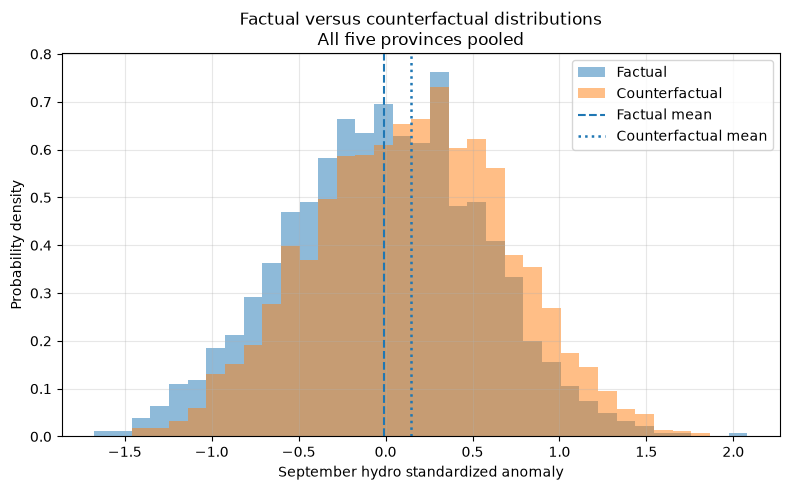

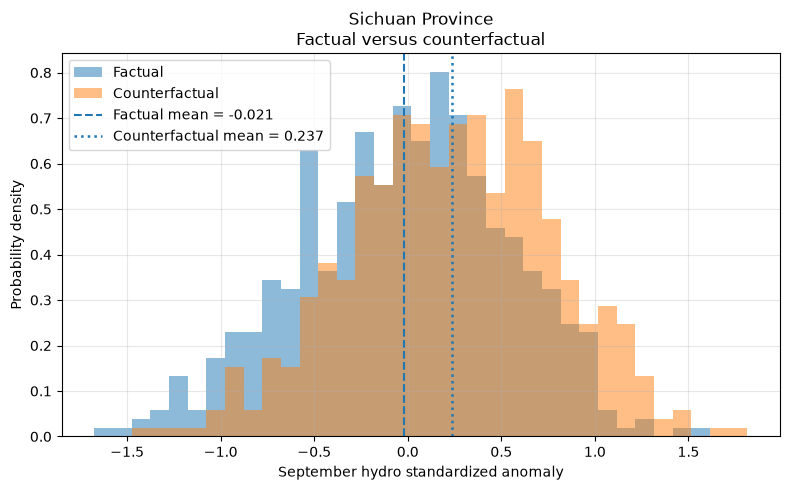

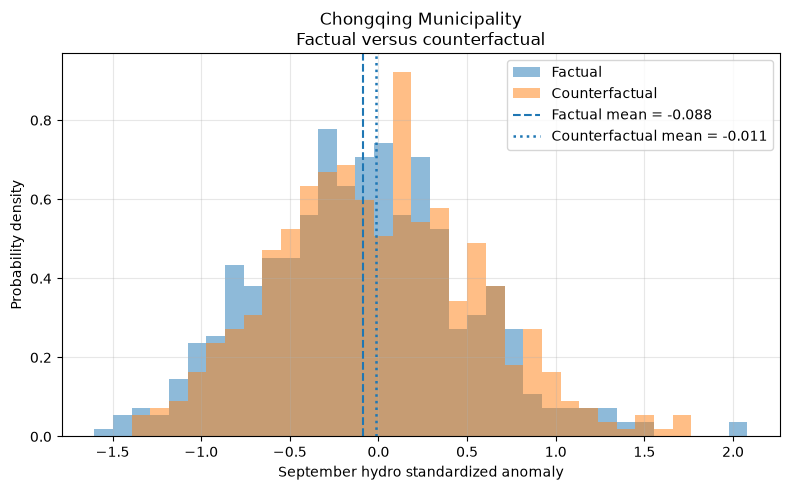

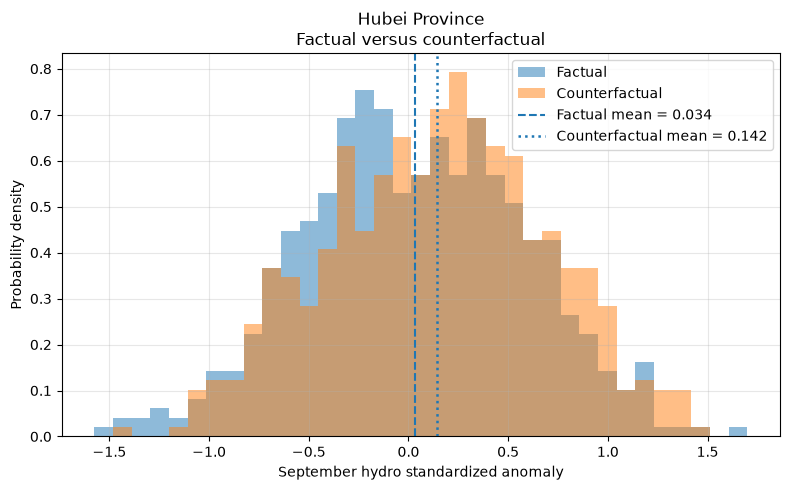

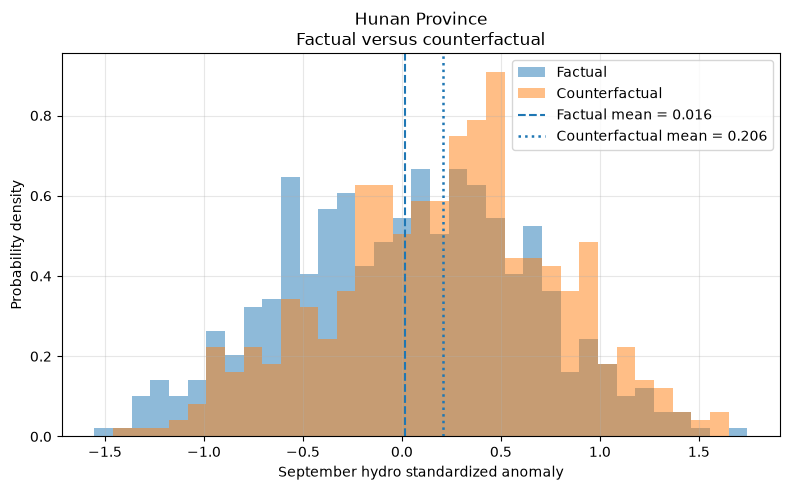

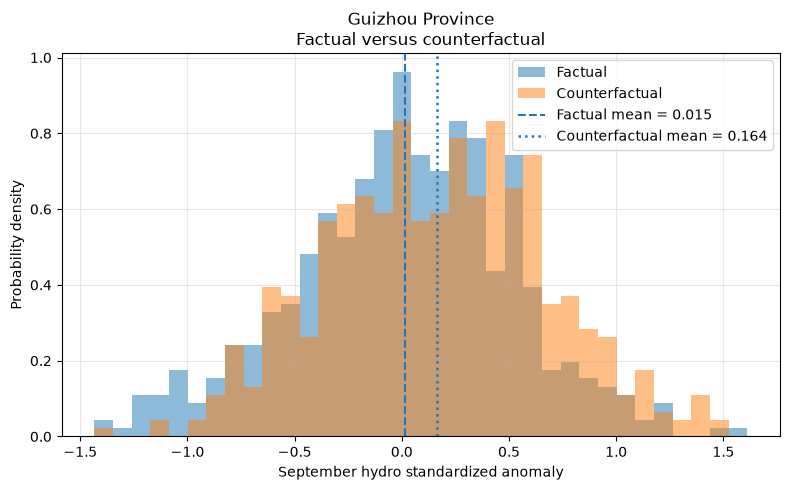

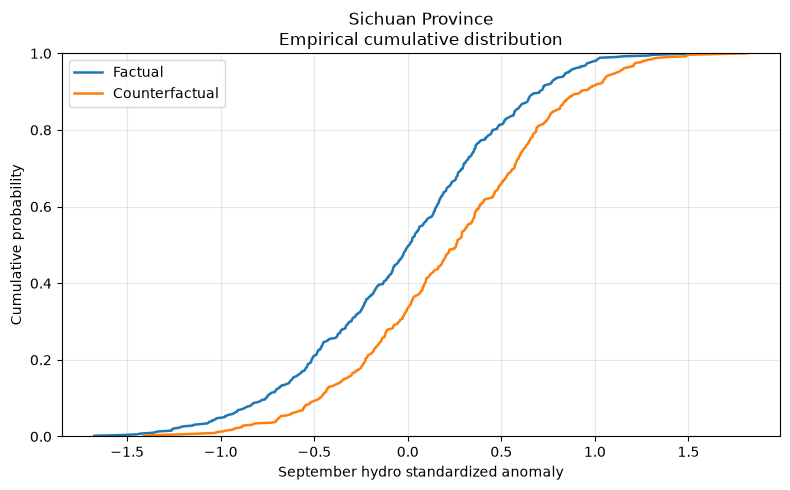

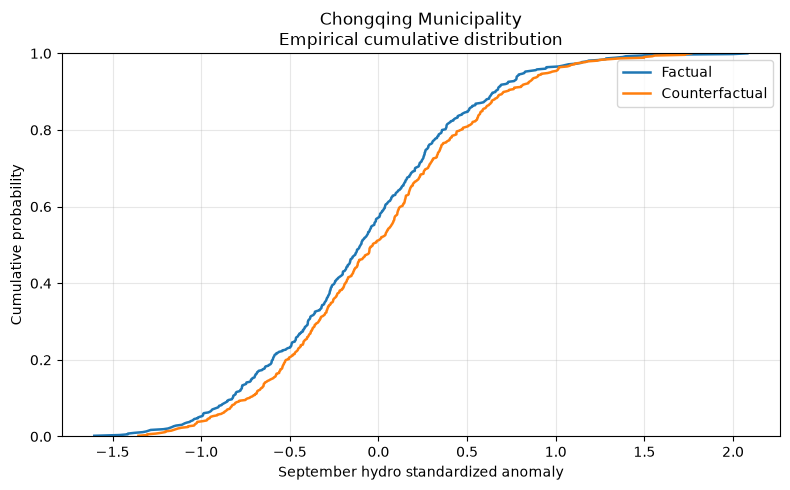

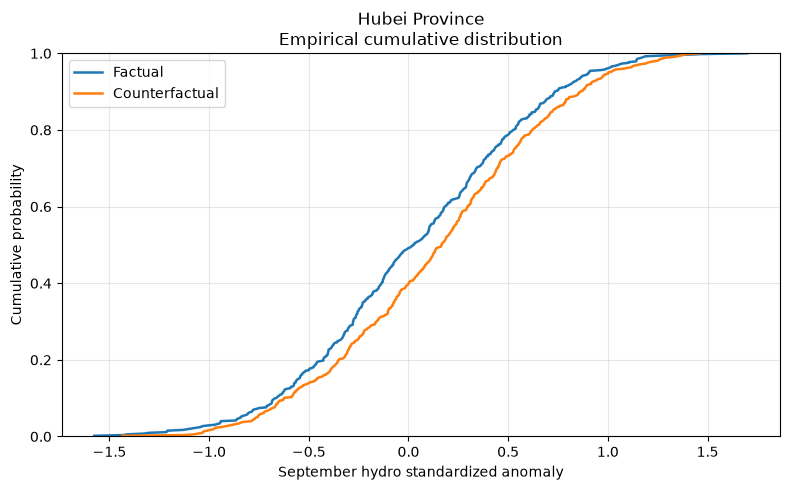

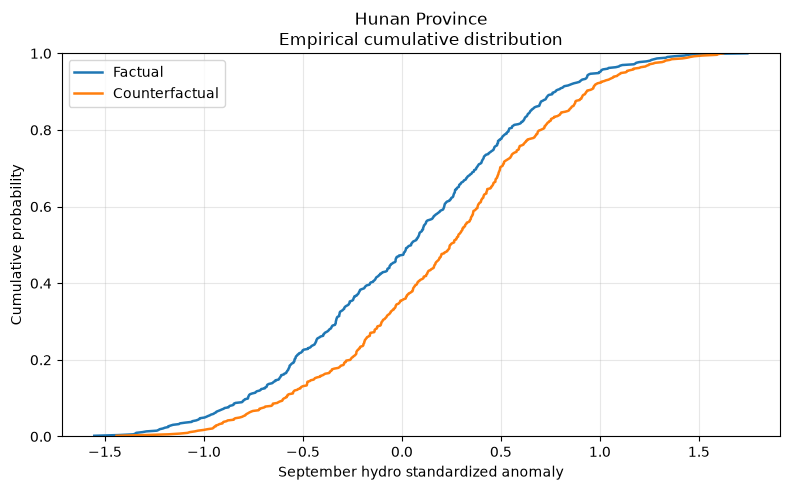

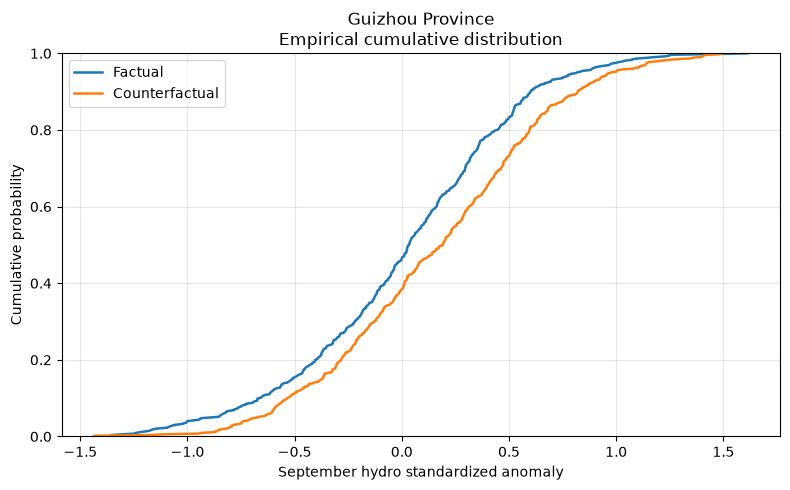

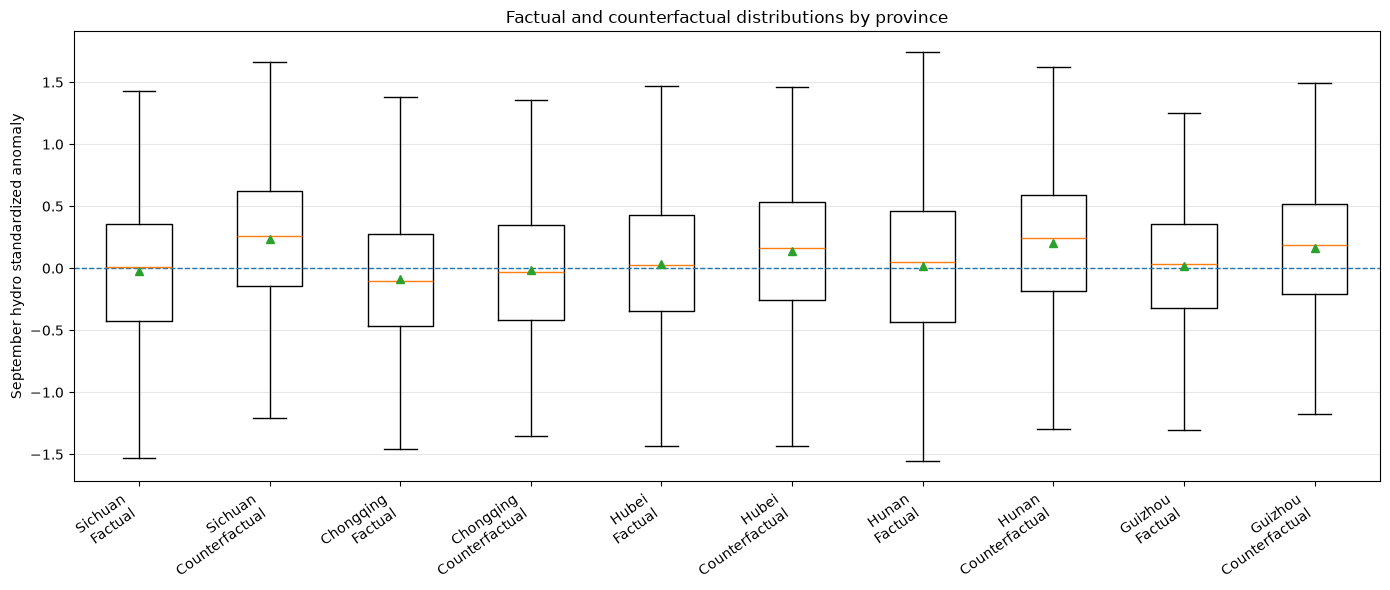


========== DISTRIBUTION SUMMARY ==========
              province       scenario  count      mean  standard_deviation   minimum       q05       q25    median      q75      q95  maximum
Chongqing Municipality Counterfactual    525 -0.011149            0.574493 -1.353853 -0.943427 -0.415501 -0.032255 0.349039 0.967025 1.763994
Chongqing Municipality        Factual    525 -0.087721            0.580134 -1.602978 -1.004917 -0.467585 -0.099638 0.274984 0.824213 2.080830
      Guizhou Province Counterfactual    525  0.163717            0.511986 -1.434482 -0.661469 -0.210370  0.191189 0.517790 0.977034 1.494700
      Guizhou Province        Factual    525  0.014837            0.508588 -1.359715 -0.852805 -0.318255  0.033758 0.353414 0.817354 1.611791
        Hubei Province Counterfactual    525  0.142116            0.546835 -1.436147 -0.754310 -0.257663  0.166553 0.531790 1.002570 1.463218
        Hubei Province        Factual    525  0.033760            0.551195 -1.575694 -0.838897 -0.343695

In [2]:
# Quick check

# ============================================================
# Quick distribution check:
# factual versus counterfactual September hydro anomalies
# ============================================================

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. User settings
# ============================================================

FACTUAL_CSV = (
    "/home/users/weijia_6/Yangtze_code/gen_result/"
    "step5_gamma_spi6/"
    "hydro_std_anom_sep_factual_525_by_province.csv"
)

COUNTERFACTUAL_CSV = (
    "/home/users/weijia_6/Yangtze_code/gen_result/"
    "step5_gamma_spi6/"
    "hydro_std_anom_sep_counterfactual_525_by_province.csv"
)

OUTPUT_DIRECTORY = (
    "/home/users/weijia_6/Yangtze_code/gen_result/"
    "step5_gamma_spi6/distribution_check"
)

os.makedirs(
    OUTPUT_DIRECTORY,
    exist_ok=True,
)

VALUE_COLUMN = "hydro_std_anom_sep"
PROVINCE_COLUMN = "province"
ENSEMBLE_COLUMN = "ensemble"

PROVINCES = [
    "Sichuan Province",
    "Chongqing Municipality",
    "Hubei Province",
    "Hunan Province",
    "Guizhou Province",
]

N_BINS = 35


# ============================================================
# 2. Load and validate CSV files
# ============================================================

def load_scenario_csv(path, scenario):
    if not os.path.isfile(path):
        raise FileNotFoundError(
            f"File not found: {path}"
        )

    data = pd.read_csv(
        path
    )

    required_columns = {
        ENSEMBLE_COLUMN,
        PROVINCE_COLUMN,
        VALUE_COLUMN,
    }

    missing_columns = required_columns.difference(
        data.columns
    )

    if missing_columns:
        raise ValueError(
            f"{scenario} CSV is missing columns: "
            f"{sorted(missing_columns)}"
        )

    data = data.copy()
    data["scenario"] = scenario

    data[VALUE_COLUMN] = pd.to_numeric(
        data[VALUE_COLUMN],
        errors="coerce",
    )

    return data


factual = load_scenario_csv(
    FACTUAL_CSV,
    "Factual",
)

counterfactual = load_scenario_csv(
    COUNTERFACTUAL_CSV,
    "Counterfactual",
)


# ============================================================
# 3. Structural checks
# ============================================================

print("\n========== STRUCTURAL CHECKS ==========")

for label, data in [
    ("Factual", factual),
    ("Counterfactual", counterfactual),
]:
    print(f"\n{label}:")
    print("  Rows:", len(data))
    print(
        "  Ensembles:",
        data[ENSEMBLE_COLUMN].nunique(),
    )
    print(
        "  Provinces:",
        data[PROVINCE_COLUMN].nunique(),
    )
    print(
        "  Missing anomaly values:",
        int(data[VALUE_COLUMN].isna().sum()),
    )

    counts = data.groupby(
        PROVINCE_COLUMN
    )[ENSEMBLE_COLUMN].nunique()

    print(
        "  Ensemble counts by province:"
    )
    print(counts)


# Keep finite values only for plotting.
factual_valid = factual[
    np.isfinite(
        factual[VALUE_COLUMN]
    )
].copy()

counterfactual_valid = counterfactual[
    np.isfinite(
        counterfactual[VALUE_COLUMN]
    )
].copy()


# ============================================================
# 4. Common plotting range
# ============================================================

all_values = np.concatenate(
    [
        factual_valid[VALUE_COLUMN].values,
        counterfactual_valid[VALUE_COLUMN].values,
    ]
)

if all_values.size == 0:
    raise RuntimeError(
        "No finite hydro-anomaly values were found."
    )

plot_min = float(
    np.nanmin(all_values)
)

plot_max = float(
    np.nanmax(all_values)
)

if plot_min == plot_max:
    plot_min -= 0.5
    plot_max += 0.5

bins = np.linspace(
    plot_min,
    plot_max,
    N_BINS + 1,
)


# ============================================================
# 5. All-province pooled histogram
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    factual_valid[VALUE_COLUMN],
    bins=bins,
    density=True,
    alpha=0.50,
    label="Factual",
)

plt.hist(
    counterfactual_valid[VALUE_COLUMN],
    bins=bins,
    density=True,
    alpha=0.50,
    label="Counterfactual",
)

plt.axvline(
    factual_valid[VALUE_COLUMN].mean(),
    linestyle="--",
    linewidth=1.5,
    label="Factual mean",
)

plt.axvline(
    counterfactual_valid[VALUE_COLUMN].mean(),
    linestyle=":",
    linewidth=1.8,
    label="Counterfactual mean",
)

plt.xlabel(
    "September hydro standardized anomaly"
)

plt.ylabel(
    "Probability density"
)

plt.title(
    "Factual versus counterfactual distributions\n"
    "All five provinces pooled"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

all_histogram_path = os.path.join(
    OUTPUT_DIRECTORY,
    "hydro_anomaly_distribution_all_provinces.png",
)

plt.savefig(
    all_histogram_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()


# ============================================================
# 6. Separate histogram for each province
# ============================================================

for province in PROVINCES:
    factual_values = factual_valid.loc[
        factual_valid[PROVINCE_COLUMN] == province,
        VALUE_COLUMN,
    ].values

    counterfactual_values = counterfactual_valid.loc[
        counterfactual_valid[PROVINCE_COLUMN] == province,
        VALUE_COLUMN,
    ].values

    if (
        factual_values.size == 0
        or counterfactual_values.size == 0
    ):
        print(
            f"[WARNING] Skipping {province}: "
            "one scenario has no valid values."
        )
        continue

    local_min = min(
        float(factual_values.min()),
        float(counterfactual_values.min()),
    )

    local_max = max(
        float(factual_values.max()),
        float(counterfactual_values.max()),
    )

    if local_min == local_max:
        local_min -= 0.5
        local_max += 0.5

    local_bins = np.linspace(
        local_min,
        local_max,
        N_BINS + 1,
    )

    plt.figure(
        figsize=(8, 5)
    )

    plt.hist(
        factual_values,
        bins=local_bins,
        density=True,
        alpha=0.50,
        label="Factual",
    )

    plt.hist(
        counterfactual_values,
        bins=local_bins,
        density=True,
        alpha=0.50,
        label="Counterfactual",
    )

    plt.axvline(
        np.mean(factual_values),
        linestyle="--",
        linewidth=1.5,
        label=(
            f"Factual mean = "
            f"{np.mean(factual_values):.3f}"
        ),
    )

    plt.axvline(
        np.mean(counterfactual_values),
        linestyle=":",
        linewidth=1.8,
        label=(
            f"Counterfactual mean = "
            f"{np.mean(counterfactual_values):.3f}"
        ),
    )

    plt.xlabel(
        "September hydro standardized anomaly"
    )

    plt.ylabel(
        "Probability density"
    )

    plt.title(
        f"{province}\n"
        "Factual versus counterfactual"
    )

    plt.grid(
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    safe_name = (
        province.lower()
        .replace(" ", "_")
        .replace("/", "_")
    )

    output_path = os.path.join(
        OUTPUT_DIRECTORY,
        f"{safe_name}_distribution.png",
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close()


# ============================================================
# 7. Empirical CDF by province
# ============================================================

def empirical_cdf(values):
    sorted_values = np.sort(
        np.asarray(values)
    )

    probabilities = (
        np.arange(
            1,
            sorted_values.size + 1,
        )
        / sorted_values.size
    )

    return sorted_values, probabilities


for province in PROVINCES:
    factual_values = factual_valid.loc[
        factual_valid[PROVINCE_COLUMN] == province,
        VALUE_COLUMN,
    ].values

    counterfactual_values = counterfactual_valid.loc[
        counterfactual_valid[PROVINCE_COLUMN] == province,
        VALUE_COLUMN,
    ].values

    if (
        factual_values.size == 0
        or counterfactual_values.size == 0
    ):
        continue

    factual_x, factual_cdf = empirical_cdf(
        factual_values
    )

    counterfactual_x, counterfactual_cdf = empirical_cdf(
        counterfactual_values
    )

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        factual_x,
        factual_cdf,
        linewidth=1.8,
        label="Factual",
    )

    plt.plot(
        counterfactual_x,
        counterfactual_cdf,
        linewidth=1.8,
        label="Counterfactual",
    )

    plt.xlabel(
        "September hydro standardized anomaly"
    )

    plt.ylabel(
        "Cumulative probability"
    )

    plt.title(
        f"{province}\n"
        "Empirical cumulative distribution"
    )

    plt.ylim(
        0,
        1,
    )

    plt.grid(
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    safe_name = (
        province.lower()
        .replace(" ", "_")
        .replace("/", "_")
    )

    output_path = os.path.join(
        OUTPUT_DIRECTORY,
        f"{safe_name}_cdf.png",
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close()


# ============================================================
# 8. Combined boxplot
# ============================================================

combined = pd.concat(
    [
        factual_valid,
        counterfactual_valid,
    ],
    ignore_index=True,
)

boxplot_data = []
boxplot_labels = []

for province in PROVINCES:
    for scenario in [
        "Factual",
        "Counterfactual",
    ]:
        values = combined.loc[
            (
                combined[PROVINCE_COLUMN] == province
            )
            & (
                combined["scenario"] == scenario
            ),
            VALUE_COLUMN,
        ].values

        boxplot_data.append(
            values
        )

        short_province = (
            province
            .replace(" Province", "")
            .replace(" Municipality", "")
        )

        boxplot_labels.append(
            f"{short_province}\n{scenario}"
        )

plt.figure(
    figsize=(14, 6)
)

plt.boxplot(
    boxplot_data,
    tick_labels=boxplot_labels,
    showfliers=False,
    showmeans=True,
)

plt.axhline(
    0.0,
    linestyle="--",
    linewidth=1.0,
)

plt.ylabel(
    "September hydro standardized anomaly"
)

plt.title(
    "Factual and counterfactual distributions by province"
)

plt.xticks(
    rotation=35,
    ha="right",
)

plt.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()

boxplot_path = os.path.join(
    OUTPUT_DIRECTORY,
    "hydro_anomaly_boxplot_by_province.png",
)

plt.savefig(
    boxplot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()


# ============================================================
# 9. Distribution summary table
# ============================================================

summary = (
    combined
    .groupby(
        [
            PROVINCE_COLUMN,
            "scenario",
        ]
    )[VALUE_COLUMN]
    .agg(
        count="count",
        mean="mean",
        standard_deviation="std",
        minimum="min",
        q05=lambda x: x.quantile(0.05),
        q25=lambda x: x.quantile(0.25),
        median="median",
        q75=lambda x: x.quantile(0.75),
        q95=lambda x: x.quantile(0.95),
        maximum="max",
    )
    .reset_index()
)

summary_path = os.path.join(
    OUTPUT_DIRECTORY,
    "hydro_anomaly_distribution_summary.csv",
)

summary.to_csv(
    summary_path,
    index=False,
)

print(
    "\n========== DISTRIBUTION SUMMARY =========="
)

print(
    summary.to_string(
        index=False
    )
)

print("\nSaved outputs:")
print(all_histogram_path)
print(boxplot_path)
print(summary_path)
print(OUTPUT_DIRECTORY)